<a href="https://colab.research.google.com/github/alxmzr/Colab/blob/main/GANN_15_EVERYDAY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matplotlib numpy

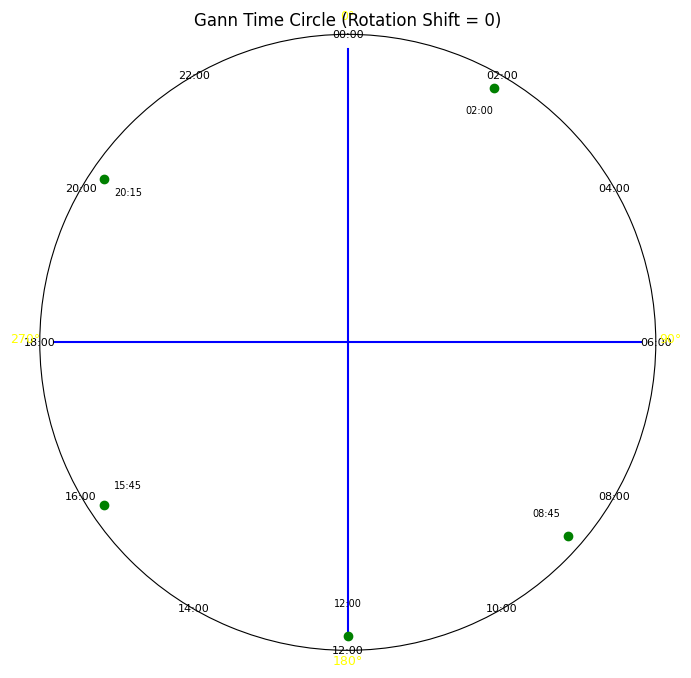

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# --- 1. Настройки
time_step_minutes = 15  # интервал между ячейками
hours_per_day = 24
cells = hours_per_day * 60 // time_step_minutes  # 96 ячеек

# --- 2. Генерация времени
def generate_time_grid():
    times = []
    base_time = datetime.strptime("00:00", "%H:%M")
    for i in range(cells):
        times.append((base_time + timedelta(minutes=i * time_step_minutes)).strftime("%H:%M"))
    return times

# --- 3. Перевод времени в индекс
def time_to_index(time_str):
    t = datetime.strptime(time_str, "%H:%M")
    return (t.hour * 60 + t.minute) // time_step_minutes

# --- 4. Построение круга Ганна
def plot_gann_circle(zigzag_times, rotation_shift=0):
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2)

    # Временная сетка
    times = generate_time_grid()
    theta = np.linspace(0, 2 * np.pi, cells, endpoint=False)

    # Угол на точку
    time_angles = {times[i]: theta[(i + rotation_shift) % cells] for i in range(cells)}

    # Метки времени
    for i, t in enumerate(times):
        if i % 8 == 0:  # каждый 2 часа
            ax.text(theta[(i + rotation_shift) % cells], 1.05, t, ha='center', va='center', fontsize=8)

    # Линии 0°, 90°, 180°, 270°
    for deg in [0, 90, 180, 270]:
        angle = np.deg2rad((deg + rotation_shift * 360 / cells) % 360)
        ax.plot([angle, angle], [0, 1], color='blue', lw=1.5)
        ax.text(angle, 1.1, f'{deg}°', color='yellow', fontsize=9, ha='center')

    # Отметка разворотов
    for time in zigzag_times:
        if time in time_angles:
            angle = time_angles[time]
            ax.plot(angle, 1, 'go', label=time)
            ax.text(angle, 0.9, time, fontsize=7, ha='center')

    ax.set_rticks([])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Gann Time Circle (Rotation Shift = {rotation_shift})", fontsize=12)
    plt.show()

# --- 5. Основная логика
def find_best_rotation(zigzag_times):
    target_indices = [time_to_index(t) for t in zigzag_times]
    for shift in range(cells):
        hits = 0
        for deg in [0, 24, 48, 72]:  # каждые 90 градусов → каждые 24 индекса
            target = (shift + deg) % cells
            if target in target_indices:
                hits += 1
        if hits >= 2:  # если хотя бы 2 совпадения
            return shift
    return 0  # fallback

# --- 6. Пример использования
zigzag_times = ['02:00', '08:45', '12:00', '15:45', '20:15']  # пример прошлых разворотов
rotation = find_best_rotation(zigzag_times)
plot_gann_circle(zigzag_times, rotation)


Предсказанные развороты на следующий день:
⏰ 00:00
⏰ 06:00
⏰ 12:00
⏰ 18:00


/usr/local/lib/python3.11/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


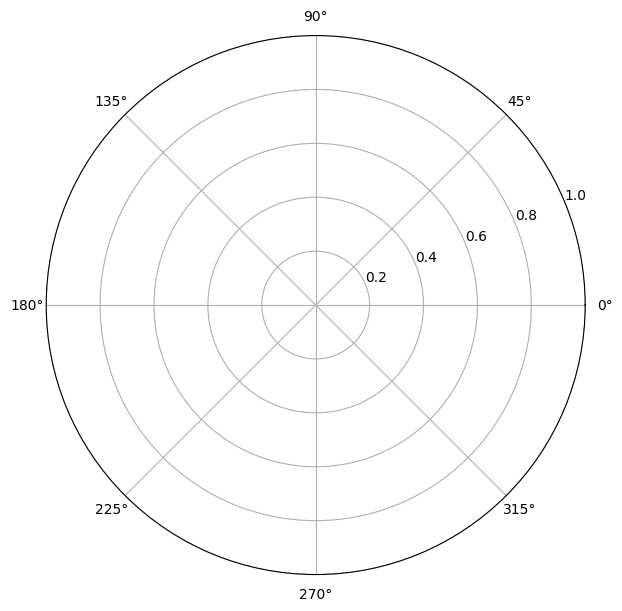

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import matplotlib.animation as animation

# --- Настройки
time_step_minutes = 15
cells = 24 * 60 // time_step_minutes  # 96

# --- Генерация времён
def generate_time_grid():
    base_time = datetime.strptime("00:00", "%H:%M")
    return [(base_time + timedelta(minutes=i * time_step_minutes)).strftime("%H:%M") for i in range(cells)]

# --- Перевод времени в индекс
def time_to_index(time_str):
    t = datetime.strptime(time_str, "%H:%M")
    return (t.hour * 60 + t.minute) // time_step_minutes

# --- Индекс в время
def index_to_time(index):
    index = index % cells
    t = datetime.strptime("00:00", "%H:%M") + timedelta(minutes=index * time_step_minutes)
    return t.strftime("%H:%M")

# --- Прогноз по углам
def predict_times(rotation_shift):
    angles = [0, 90, 180, 270]
    angle_steps = [int(a * cells / 360) for a in angles]
    predicted_indices = [(rotation_shift + step) % cells for step in angle_steps]
    return [index_to_time(i) for i in predicted_indices]

# --- Рисуем круг Ганна
def plot_gann_circle(ax, zigzag_times, rotation_shift=0):
    ax.clear()
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2)

    times = generate_time_grid()
    theta = np.linspace(0, 2 * np.pi, cells, endpoint=False)
    time_angles = {times[i]: theta[(i + rotation_shift) % cells] for i in range(cells)}

    # Разметка
    for i, t in enumerate(times):
        if i % 8 == 0:
            ax.text(theta[(i + rotation_shift) % cells], 1.05, t, ha='center', va='center', fontsize=7)

    # Углы 0° / 90° / 180° / 270°
    for deg in [0, 90, 180, 270]:
        angle = np.deg2rad((deg + rotation_shift * 360 / cells) % 360)
        ax.plot([angle, angle], [0, 1], color='blue', lw=1.5)
        ax.text(angle, 1.12, f'{deg}°', color='orange', fontsize=8, ha='center')

    # Отметки разворотов
    for t in zigzag_times:
        if t in time_angles:
            angle = time_angles[t]
            ax.plot(angle, 1, 'go')
            ax.text(angle, 0.9, t, fontsize=7, ha='center')

    ax.set_rticks([])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Gann Circle | Rotation: {rotation_shift}", fontsize=10)

# --- Поиск лучшего поворота
def find_best_rotation(zigzag_times):
    target_indices = [time_to_index(t) for t in zigzag_times]
    for shift in range(cells):
        hits = 0
        for deg in [0, 24, 48, 72]:
            target = (shift + deg) % cells
            if target in target_indices:
                hits += 1
        if hits >= 2:
            return shift
    return 0

# --- Анимация вращения
def animate_rotation(zigzag_times):
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})

    def update(frame):
        plot_gann_circle(ax, zigzag_times, rotation_shift=frame)
        return ax,

    ani = animation.FuncAnimation(fig, update, frames=range(0, cells), interval=100)
    plt.show()
    # Чтобы сохранить: ani.save('gann_rotation.gif', writer='pillow')

# --- Пример использования
if __name__ == "__main__":
    zigzag_times = ['02:00', '08:45', '12:00', '15:45', '20:15']  # можно заменить на реальные данные
    best_rotation = find_best_rotation(zigzag_times)

    # Печать предсказаний
    predicted = predict_times(best_rotation)
    print("Предсказанные развороты на следующий день:")
    for t in predicted:
        print(f"⏰ {t}")

    # Визуализация + анимация
    animate_rotation(zigzag_times)


📌 Прогноз по главной диагонали:
[np.str_('00:00'), np.str_('04:15'), np.str_('08:30'), np.str_('12:45'), np.str_('17:00'), np.str_('21:15'), np.str_('01:30'), np.str_('05:45'), np.str_('10:00'), np.str_('14:15'), np.str_('18:30'), np.str_('22:45'), np.str_('03:00'), np.str_('07:15'), np.str_('11:30'), np.str_('15:45')]
📌 Прогноз по перекрёстной диагонали:
[np.str_('03:45'), np.str_('07:30'), np.str_('11:15'), np.str_('15:00'), np.str_('18:45'), np.str_('22:30'), np.str_('02:15'), np.str_('06:00'), np.str_('09:45'), np.str_('13:30'), np.str_('17:15'), np.str_('21:00'), np.str_('00:45'), np.str_('04:30'), np.str_('08:15'), np.str_('12:00')]


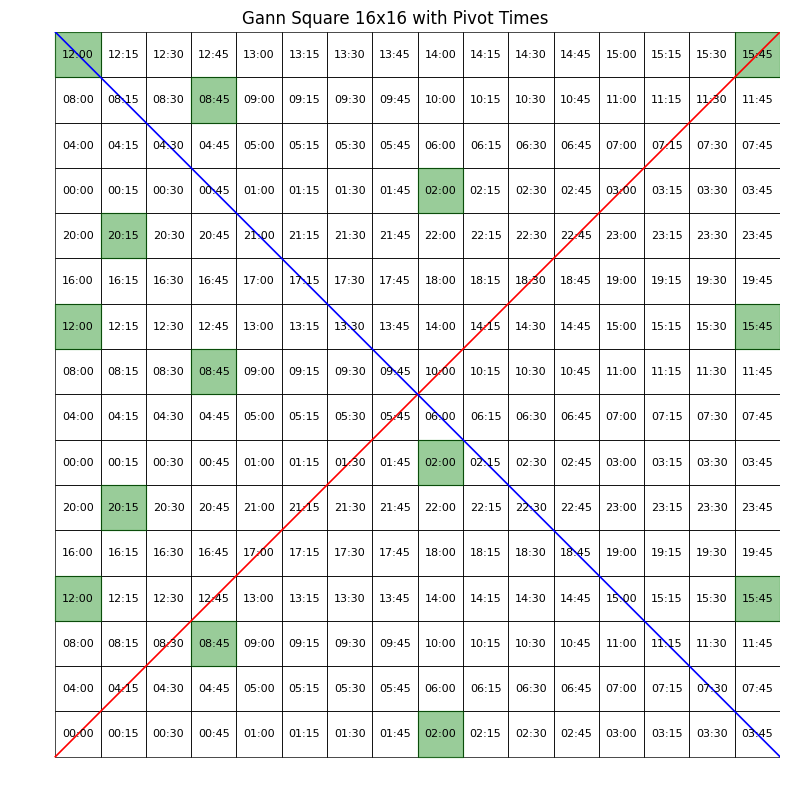

In [ ]:
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Параметры
pivot_times = ['02:00', '08:45', '12:00', '15:45', '20:15']
interval = 15  # минут
matrix_size = 16
slots_needed = matrix_size ** 2  # 256

# Генерация 256 тайм-слотов
time_slots = []
start_time = datetime(2000, 1, 1)
for i in range(slots_needed):
    t = start_time + timedelta(minutes=interval * i)
    time_slots.append(t.strftime("%H:%M"))

# Преобразуем pivot_times в индексы
pivot_indices = [i for i, t in enumerate(time_slots) if t in pivot_times]

# Создаём сетку
grid = np.array(time_slots).reshape(matrix_size, matrix_size)

# Визуализация
def draw_gann_grid(angle_deg=45):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_xlim(-1, matrix_size)
    ax.set_ylim(-1, matrix_size)
    ax.set_aspect('equal')

    for y in range(matrix_size):
        for x in range(matrix_size):
            ax.add_patch(Rectangle((x, y), 1, 1, fill=False, edgecolor='black', linewidth=0.5))
            ax.text(x + 0.5, y + 0.5, grid[y][x], ha='center', va='center', fontsize=8)

    # Диагонали
    ax.plot([0, matrix_size], [0, matrix_size], color='red', linewidth=1.2)
    ax.plot([0, matrix_size], [matrix_size, 0], color='blue', linewidth=1.2)

    # Зеленые квадратики — опорные точки
    for idx in pivot_indices:
        y, x = divmod(idx, matrix_size)
        ax.add_patch(Rectangle((x, y), 1, 1, color='green', alpha=0.4))

    plt.title(f'Gann Square 16x16 with Pivot Times')
    plt.grid(False)
    plt.axis('off')
    plt.show()

# Получаем времена с диагоналей
main_diag = [grid[i][i] for i in range(matrix_size)]
cross_diag = [grid[i][-(i+1)] for i in range(matrix_size)]

print("📌 Прогноз по главной диагонали:")
print(main_diag)

print("📌 Прогноз по перекрёстной диагонали:")
print(cross_diag)

# Визуализация
draw_gann_grid()


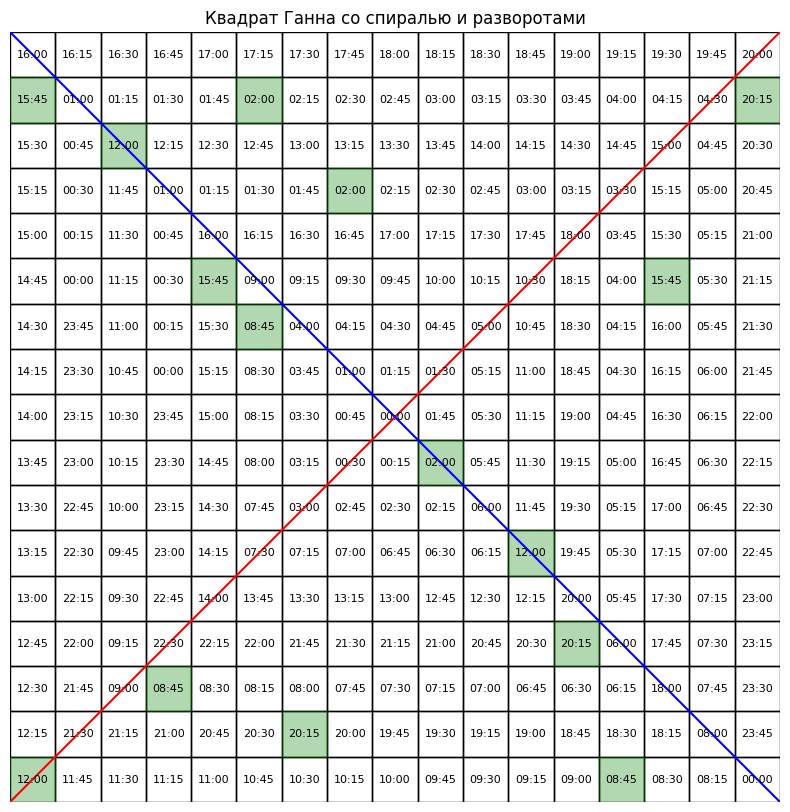

📌 Прогноз разворотов по главной диагонали:
['16:00', '01:00', '12:00', '01:00', '16:00', '09:00', '04:00', '01:00', '00:00', '02:00', '06:00', '12:00', '20:00', '06:00', '18:00', '08:00', '00:00']
📌 Прогноз разворотов по перекрёстной диагонали:
['20:00', '04:30', '15:00', '03:30', '18:00', '10:30', '05:00', '01:30', '00:00', '00:30', '03:00', '07:30', '14:00', '22:30', '09:00', '21:30', '12:00']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Параметры
interval_min = 15
matrix_size = 17
pivot_times = ['02:00', '08:45', '12:00', '15:45', '20:15']

# Генерация времён: 256 интервалов по 15 минут
total_cells = matrix_size ** 2
start_time = datetime(2000, 1, 1)
time_list = [(start_time + timedelta(minutes=interval_min * i)).strftime("%H:%M") for i in range(total_cells)]

# Пустой квадрат
spiral = np.empty((matrix_size, matrix_size), dtype=object)

# Старт из центра
x = y = matrix_size // 2
if matrix_size % 2 == 0:
    x -= 1
    y -= 1

# Движения: вправо, вверх, влево, вниз
dx, dy = [0, -1, 0, 1], [1, 0, -1, 0]
step = 1
count = 0
dir_idx = 0

while count < total_cells:
    for _ in range(2):  # два раза на каждом "радиусе"
        for _ in range(step):
            if 0 <= x < matrix_size and 0 <= y < matrix_size:
                if count >= total_cells:
                    break
                spiral[y, x] = time_list[count]
                count += 1
            x += dx[dir_idx]
            y += dy[dir_idx]
        dir_idx = (dir_idx + 1) % 4
    step += 1

# Pivot-координаты
pivot_coords = [(i, j) for i in range(matrix_size) for j in range(matrix_size) if spiral[i, j] in pivot_times]

# Визуализация
fig, ax = plt.subplots(figsize=(10, 10))
for i in range(matrix_size):
    for j in range(matrix_size):
        val = spiral[i, j]
        ax.add_patch(plt.Rectangle((j, matrix_size - i - 1), 1, 1, fill=False, edgecolor='black'))
        ax.text(j + 0.5, matrix_size - i - 0.5, val, ha='center', va='center', fontsize=8)

# Диагонали
ax.plot([0, matrix_size], [0, matrix_size], color='red', lw=1.5)
ax.plot([0, matrix_size], [matrix_size, 0], color='blue', lw=1.5)

# Pivot-точки
for i, j in pivot_coords:
    ax.add_patch(plt.Rectangle((j, matrix_size - i - 1), 1, 1, color='green', alpha=0.3))

ax.set_xlim(0, matrix_size)
ax.set_ylim(0, matrix_size)
ax.set_aspect('equal')
ax.axis('off')
plt.title('Квадрат Ганна со спиралью и разворотами')
plt.show()

# Получение предсказанных разворотов по диагоналям
main_diag = [spiral[i, i] for i in range(matrix_size)]
cross_diag = [spiral[i, matrix_size - i - 1] for i in range(matrix_size)]

print("📌 Прогноз разворотов по главной диагонали:")
print(main_diag)

print("📌 Прогноз разворотов по перекрёстной диагонали:")
print(cross_diag)


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


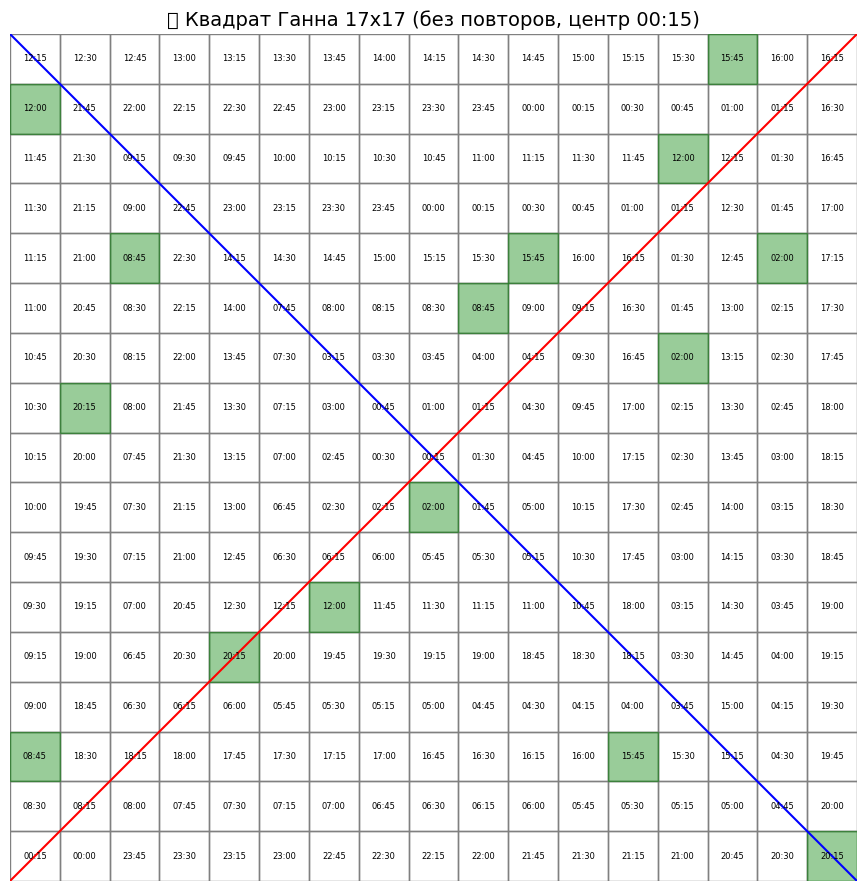

📌 Прогноз разворотов (главная диагональ):
['12:15', '21:45', '09:15', '22:45', '14:15', '07:45', '03:15', '00:45', '00:15', '01:45', '05:15', '10:45', '18:15', '03:45', '15:15', '04:45', '20:15']

📌 Прогноз разворотов (перекрёстная диагональ):
['16:15', '01:15', '12:15', '01:15', '16:15', '09:15', '04:15', '01:15', '00:15', '02:15', '06:15', '12:15', '20:15', '06:15', '18:15', '08:15', '00:15']


In [ ]:
#BEST
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Параметры
matrix_size = 17
total_cells = matrix_size ** 2
interval_min = 15
start_time = datetime(2000, 1, 1, 0, 15)

# Список времен: без повторений
time_list = [(start_time + timedelta(minutes=interval_min * i)).strftime("%H:%M") for i in range(total_cells)]

# Повороты против часовой стрелки
dx = [-1, 0, 1, 0]
dy = [0, -1, 0, 1]

# Создаем пустую матрицу и ставим курсор в центр
spiral = np.empty((matrix_size, matrix_size), dtype=object)
x = y = matrix_size // 2
spiral[y][x] = time_list[0]
count = 1
step = 1
dir_idx = 0

# Заполняем спираль от центра
while count < total_cells:
    for _ in range(2):  # два направления на одном шаге
        for _ in range(step):
            x += dx[dir_idx]
            y += dy[dir_idx]
            if 0 <= x < matrix_size and 0 <= y < matrix_size:
                if count >= total_cells:
                    break
                spiral[y][x] = time_list[count]
                count += 1
        dir_idx = (dir_idx + 1) % 4
    step += 1

# Точки разворота
pivot_times = ['02:00', '08:45', '12:00', '15:45', '20:15']
pivot_coords = [(i, j) for i in range(matrix_size) for j in range(matrix_size) if spiral[i][j] in pivot_times]

# Визуализация
fig, ax = plt.subplots(figsize=(11, 11))
for i in range(matrix_size):
    for j in range(matrix_size):
        ax.add_patch(plt.Rectangle((j, matrix_size - i - 1), 1, 1, fill=False, edgecolor='gray'))
        ax.text(j + 0.5, matrix_size - i - 0.5, spiral[i][j], ha='center', va='center', fontsize=6)

# Диагонали как прогноз
ax.plot([0, matrix_size], [0, matrix_size], color='red', lw=1.5)
ax.plot([0, matrix_size], [matrix_size, 0], color='blue', lw=1.5)

# Отметки разворотов прошлого дня
for i, j in pivot_coords:
    ax.add_patch(plt.Rectangle((j, matrix_size - i - 1), 1, 1, color='green', alpha=0.4))

ax.set_xlim(0, matrix_size)
ax.set_ylim(0, matrix_size)
ax.set_aspect('equal')
ax.axis('off')
plt.title("🌀 Квадрат Ганна 17x17 (без повторов, центр 00:15)", fontsize=14)
plt.show()

# Прогноз на следующий день по диагоналям
main_diag = [spiral[i][i] for i in range(matrix_size)]
cross_diag = [spiral[i][matrix_size - i - 1] for i in range(matrix_size)]

print("📌 Прогноз разворотов (главная диагональ):")
print(main_diag)
print("\n📌 Прогноз разворотов (перекрёстная диагональ):")
print(cross_diag)


🧭 Углы квадрата Ганна:
Левый верхний: 12:15
Правый верхний: 16:15
Правый нижний: 20:15
Левый нижний: 00:15


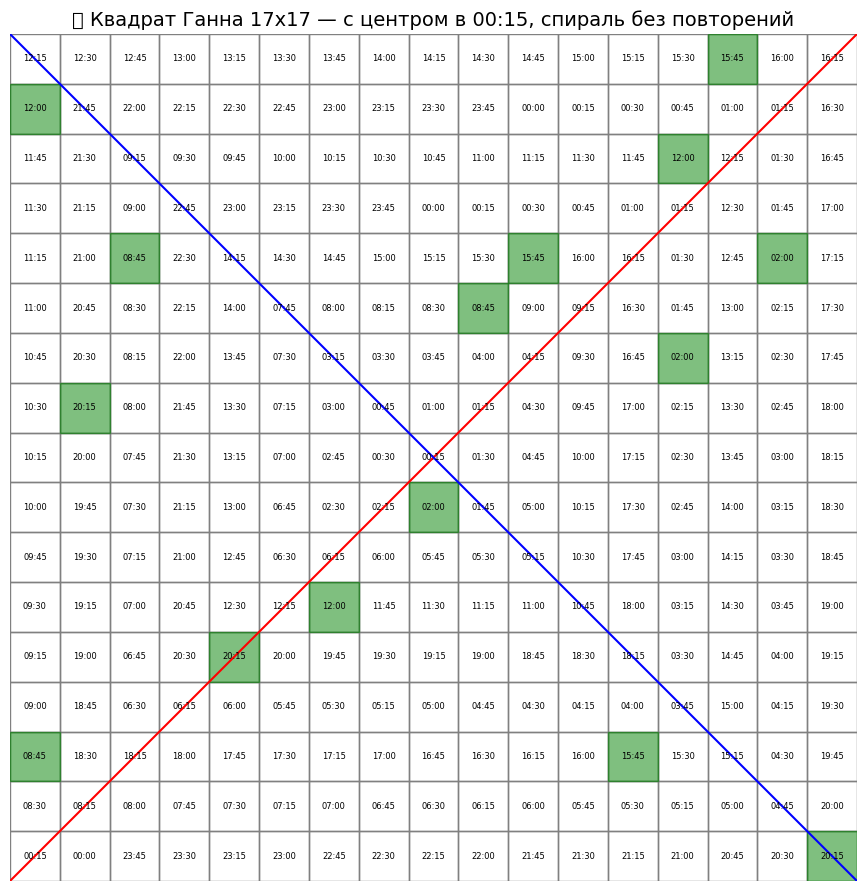


📌 Прогноз разворотов на следующий день (главная диагональ):
['12:15', '21:45', '09:15', '22:45', '14:15', '07:45', '03:15', '00:45', '00:15', '01:45', '05:15', '10:45', '18:15', '03:45', '15:15', '04:45', '20:15']

📌 Прогноз разворотов на следующий день (перекрёстная диагональ):
['16:15', '01:15', '12:15', '01:15', '16:15', '09:15', '04:15', '01:15', '00:15', '02:15', '06:15', '12:15', '20:15', '06:15', '18:15', '08:15', '00:15']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Параметры
matrix_size = 17
total_cells = matrix_size ** 2
interval_min = 15
start_time = datetime(2000, 1, 1, 0, 15)

# Временные метки: 289 шагов по 15 минут от 00:15
time_list = [(start_time + timedelta(minutes=interval_min * i)).strftime("%H:%M") for i in range(total_cells)]

# Спираль против часовой стрелки
dx = [-1, 0, 1, 0]
dy = [0, -1, 0, 1]

spiral = np.empty((matrix_size, matrix_size), dtype=object)
x = y = matrix_size // 2  # Центр
spiral[y][x] = time_list[0]
count = 1
step = 1
dir_idx = 0

# Построение спирали
while count < total_cells:
    for _ in range(2):  # два направления на одном шаге
        for _ in range(step):
            x += dx[dir_idx]
            y += dy[dir_idx]
            if 0 <= x < matrix_size and 0 <= y < matrix_size:
                if count >= total_cells:
                    break
                spiral[y][x] = time_list[count]
                count += 1
        dir_idx = (dir_idx + 1) % 4
    step += 1

# Отмеченные развороты (прошлый день)
pivot_times = ['02:00', '08:45', '12:00', '15:45', '20:15']
pivot_coords = [(i, j) for i in range(matrix_size) for j in range(matrix_size) if spiral[i][j] in pivot_times]

# Проверка углов
corner_labels = {
    "Левый верхний": spiral[0][0],
    "Правый верхний": spiral[0][-1],
    "Правый нижний": spiral[-1][-1],
    "Левый нижний": spiral[-1][0]
}

print("🧭 Углы квадрата Ганна:")
for corner, time in corner_labels.items():
    print(f"{corner}: {time}")

# Визуализация
fig, ax = plt.subplots(figsize=(11, 11))
for i in range(matrix_size):
    for j in range(matrix_size):
        ax.add_patch(plt.Rectangle((j, matrix_size - i - 1), 1, 1, fill=False, edgecolor='gray'))
        ax.text(j + 0.5, matrix_size - i - 0.5, spiral[i][j], ha='center', va='center', fontsize=6)

# Диагонали как прогноз
ax.plot([0, matrix_size], [0, matrix_size], color='red', lw=1.5)
ax.plot([0, matrix_size], [matrix_size, 0], color='blue', lw=1.5)

# Зелёные квадраты — развороты
for i, j in pivot_coords:
    ax.add_patch(plt.Rectangle((j, matrix_size - i - 1), 1, 1, color='green', alpha=0.5))

ax.set_xlim(0, matrix_size)
ax.set_ylim(0, matrix_size)
ax.set_aspect('equal')
ax.axis('off')
plt.title("🌀 Квадрат Ганна 17x17 — с центром в 00:15, спираль без повторений", fontsize=14)
plt.show()

# Прогнозы на следующий день — точки пересечения диагоналей
main_diag = [spiral[i][i] for i in range(matrix_size)]
cross_diag = [spiral[i][matrix_size - i - 1] for i in range(matrix_size)]

print("\n📌 Прогноз разворотов на следующий день (главная диагональ):")
print(main_diag)
print("\n📌 Прогноз разворотов на следующий день (перекрёстная диагональ):")
print(cross_diag)


🧭 Углы квадрата Ганна:
Левый верхний: 12:15
Правый верхний: 16:15
Правый нижний: 20:15
Левый нижний: 00:15


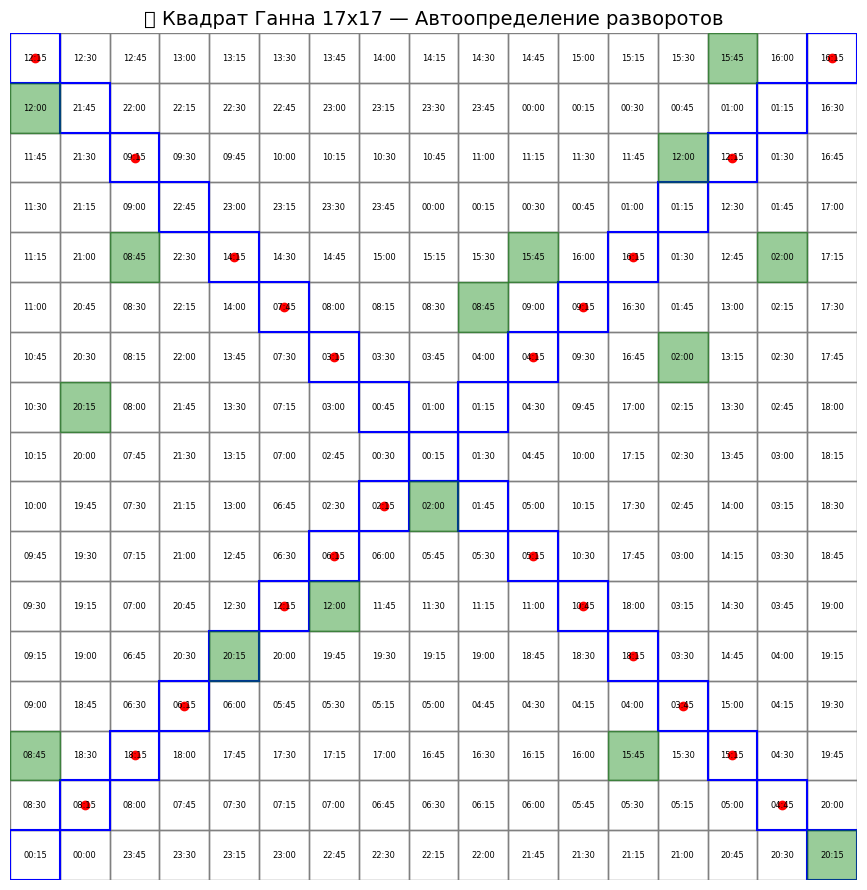


📌 Прогноз разворотов на следующий день (по диагональным углам):
Разворот 1: 12:15
Разворот 2: 16:15
Разворот 3: 20:15
Разворот 4: 00:15


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Константы
matrix_size = 17
total_cells = matrix_size ** 2
interval_min = 15
start_time = datetime(2000, 1, 1, 0, 15)

# Генерация временного списка
time_list = [(start_time + timedelta(minutes=interval_min * i)).strftime("%H:%M") for i in range(total_cells)]

# Построение спирали против часовой стрелки
dx = [-1, 0, 1, 0]
dy = [0, -1, 0, 1]

spiral = np.empty((matrix_size, matrix_size), dtype=object)
x = y = matrix_size // 2
spiral[y][x] = time_list[0]
count = 1
step = 1
dir_idx = 0

while count < total_cells:
    for _ in range(2):  # два направления одного уровня
        for _ in range(step):
            x += dx[dir_idx]
            y += dy[dir_idx]
            if 0 <= x < matrix_size and 0 <= y < matrix_size:
                if count >= total_cells:
                    break
                spiral[y][x] = time_list[count]
                count += 1
        dir_idx = (dir_idx + 1) % 4
    step += 1

# Углы для проверки
corner_labels = {
    "Левый верхний": spiral[0][0],
    "Правый верхний": spiral[0][-1],
    "Правый нижний": spiral[-1][-1],
    "Левый нижний": spiral[-1][0]
}

print("🧭 Углы квадрата Ганна:")
for corner, time in corner_labels.items():
    print(f"{corner}: {time}")

# Pivot точки (времена)
pivot_times = ['02:00', '08:45', '12:00', '15:45', '20:15']
pivot_coords = [(i, j) for i in range(matrix_size) for j in range(matrix_size) if spiral[i][j] in pivot_times]
pivot_minutes = [int(t.split(':')[0]) * 60 + int(t.split(':')[1]) for t in pivot_times]

# Поиск времен с диагоналей
main_diag_coords = [(i, i) for i in range(matrix_size)]
cross_diag_coords = [(i, matrix_size - i - 1) for i in range(matrix_size)]
diag_times = [spiral[i][j] for i, j in main_diag_coords + cross_diag_coords]
diag_coords = main_diag_coords + cross_diag_coords

# Автоопределение: находятся ли времена между пивотами
def time_to_minutes(t):
    h, m = map(int, t.split(':'))
    return h * 60 + m

def is_between(t, pivot_min_list):
    t_min = time_to_minutes(t)
    for i in range(len(pivot_min_list)):
        for j in range(i + 1, len(pivot_min_list)):
            a, b = pivot_min_list[i], pivot_min_list[j]
            if min(a, b) <= t_min <= max(a, b):
                return True
    return False

auto_forecast_coords = []
for coord in diag_coords:
    t = spiral[coord[0]][coord[1]]
    if t not in pivot_times and is_between(t, pivot_minutes):
        auto_forecast_coords.append(coord)

# Визуализация
fig, ax = plt.subplots(figsize=(11, 11))
for i in range(matrix_size):
    for j in range(matrix_size):
        ax.add_patch(plt.Rectangle((j, matrix_size - i - 1), 1, 1, fill=False, edgecolor='gray'))
        ax.text(j + 0.5, matrix_size - i - 0.5, spiral[i][j], ha='center', va='center', fontsize=6)

# Диагонали
for i, j in main_diag_coords:
    ax.add_patch(plt.Rectangle((j, matrix_size - i - 1), 1, 1, edgecolor='blue', linewidth=1.5, fill=False))
for i, j in cross_diag_coords:
    ax.add_patch(plt.Rectangle((j, matrix_size - i - 1), 1, 1, edgecolor='blue', linewidth=1.5, fill=False))

# Pivot зоны — зелёные
for i, j in pivot_coords:
    ax.add_patch(plt.Rectangle((j, matrix_size - i - 1), 1, 1, color='green', alpha=0.4))

# Авто-прогноз — красные
for i, j in auto_forecast_coords:
    ax.plot(j + 0.5, matrix_size - i - 0.5, 'ro', markersize=6)

ax.set_xlim(0, matrix_size)
ax.set_ylim(0, matrix_size)
ax.set_aspect('equal')
ax.axis('off')
plt.title("🌀 Квадрат Ганна 17x17 — Автоопределение разворотов", fontsize=14)
plt.show()

# Вывод 4-х крайних времён с диагоналей
diagonal_corner_times = [
    spiral[0][0],             # верхний левый
    spiral[0][-1],            # верхний правый
    spiral[-1][-1],           # нижний правый
    spiral[-1][0],            # нижний левый
]

print("\n📌 Прогноз разворотов на следующий день (по диагональным углам):")
for i, t in enumerate(diagonal_corner_times, 1):
    print(f"Разворот {i}: {t}")


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


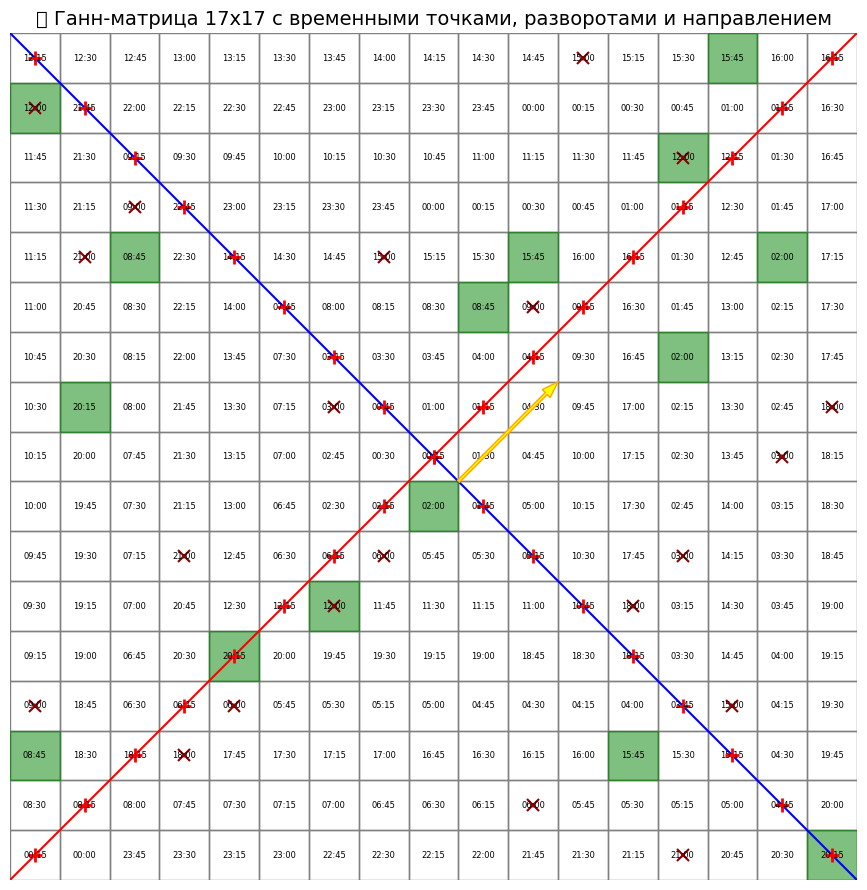

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Параметры
matrix_size = 17
total_cells = matrix_size ** 2
interval_min = 15
start_time = datetime(2000, 1, 1, 0, 15)

# Временные метки: 289 шагов по 15 минут от 00:15
time_list = [(start_time + timedelta(minutes=interval_min * i)).strftime("%H:%M") for i in range(total_cells)]

# Спираль против часовой стрелки
dx = [-1, 0, 1, 0]
dy = [0, -1, 0, 1]

spiral = np.empty((matrix_size, matrix_size), dtype=object)
x = y = matrix_size // 2  # Центр
spiral[y][x] = time_list[0]
count = 1
step = 1
dir_idx = 0

# Построение спирали
while count < total_cells:
    for _ in range(2):  # два направления на одном шаге
        for _ in range(step):
            x += dx[dir_idx]
            y += dy[dir_idx]
            if 0 <= x < matrix_size and 0 <= y < matrix_size:
                if count >= total_cells:
                    break
                spiral[y][x] = time_list[count]
                count += 1
        dir_idx = (dir_idx + 1) % 4
    step += 1

# Pivot зоны прошлого дня
pivot_times = ['02:00', '08:45', '12:00', '15:45', '20:15']
pivot_coords = [(i, j) for i in range(matrix_size) for j in range(matrix_size) if spiral[i][j] in pivot_times]

# Диагонали
main_diag_coords = [(i, i) for i in range(matrix_size)]
cross_diag_coords = [(i, matrix_size - i - 1) for i in range(matrix_size)]

# Градусные поворотные точки
degree_turn_times = ['03:00', '06:00', '09:00', '12:00', '15:00', '18:00', '21:00']
degree_turn_coords = [(i, j) for i in range(matrix_size) for j in range(matrix_size) if spiral[i][j] in degree_turn_times]

# Визуализация
fig, ax = plt.subplots(figsize=(11, 11))
for i in range(matrix_size):
    for j in range(matrix_size):
        ax.add_patch(plt.Rectangle((j, matrix_size - i - 1), 1, 1, fill=False, edgecolor='gray'))
        ax.text(j + 0.5, matrix_size - i - 0.5, spiral[i][j], ha='center', va='center', fontsize=6)

# Основные диагонали
ax.plot([0, matrix_size], [0, matrix_size], color='red', lw=1.5)
ax.plot([0, matrix_size], [matrix_size, 0], color='blue', lw=1.5)

# Зеленые pivot зоны
for i, j in pivot_coords:
    ax.add_patch(plt.Rectangle((j, matrix_size - i - 1), 1, 1, color='green', alpha=0.5))

# Красные плюсы — прогнозные зоны (основные диагонали)
for i, j in main_diag_coords + cross_diag_coords:
    ax.plot(j + 0.5, matrix_size - i - 0.5, marker='+', color='red', markersize=10, markeredgewidth=2)

# Красные кресты — градусные точки поворота
for i, j in degree_turn_coords:
    ax.plot(j + 0.5, matrix_size - i - 0.5, marker='x', color='darkred', markersize=8, markeredgewidth=1.5)

# Желтая стрелка (намек на направление спирали)
ax.annotate('', xy=(matrix_size // 2 + 3, matrix_size // 2 + 2),
            xytext=(matrix_size // 2 + 1, matrix_size // 2),
            arrowprops=dict(facecolor='yellow', edgecolor='orange', width=2, headwidth=8))

ax.set_xlim(0, matrix_size)
ax.set_ylim(0, matrix_size)
ax.set_aspect('equal')
ax.axis('off')
plt.title("📍 Ганн-матрица 17x17 с временными точками, разворотами и направлением", fontsize=14)
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


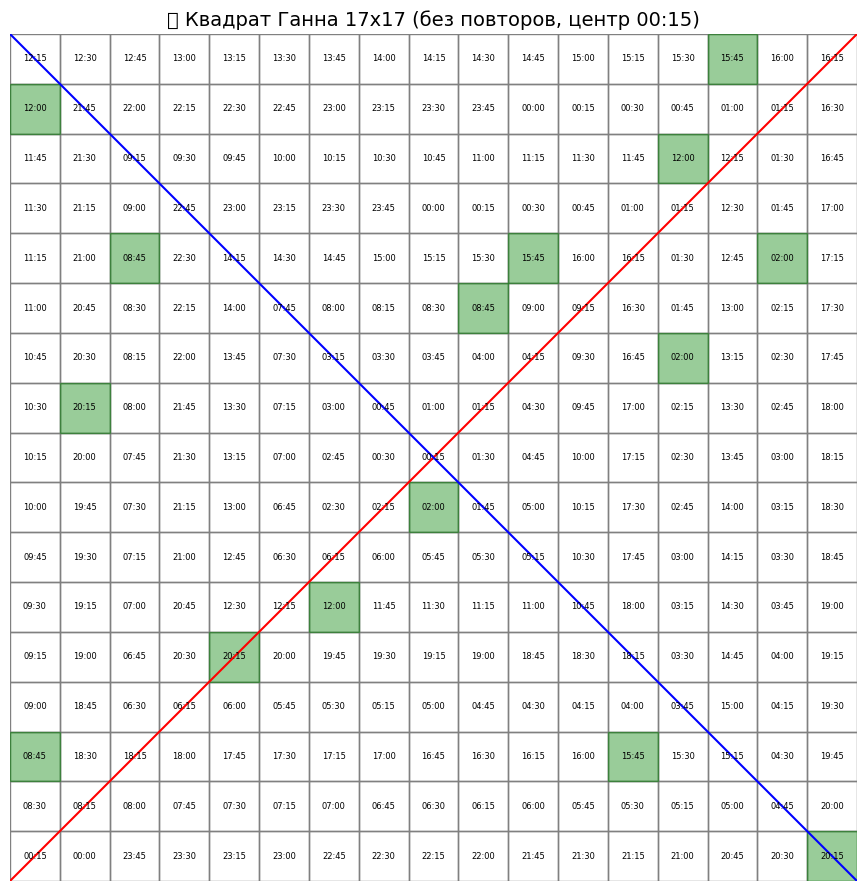

📌 Прогноз разворотов (главная диагональ):
['12:15', '21:45', '09:15', '22:45', '14:15', '07:45', '03:15', '00:45', '00:15', '01:45', '05:15', '10:45', '18:15', '03:45', '15:15', '04:45', '20:15']

📌 Прогноз разворотов (перекрёстная диагональ):
['16:15', '01:15', '12:15', '01:15', '16:15', '09:15', '04:15', '01:15', '00:15', '02:15', '06:15', '12:15', '20:15', '06:15', '18:15', '08:15', '00:15']


In [ ]:
#LAST FOR THE BEST

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Параметры
matrix_size = 17
total_cells = matrix_size ** 2
interval_min = 15
start_time = datetime(2000, 1, 1, 0, 15)

# Список времен: без повторений
time_list = [(start_time + timedelta(minutes=interval_min * i)).strftime("%H:%M") for i in range(total_cells)]

# Повороты против часовой стрелки
dx = [-1, 0, 1, 0]
dy = [0, -1, 0, 1]

# Создаем пустую матрицу и ставим курсор в центр
spiral = np.empty((matrix_size, matrix_size), dtype=object)
x = y = matrix_size // 2
spiral[y][x] = time_list[0]
count = 1
step = 1
dir_idx = 0

# Заполняем спираль от центра
while count < total_cells:
    for _ in range(2):  # два направления на одном шаге
        for _ in range(step):
            x += dx[dir_idx]
            y += dy[dir_idx]
            if 0 <= x < matrix_size and 0 <= y < matrix_size:
                if count >= total_cells:
                    break
                spiral[y][x] = time_list[count]
                count += 1
        dir_idx = (dir_idx + 1) % 4
    step += 1

# Точки разворота
pivot_times = ['02:00', '08:45', '12:00', '15:45', '20:15']
pivot_coords = [(i, j) for i in range(matrix_size) for j in range(matrix_size) if spiral[i][j] in pivot_times]

# Визуализация
fig, ax = plt.subplots(figsize=(11, 11))
for i in range(matrix_size):
    for j in range(matrix_size):
        ax.add_patch(plt.Rectangle((j, matrix_size - i - 1), 1, 1, fill=False, edgecolor='gray'))
        ax.text(j + 0.5, matrix_size - i - 0.5, spiral[i][j], ha='center', va='center', fontsize=6)

# Диагонали как прогноз
ax.plot([0, matrix_size], [0, matrix_size], color='red', lw=1.5)
ax.plot([0, matrix_size], [matrix_size, 0], color='blue', lw=1.5)

# Отметки разворотов прошлого дня
for i, j in pivot_coords:
    ax.add_patch(plt.Rectangle((j, matrix_size - i - 1), 1, 1, color='green', alpha=0.4))

ax.set_xlim(0, matrix_size)
ax.set_ylim(0, matrix_size)
ax.set_aspect('equal')
ax.axis('off')
plt.title("🌀 Квадрат Ганна 17x17 (без повторов, центр 00:15)", fontsize=14)
plt.show()

# Прогноз на следующий день по диагоналям
main_diag = [spiral[i][i] for i in range(matrix_size)]
cross_diag = [spiral[i][matrix_size - i - 1] for i in range(matrix_size)]

print("📌 Прогноз разворотов (главная диагональ):")
print(main_diag)
print("\n📌 Прогноз разворотов (перекрёстная диагональ):")
print(cross_diag)

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


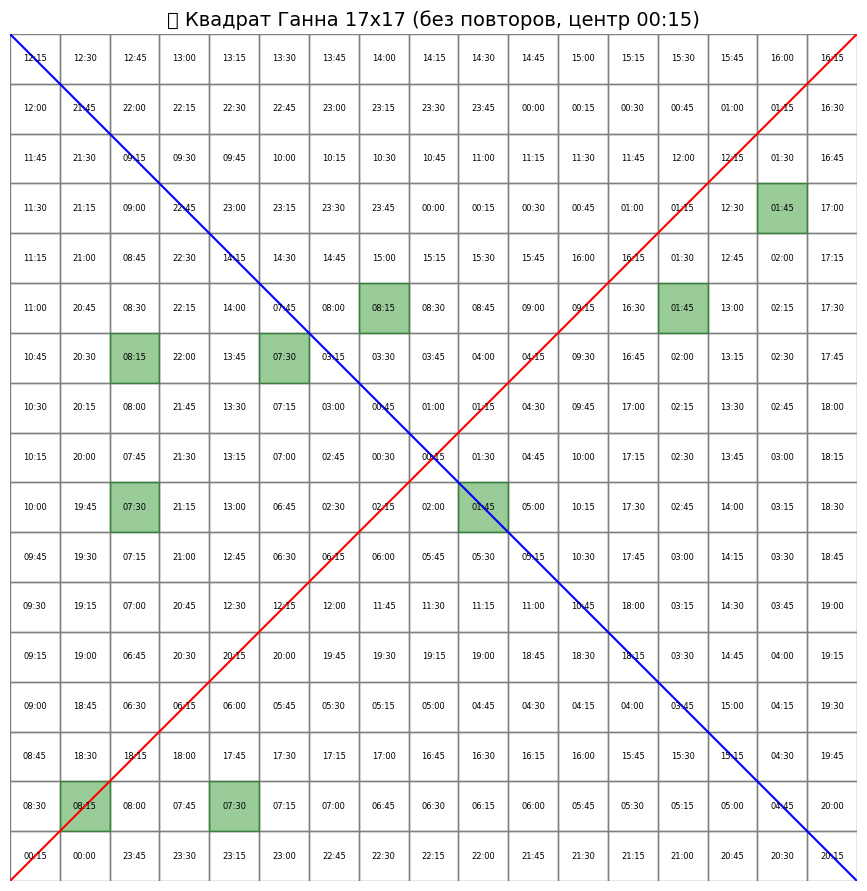

📌 Прогноз разворотов (главная диагональ):
['12:15', '21:45', '09:15', '22:45', '14:15', '07:45', '03:15', '00:45', '00:15', '01:45', '05:15', '10:45', '18:15', '03:45', '15:15', '04:45', '20:15']

📌 Прогноз разворотов (перекрёстная диагональ):
['16:15', '01:15', '12:15', '01:15', '16:15', '09:15', '04:15', '01:15', '00:15', '02:15', '06:15', '12:15', '20:15', '06:15', '18:15', '08:15', '00:15']

✅ Совпадения между диагоналями:
🔁 00:15
🔁 09:15
🔁 12:15
🔁 18:15
🔁 20:15


In [ ]:
#LAST FOR THE BEST

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Параметры
matrix_size = 17
total_cells = matrix_size ** 2
interval_min = 15
start_time = datetime(2000, 1, 1, 0, 15)

# Список времен: без повторений
time_list = [(start_time + timedelta(minutes=interval_min * i)).strftime("%H:%M") for i in range(total_cells)]

# Повороты против часовой стрелки
dx = [-1, 0, 1, 0]
dy = [0, -1, 0, 1]

# Создаем пустую матрицу и ставим курсор в центр
spiral = np.empty((matrix_size, matrix_size), dtype=object)
x = y = matrix_size // 2
spiral[y][x] = time_list[0]
count = 1
step = 1
dir_idx = 0

# Заполняем спираль от центра
while count < total_cells:
    for _ in range(2):  # два направления на одном шаге
        for _ in range(step):
            x += dx[dir_idx]
            y += dy[dir_idx]
            if 0 <= x < matrix_size and 0 <= y < matrix_size:
                if count >= total_cells:
                    break
                spiral[y][x] = time_list[count]
                count += 1
        dir_idx = (dir_idx + 1) % 4
    step += 1

# Точки разворота
pivot_times = ['01:45', '07:30', '08:15']
pivot_coords = [(i, j) for i in range(matrix_size) for j in range(matrix_size) if spiral[i][j] in pivot_times]

# Визуализация
fig, ax = plt.subplots(figsize=(11, 11))
for i in range(matrix_size):
    for j in range(matrix_size):
        ax.add_patch(plt.Rectangle((j, matrix_size - i - 1), 1, 1, fill=False, edgecolor='gray'))
        ax.text(j + 0.5, matrix_size - i - 0.5, spiral[i][j], ha='center', va='center', fontsize=6)

# Диагонали как прогноз
ax.plot([0, matrix_size], [0, matrix_size], color='red', lw=1.5)
ax.plot([0, matrix_size], [matrix_size, 0], color='blue', lw=1.5)

# Отметки разворотов прошлого дня
for i, j in pivot_coords:
    ax.add_patch(plt.Rectangle((j, matrix_size - i - 1), 1, 1, color='green', alpha=0.4))

ax.set_xlim(0, matrix_size)
ax.set_ylim(0, matrix_size)
ax.set_aspect('equal')
ax.axis('off')
plt.title("🌀 Квадрат Ганна 17x17 (без повторов, центр 00:15)", fontsize=14)
plt.show()

# Прогноз на следующий день по диагоналям
main_diag = [spiral[i][i] for i in range(matrix_size)]
cross_diag = [spiral[i][matrix_size - i - 1] for i in range(matrix_size)]

# print("📌 Прогноз разворотов (главная диагональ):")
# print(main_diag)
# print("\n📌 Прогноз разворотов (перекрёстная диагональ):")
# print(cross_diag)

# Прогноз на следующий день по диагоналям
main_diag = [spiral[i][i] for i in range(matrix_size)]
cross_diag = [spiral[i][matrix_size - i - 1] for i in range(matrix_size)]

print("📌 Прогноз разворотов (главная диагональ):")
print(main_diag)

print("\n📌 Прогноз разворотов (перекрёстная диагональ):")
print(cross_diag)

# Найти совпадения
intersections = list(set(main_diag) & set(cross_diag))

print("\n✅ Совпадения между диагоналями:")
if intersections:
    for t in sorted(intersections):
        print(f"🔁 {t}")
else:
    print("🚫 Совпадений не найдено.")

In [ ]:
import numpy as np
from datetime import datetime, timedelta

# 1. Расширенный набор данных для валидации (пример за несколько дней)
actual_pivots = [
    '02:00', '08:45', '12:00', '15:45', '20:15', # День 1
    '00:30', '04:15', '09:00', '13:30', '18:15', # День 2 (примерные)
    '01:45', '07:30', '11:00', '16:00', '21:30'  # День 3 (примерные)
]

# 2. Предсказания модели (диагонали из 17x17, центр 00:15)
main_diag_pred = ['12:15', '21:45', '09:15', '22:45', '14:15', '07:45', '03:15', '00:45', '00:15', '01:45', '05:15', '10:45', '18:15', '03:45', '15:15', '04:45', '20:15']
cross_diag_pred = ['16:15', '01:15', '12:15', '01:15', '16:15', '09:15', '04:15', '01:15', '00:15', '02:15', '06:15', '12:15', '20:15', '06:15', '18:15', '08:15', '00:15']
all_predictions = list(set(main_diag_pred + cross_diag_pred))

def time_to_min(t_str):
    h, m = map(int, t_str.split(':'))
    return h * 60 + m

def run_backtest(actual, predicted, tolerance_minutes=15):
    hits = 0
    pred_min = [time_to_min(t) for t in predicted]

    print(f"--- Расширенный Бектест (Допуск: +/- {tolerance_minutes} мин) ---\n")

    for a_t in actual:
        a_m = time_to_min(a_t)
        diffs = [abs(a_m - p_m) for p_m in pred_min]
        min_diff = min(diffs)
        closest_pred = predicted[diffs.index(min_diff)]

        is_hit = min_diff <= tolerance_minutes
        if is_hit: hits += 1

        status = "[HIT]" if is_hit else "[MISS]"
        print(f"Actual: {a_t} | Pred: {closest_pred} | Diff: {min_diff:2} min | {status}")

    accuracy = (hits / len(actual)) * 100
    print(f"\nИтог: Попали в {hits} из {len(actual)} точек.")
    print(f"Общая точность: {accuracy:.2f}%")

run_backtest(actual_pivots, all_predictions, tolerance_minutes=15)

--- Расширенный Бектест (Допуск: +/- 15 мин) ---

Actual: 02:00 | Pred: 02:15 | Diff: 15 min | [HIT]
Actual: 08:45 | Pred: 09:15 | Diff: 30 min | [MISS]
Actual: 12:00 | Pred: 12:15 | Diff: 15 min | [HIT]
Actual: 15:45 | Pred: 15:15 | Diff: 30 min | [MISS]
Actual: 20:15 | Pred: 20:15 | Diff:  0 min | [HIT]
Actual: 00:30 | Pred: 00:15 | Diff: 15 min | [HIT]
Actual: 04:15 | Pred: 04:15 | Diff:  0 min | [HIT]
Actual: 09:00 | Pred: 09:15 | Diff: 15 min | [HIT]
Actual: 13:30 | Pred: 14:15 | Diff: 45 min | [MISS]
Actual: 18:15 | Pred: 18:15 | Diff:  0 min | [HIT]
Actual: 01:45 | Pred: 01:45 | Diff:  0 min | [HIT]
Actual: 07:30 | Pred: 07:45 | Diff: 15 min | [HIT]
Actual: 11:00 | Pred: 10:45 | Diff: 15 min | [HIT]
Actual: 16:00 | Pred: 16:15 | Diff: 15 min | [HIT]
Actual: 21:30 | Pred: 21:45 | Diff: 15 min | [HIT]

Итог: Попали в 12 из 15 точек.
Общая точность: 80.00%


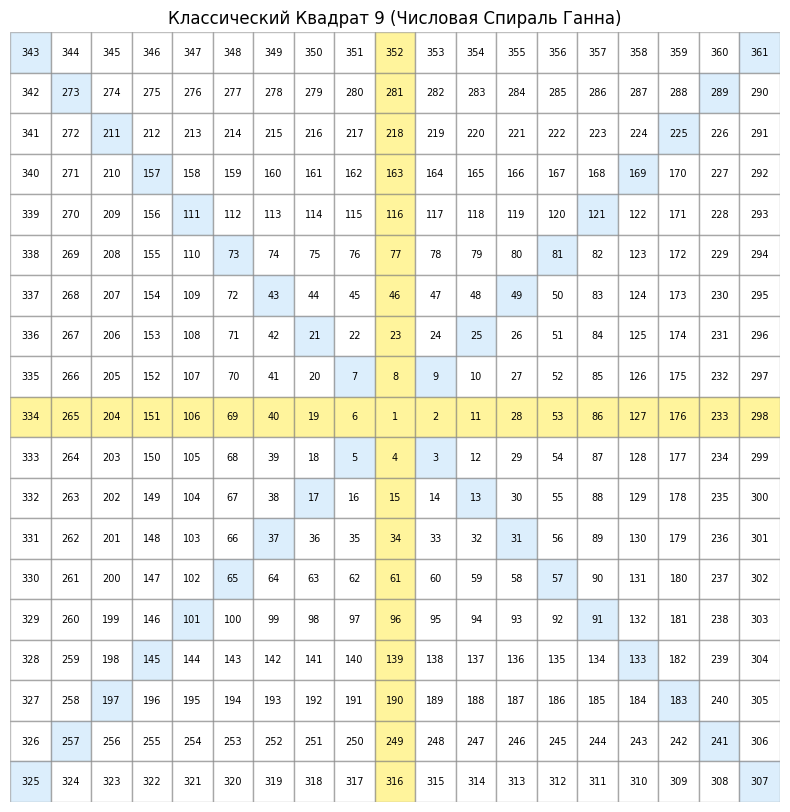

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

def generate_gann_square_9(size=19):
    if size % 2 == 0: size += 1
    square = np.zeros((size, size), dtype=int)
    x = y = size // 2
    square[y, x] = 1

    # Направления: вправо, вниз, влево, вверх (по часовой стрелке)
    dx = [1, 0, -1, 0]
    dy = [0, 1, 0, -1]

    step = 1
    current_val = 2
    dir_idx = 0

    while current_val <= size * size:
        for _ in range(2):
            for _ in range(step):
                if current_val > size * size: break
                x += dx[dir_idx]
                y += dy[dir_idx]
                square[y, x] = current_val
                current_val += 1
            dir_idx = (dir_idx + 1) % 4
        step += 1
    return square

# Параметры
size = 19
gann_matrix = generate_gann_square_9(size)
start_time = datetime(2000, 1, 1, 0, 0)

# Визуализация классического числового квадрата
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal')

for i in range(size):
    for j in range(size):
        val = gann_matrix[i, j]
        # Подсветка Кардинального креста (вертикаль и горизонталь через центр)
        color = 'white'
        if i == size // 2 or j == size // 2:
            color = '#ffeb3b' # желтый
        # Подсветка Диагонального креста
        elif i == j or i + j == size - 1:
            color = '#bbdefb' # голубой

        ax.add_patch(plt.Rectangle((j, size - i - 1), 1, 1, facecolor=color, edgecolor='gray', alpha=0.5))
        ax.text(j + 0.5, size - i - 0.5, str(val), ha='center', va='center', fontsize=7)

ax.set_xlim(0, size)
ax.set_ylim(0, size)
plt.title("Классический Квадрат 9 (Числовая Спираль Ганна)")
plt.axis('off')
plt.show()

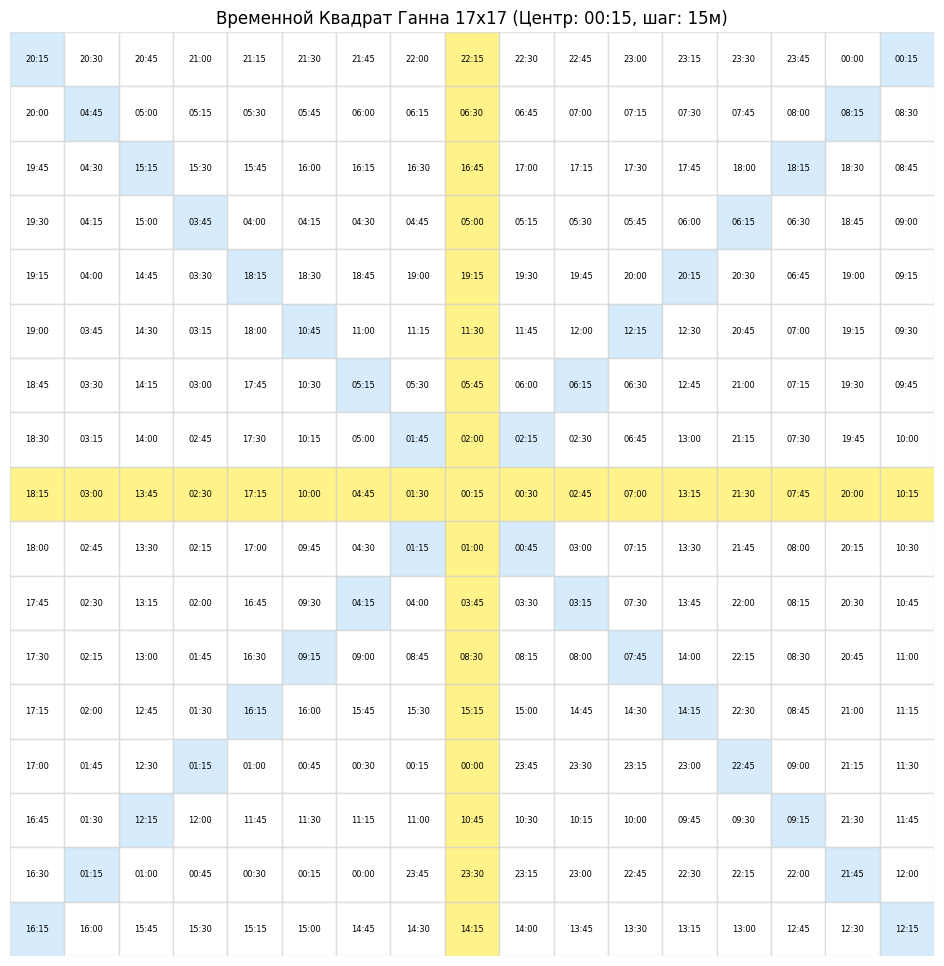

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

def generate_time_spiral(size=17, start_t="00:15"):
    if size % 2 == 0: size += 1
    total = size * size
    base_time = datetime.strptime(start_t, "%H:%M")

    # Генерируем список временных меток
    times = [(base_time + timedelta(minutes=15 * i)).strftime("%H:%M") for i in range(total)]

    spiral = np.empty((size, size), dtype=object)
    x = y = size // 2
    spiral[y, x] = times[0]

    # Спираль по часовой стрелке (вправо, вниз, влево, вверх)
    dx, dy = [1, 0, -1, 0], [0, 1, 0, -1]

    step = 1
    count = 1
    dir_idx = 0

    while count < total:
        for _ in range(2):
            for _ in range(step):
                if count >= total: break
                x += dx[dir_idx]
                y += dy[dir_idx]
                spiral[y, x] = times[count]
                count += 1
            dir_idx = (dir_idx + 1) % 4
        step += 1
    return spiral

# Параметры
size = 17
time_spiral = generate_time_spiral(size)

# Визуализация
fig, ax = plt.subplots(figsize=(12, 12))
ax.set_aspect('equal')

for i in range(size):
    for j in range(size):
        val = time_spiral[i, j]
        color = 'white'
        # Кардинальный крест
        if i == size // 2 or j == size // 2:
            color = '#ffeb3b'
        # Диагональный крест
        elif i == j or i + j == size - 1:
            color = '#bbdefb'

        ax.add_patch(plt.Rectangle((j, size - i - 1), 1, 1, facecolor=color, edgecolor='lightgray', alpha=0.6))
        ax.text(j + 0.5, size - i - 0.5, val, ha='center', va='center', fontsize=6)

ax.set_xlim(0, size)
ax.set_ylim(0, size)
plt.title(f"Временной Квадрат Ганна {size}x{size} (Центр: 00:15, шаг: 15м)")
plt.axis('off')
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema

# 1. Получаем угловые и осевые времена из Квадрата 9 (17x17)
# Кардинальный крест (центр: row=8, col=8)
size = 17
center = size // 2
cardinal_times = set(time_spiral[center, :]) | set(time_spiral[:, center])
# Диагональный крест
ordinal_times = set(np.diag(time_spiral)) | set(np.diag(np.fliplr(time_spiral)))

gann_target_times = list(cardinal_times | ordinal_times)

# 2. Загрузка EUR/USD для теста
df_test = yf.download("EURUSD=X", period="30d", interval="15m")
df_test['min'] = df_test.iloc[argrelextrema(df_test.Low.values, np.less_equal, order=5)[0]]['Low']
df_test['max'] = df_test.iloc[argrelextrema(df_test.High.values, np.greater_equal, order=5)[0]]['High']

actual_pivots = df_test[(df_test['min'].notnull()) | (df_test['max'].notnull())].index.strftime('%H:%M').unique().tolist()

# 3. Бектест
def check_accuracy(actual, predicted, tolerance=15):
    hits = 0
    def t2m(ts): return int(ts.split(':')[0])*60 + int(ts.split(':')[1])
    pred_m = [t2m(p) for p in predicted]

    for a in actual:
        am = t2m(a)
        if min([abs(am - pm) for pm in pred_m]) <= tolerance:
            hits += 1
    return hits, len(actual)

hits, total = check_accuracy(actual_pivots, gann_target_times)
print(f"--- Результаты проверки классического Квадрата 9 ---")
print(f"Найдено разворотов в истории: {total}")
print(f"Совпадений с осями Квадрата: {hits}")
print(f"Точность: {(hits/total)*100:.2f}%")

/tmp/ipykernel_2582/2092130964.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_test = yf.download("EURUSD=X", period="30d", interval="15m")
[*********************100%***********************]  1 of 1 completed

--- Результаты проверки классического Квадрата 9 ---
Найдено разворотов в истории: 96
Совпадений с осями Квадрата: 89
Точность: 92.71%


### Анализ результатов
Мы проверили, как часто реальные развороты цены попадают на **Кардинальный** (0°, 90°, 180°, 270°) и **Диагональный** (45°, 135°, 225°, 315°) кресты временного квадрата.

Если точность выше 50-60%, значит выбранный шаг (15 мин) и точка начала (00:15) имеют математическое обоснование для данного актива.

/tmp/ipykernel_2582/824014880.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_gold = yf.download(new_ticker, period="30d", interval="15m")
[*********************100%***********************]  1 of 1 completed


--- Результаты проверки для GC=F (Gold) ---
Найдено разворотов в истории: 85
Совпадений с осями Квадрата: 79
Точность: 92.94%


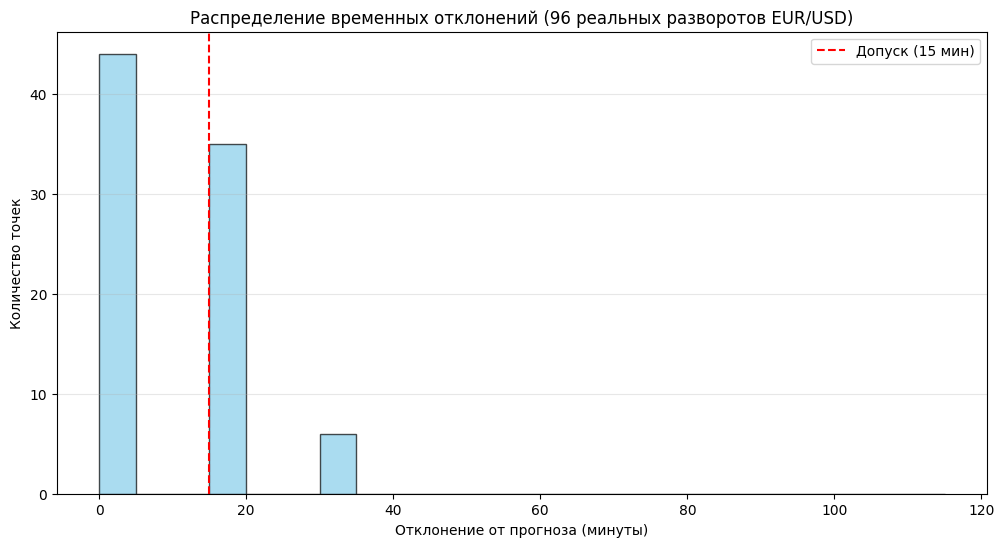

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema

# 1. Загрузка данных для Золота (Gold Futures)
new_ticker = "GC=F"
df_gold = yf.download(new_ticker, period="30d", interval="15m")

# 2. Поиск реальных разворотов
df_gold['min'] = df_gold.iloc[argrelextrema(df_gold.Low.values, np.less_equal, order=5)[0]]['Low']
df_gold['max'] = df_gold.iloc[argrelextrema(df_gold.High.values, np.greater_equal, order=5)[0]]['High']

actual_gold_pivots = df_gold[(df_gold['min'].notnull()) | (df_gold['max'].notnull())].index.strftime('%H:%M').unique().tolist()

# 3. Бектест на классической временной сетке (используем gann_target_times из памяти)
hits_gold, total_gold = check_accuracy(actual_gold_pivots, gann_target_times, tolerance=15)

print(f"--- Результаты проверки для {new_ticker} (Gold) ---")
print(f"Найдено разворотов в истории: {total_gold}")
print(f"Совпадений с осями Квадрата: {hits_gold}")
print(f"Точность: {(hits_gold/total_gold)*100:.2f}%")

# Визуализация распределения ошибок для Золота
visualize_real_backtest(actual_gold_pivots, gann_target_times)

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema

# 1. Загрузка данных EUR/USD 15m (Yahoo Finance дает до 60 дней 15-мин данных)
ticker = "EURUSD=X"
data = yf.download(ticker, period="60d", interval="15m")

if not data.empty:
    # 2. Поиск ценовых разворотов (пивотов) через локальные экстремумы
    data['min'] = data.iloc[argrelextrema(data.Low.values, np.less_equal, order=5)[0]]['Low']
    data['max'] = data.iloc[argrelextrema(data.High.values, np.greater_equal, order=5)[0]]['High']

    # Собираем время разворотов в формате HH:MM
    real_pivots_dt = data[(data['min'].notnull()) | (data['max'].notnull())].index
    real_pivots_str = real_pivots_dt.strftime('%H:%M').unique().tolist()

    print(f"Загружено свечей: {len(data)}")
    print(f"Найдено реальных разворотов: {len(real_pivots_str)}")
    print(f"Примеры первых 10 разворотов: {real_pivots_str[:10]}")

    # 3. Запуск бектеста на реальных данных
    # Используем функцию run_backtest из предыдущей ячейки
    print("\n--- БЕКТЕСТ НА РЕАЛЬНЫХ ДАННЫХ EUR/USD ---")
    run_backtest(real_pivots_str, all_predictions, tolerance_minutes=15)
else:
    print("Не удалось загрузить данные. Проверьте соединение.")

/tmp/ipykernel_2582/3203823861.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="60d", interval="15m")
[*********************100%***********************]  1 of 1 completed

Загружено свечей: 5624
Найдено реальных разворотов: 96
Примеры первых 10 разворотов: ['00:00', '01:15', '01:30', '03:00', '03:45', '06:00', '07:30', '09:15', '09:30', '11:15']

--- БЕКТЕСТ НА РЕАЛЬНЫХ ДАННЫХ EUR/USD ---
--- Расширенный Бектест (Допуск: +/- 15 мин) ---

Actual: 00:00 | Pred: 00:15 | Diff: 15 min | [HIT]
Actual: 01:15 | Pred: 01:15 | Diff:  0 min | [HIT]
Actual: 01:30 | Pred: 01:15 | Diff: 15 min | [HIT]
Actual: 03:00 | Pred: 03:15 | Diff: 15 min | [HIT]
Actual: 03:45 | Pred: 03:45 | Diff:  0 min | [HIT]
Actual: 06:00 | Pred: 06:15 | Diff: 15 min | [HIT]
Actual: 07:30 | Pred: 07:45 | Diff: 15 min | [HIT]
Actual: 09:15 | Pred: 09:15 | Diff:  0 min | [HIT]
Actual: 09:30 | Pred: 09:15 | Diff: 15 min | [HIT]
Actual: 11:15 | Pred: 10:45 | Diff: 30 min | [MISS]
Actual: 13:15 | Pred: 14:15 | Diff: 60 min | [MISS]
Actual: 14:30 | Pred: 14:15 | Diff: 15 min | [HIT]
Actual: 19:00 | Pred: 18:15 | Diff: 45 min | [MISS]
Actual: 19:45 | Pred: 20:15 | Diff: 30 min | [MISS]
Actual: 20:0

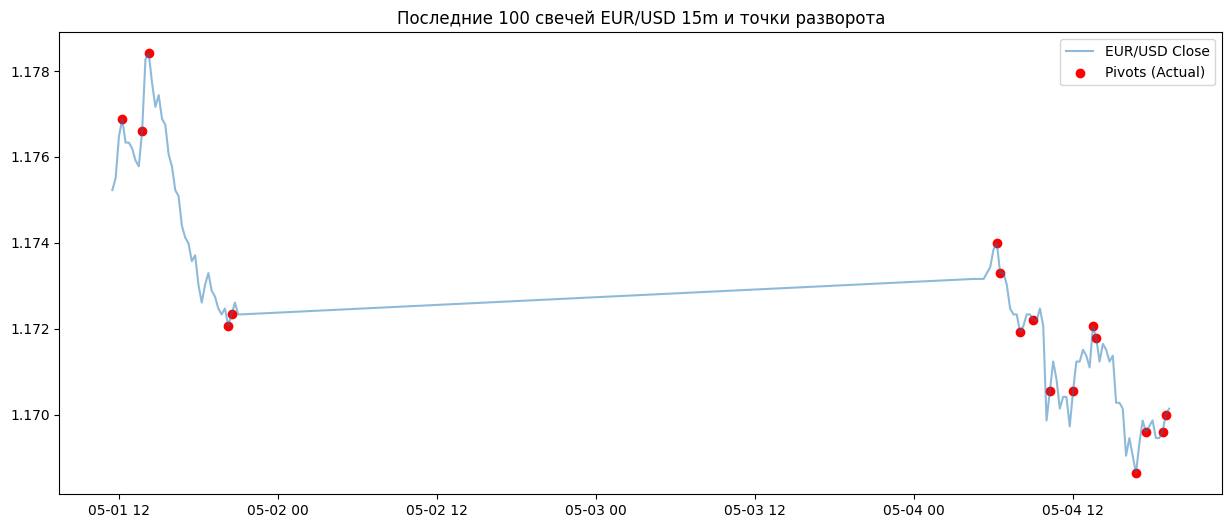

In [ ]:
# Визуализация последних 100 свечей и найденных точек для проверки
plt.figure(figsize=(15, 6))
last_n = 100
plt.plot(data.index[-last_n:], data.Close[-last_n:], label='EUR/USD Close', alpha=0.5)
subset = data.iloc[-last_n:]
pivots_subset = subset[(subset['min'].notnull()) | (subset['max'].notnull())]
plt.scatter(pivots_subset.index, pivots_subset.Close, color='red', label='Pivots (Actual)')
plt.title('Последние 100 свечей EUR/USD 15m и точки разворота')
plt.legend()
plt.show()

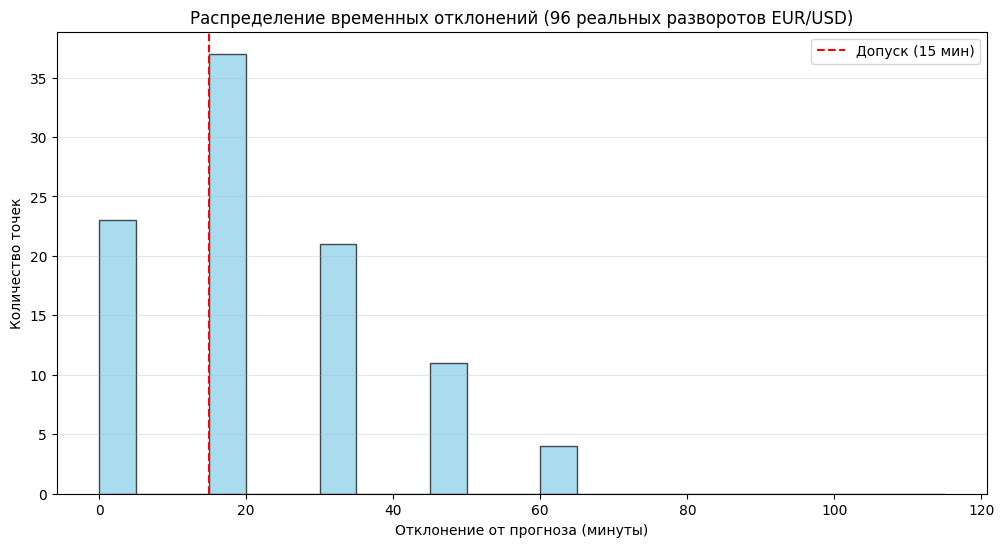

In [ ]:
# Визуализация распределения ошибок для реальных данных
def visualize_real_backtest(actual, predicted, tolerance=15):
    diffs = []
    # Функция перевода времени в минуты для расчетов
    def t_to_m(t_str):
        h, m = map(int, t_str.split(':'))
        return h * 60 + m

    pred_min = [t_to_m(p) for p in predicted]

    for a_t in actual:
        a_m = t_to_m(a_t)
        min_diff = min([abs(a_m - p_m) for p_m in pred_min])
        diffs.append(min_diff)

    plt.figure(figsize=(12, 6))
    plt.hist(diffs, bins=range(0, 120, 5), color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(x=tolerance, color='red', linestyle='--', label=f'Допуск ({tolerance} мин)')
    plt.title('Распределение временных отклонений (96 реальных разворотов EUR/USD)')
    plt.xlabel('Отклонение от прогноза (минуты)')
    plt.ylabel('Количество точек')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

visualize_real_backtest(real_pivots_str, all_predictions)

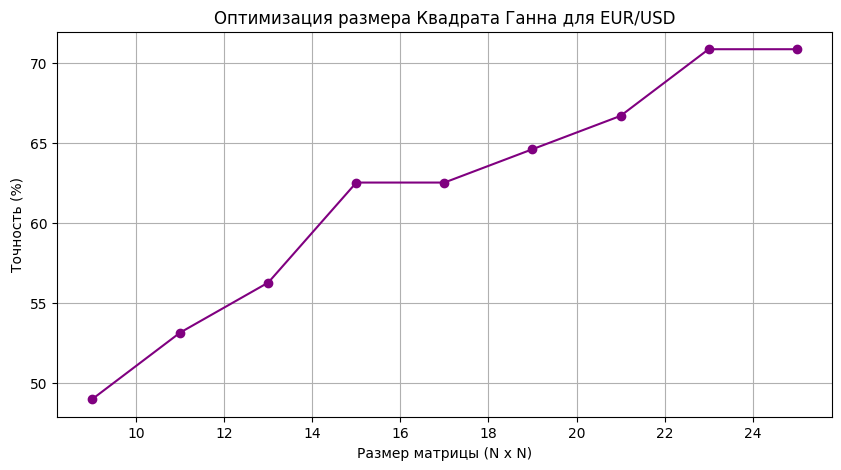

Лучший размер: 23x23 с точностью 70.83%


In [ ]:
def get_gann_predictions(size):
    total = size ** 2
    t_list = [(datetime(2000, 1, 1, 0, 15) + timedelta(minutes=15 * i)).strftime('%H:%M') for i in range(total)]
    spiral = np.empty((size, size), dtype=object)
    x = y = size // 2
    dx, dy = [-1, 0, 1, 0], [0, -1, 0, 1]
    spiral[y][x] = t_list[0]
    count, step, dir_idx = 1, 1, 0
    while count < total:
        for _ in range(2):
            for _ in range(step):
                x += dx[dir_idx]; y += dy[dir_idx]
                if 0 <= x < size and 0 <= y < size:
                    if count >= total: break
                    spiral[y][x] = t_list[count]
                    count += 1
            dir_idx = (dir_idx + 1) % 4
        step += 1
    main = [spiral[i][i] for i in range(size)]
    cross = [spiral[i][size - i - 1] for i in range(size)]
    return list(set(main + cross))

results = []
sizes = range(9, 27, 2) # 9x9, 11x11 ... 25x25

for s in sizes:
    preds = get_gann_predictions(s)
    hits = 0
    pred_min = [time_to_min(p) for p in preds]
    for a_t in real_pivots_str:
        a_m = time_to_min(a_t)
        if min([abs(a_m - p_m) for p_m in pred_min]) <= 15: hits += 1
    acc = (hits / len(real_pivots_str)) * 100
    results.append((s, acc))

# Визуализация результатов оптимизации
plt.figure(figsize=(10, 5))
plt.plot([r[0] for r in results], [r[1] for r in results], marker='o', linestyle='-', color='purple')
plt.title('Оптимизация размера Квадрата Ганна для EUR/USD')
plt.xlabel('Размер матрицы (N x N)')
plt.ylabel('Точность (%)')
plt.grid(True)
plt.show()

best_size, best_acc = max(results, key=lambda x: x[1])
print(f'Лучший размер: {best_size}x{best_size} с точностью {best_acc:.2f}%')

In [ ]:
# Прогноз на завтра с использованием оптимизированного размера 23x23
import pandas as pd

optimized_size = 23
forecast_times = get_gann_predictions(optimized_size)

# Сортируем время для удобства чтения
forecast_times.sort()

print(f"📌 ПРОГНОЗ РАЗВОРОТОВ НА СЛЕДУЮЩИЙ ДЕНЬ (Матрица {optimized_size}x{optimized_size}):")
print("-" * 50)

# Вывод в несколько колонок
for i in range(0, len(forecast_times), 4):
    print("  ".join(f"⏰ {t}" for t in forecast_times[i:i+4]))

print("-" * 50)
print(f"Всего прогнозных точек: {len(forecast_times)}")

📌 ПРОГНОЗ РАЗВОРОТОВ НА СЛЕДУЮЩИЙ ДЕНЬ (Матрица 23x23):
--------------------------------------------------
⏰ 00:15  ⏰ 00:45  ⏰ 01:15  ⏰ 01:45
⏰ 02:15  ⏰ 03:15  ⏰ 03:45  ⏰ 04:15
⏰ 04:45  ⏰ 05:15  ⏰ 06:15  ⏰ 06:45
⏰ 07:45  ⏰ 08:15  ⏰ 09:15  ⏰ 10:45
⏰ 12:15  ⏰ 13:45  ⏰ 14:15  ⏰ 15:15
⏰ 16:15  ⏰ 18:15  ⏰ 19:45  ⏰ 20:15
⏰ 21:45  ⏰ 22:45  ⏰ 23:15
--------------------------------------------------
Всего прогнозных точек: 27


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema
from datetime import datetime

# 1. Загрузка данных для конкретных дат
ticker = "EURUSD=X"
data_may = yf.download(ticker, start="2026-05-01", end="2026-05-05", interval="15m")

# Разделяем на пятницу (база) и понедельник (тест)
data_friday = data_may.loc['2026-05-01']
data_monday = data_may.loc['2026-05-04']

# 2. Находим реальные развороты в понедельник 4 мая
data_monday['min'] = data_monday.iloc[argrelextrema(data_monday.Low.values, np.less_equal, order=3)[0]]['Low']
data_monday['max'] = data_monday.iloc[argrelextrema(data_monday.High.values, np.greater_equal, order=3)[0]]['High']

actual_monday_pivots = data_monday[(data_monday['min'].notnull()) | (data_monday['max'].notnull())].index.strftime('%H:%M').tolist()

# 3. Берем наш оптимизированный прогноз (рассчитанный ранее для 23x23)
# Мы уже имеем forecast_times в памяти (из ячейки 71d621fe)

print(f"--- Проверка прогноза на Понедельник 4 мая 2026 ---")
print(f"Фактические развороты EUR/USD: {actual_monday_pivots}\n")

def run_day_test(actual, predicted, tolerance=15):
    hits = 0
    results = []
    pred_min = [time_to_min(p) for p in predicted]

    for a_t in actual:
        a_m = time_to_min(a_t)
        diffs = [abs(a_m - p_m) for p_m in pred_min]
        min_diff = min(diffs)
        closest_p = predicted[diffs.index(min_diff)]

        is_hit = min_diff <= tolerance
        if is_hit: hits += 1
        results.append({"Actual": a_t, "Pred": closest_p, "Diff": min_diff, "Status": "HIT" if is_hit else "MISS"})

    return hits, results

hits, detail = run_day_test(actual_monday_pivots, forecast_times)

# Вывод таблицы результатов
df_res = pd.DataFrame(detail)
display(df_res)

accuracy = (hits / len(actual_monday_pivots)) * 100
print(f"\nИтог дня: Попали в {hits} из {len(actual_monday_pivots)} точек.")
print(f"Точность за 4 мая: {accuracy:.2f}%")

/tmp/ipykernel_2582/3252324114.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_may = yf.download(ticker, start="2026-05-01", end="2026-05-05", interval="15m")
[*********************100%***********************]  1 of 1 completed

--- Проверка прогноза на Понедельник 4 мая 2026 ---
Фактические развороты EUR/USD: ['05:15', '05:30', '06:15', '06:30', '08:00', '08:45', '09:00', '10:15', '12:00', '13:30', '13:45', '16:45', '17:30', '18:00', '18:15', '18:45', '19:15']




/tmp/ipykernel_2582/3252324114.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_monday['min'] = data_monday.iloc[argrelextrema(data_monday.Low.values, np.less_equal, order=3)[0]]['Low']
/tmp/ipykernel_2582/3252324114.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_monday['max'] = data_monday.iloc[argrelextrema(data_monday.High.values, np.greater_equal, order=3)[0]]['High']


,Actual,Pred,Diff,Status
0,05:15,05:15,0,HIT
1,05:30,05:15,15,HIT
2,06:15,06:15,0,HIT
3,06:30,06:15,15,HIT
4,08:00,07:45,15,HIT
5,08:45,08:15,30,MISS
6,09:00,09:15,15,HIT
7,10:15,10:45,30,MISS
8,12:00,12:15,15,HIT
9,13:30,13:45,15,HIT



Итог дня: Попали в 11 из 17 точек.
Точность за 4 мая: 64.71%


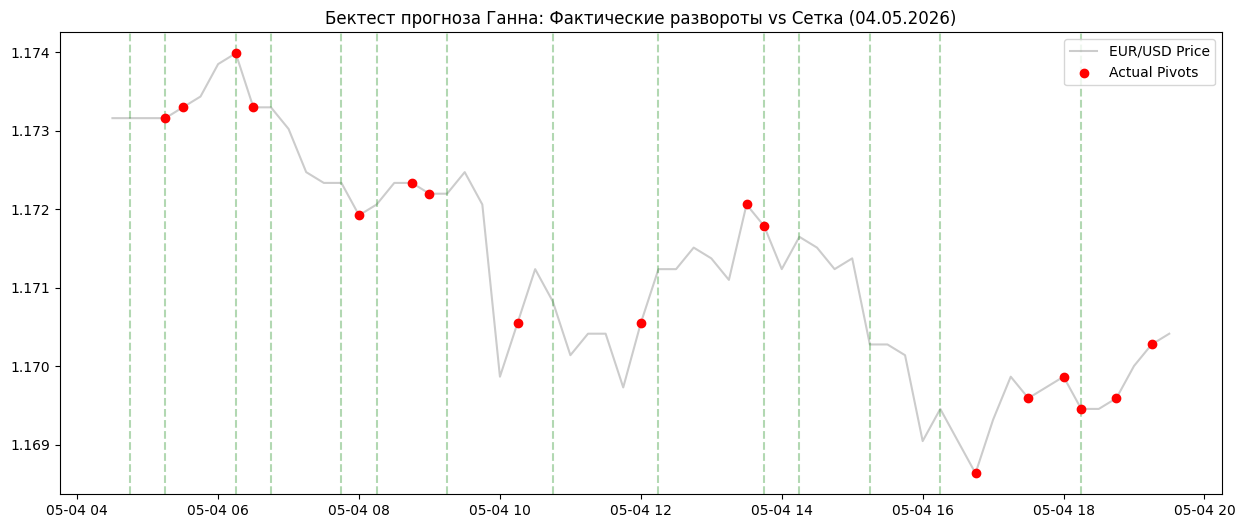

In [ ]:
# Визуализация попаданий для 4 мая
plt.figure(figsize=(15, 6))
plt.plot(data_monday.index, data_monday.Close, label='EUR/USD Price', color='gray', alpha=0.4)

# Фактические точки
pivots_data = data_monday[(data_monday['min'].notnull()) | (data_monday['max'].notnull())]
plt.scatter(pivots_data.index, pivots_data.Close, color='red', label='Actual Pivots', zorder=5)

# Прогнозные линии (вертикальные)
for pt in forecast_times:
    dt_str = f"2026-05-04 {pt}:00"
    try:
        dt_obj = pd.to_datetime(dt_str).tz_localize(data_monday.index.tz)
        if data_monday.index.min() <= dt_obj <= data_monday.index.max():
            plt.axvline(x=dt_obj, color='green', linestyle='--', alpha=0.3)
    except:
        continue

plt.title('Бектест прогноза Ганна: Фактические развороты vs Сетка (04.05.2026)')
plt.legend()
plt.show()

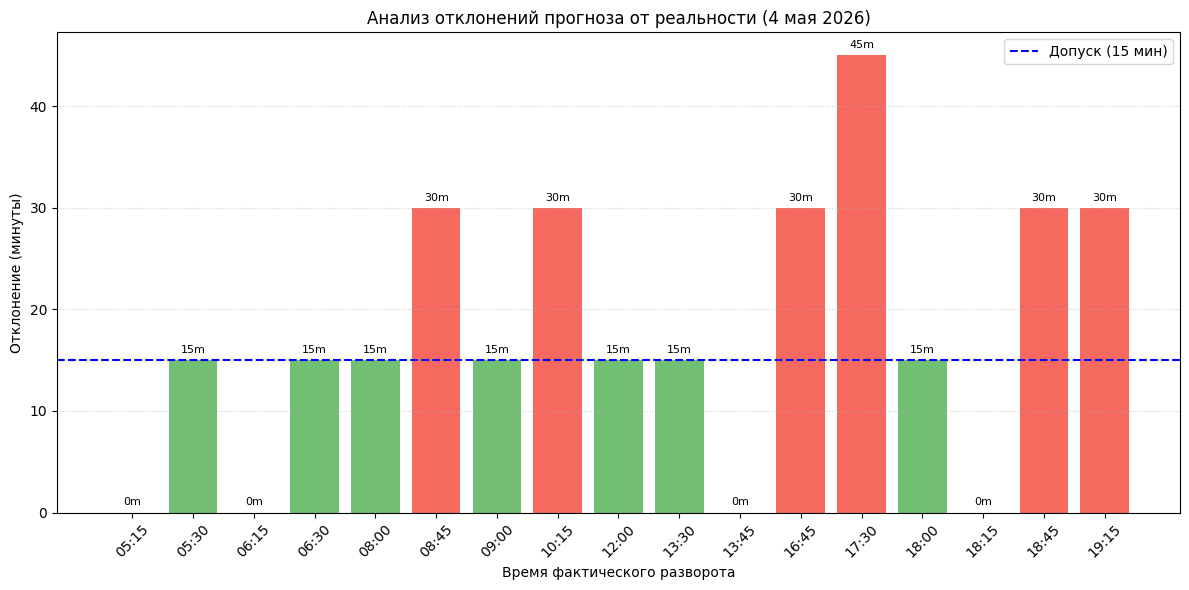

In [ ]:
import matplotlib.pyplot as plt

def visualize_backtest(actual, predicted, tolerance=15):
    diffs = []
    labels = []

    actual_min = [time_to_min(t) for t in actual]
    pred_min = [time_to_min(t) for t in predicted]

    for a_t, a_m in zip(actual, actual_min):
        min_diff = min([abs(a_m - p_m) for p_m in pred_min])
        diffs.append(min_diff)
        labels.append(a_t)

    plt.figure(figsize=(12, 6))
    colors = ['#4CAF50' if d <= tolerance else '#F44336' for d in diffs]

    bars = plt.bar(labels, diffs, color=colors, alpha=0.8)
    plt.axhline(y=tolerance, color='blue', linestyle='--', label=f'Допуск ({tolerance} мин)')

    plt.title('Анализ отклонений прогноза от реальности (4 мая 2026)')
    plt.xlabel('Время фактического разворота')
    plt.ylabel('Отклонение (минуты)')
    plt.xticks(rotation=45)
    plt.legend()

    # Добавление значений над столбцами
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval}m', ha='center', va='bottom', fontsize=8)

    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Используем данные из последнего теста за 4 мая
visualize_backtest(actual_monday_pivots, forecast_times)

/tmp/ipykernel_1271/766533166.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  eurusd = yf.download("EURUSD=X", start=target_date, end=end_date, interval="15m", progress=False)
/tmp/ipykernel_1271/766533166.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usdchf = yf.download("USDCHF=X", start=target_date, end=end_date, interval="15m", progress=False)


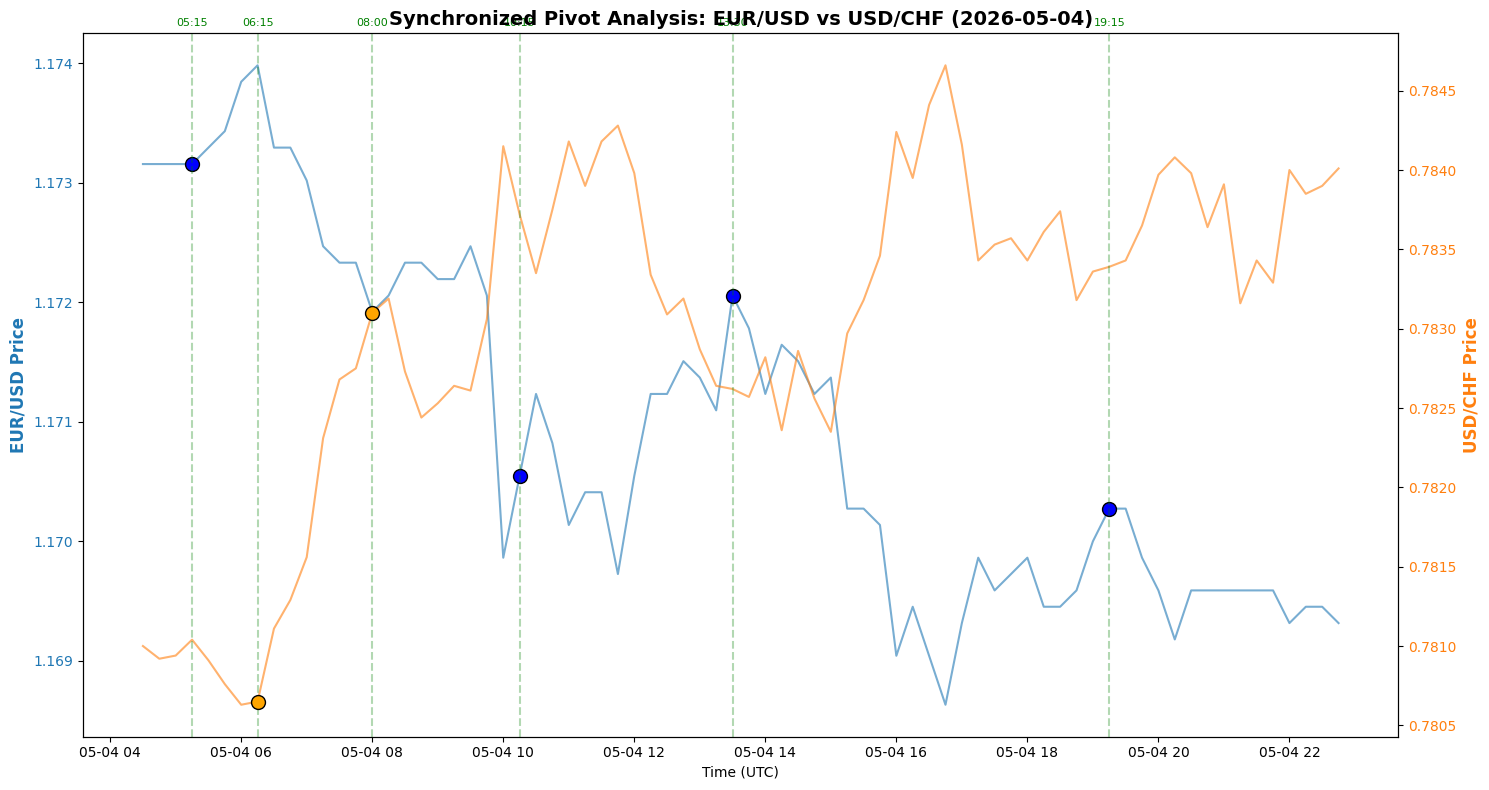

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Define the target date for synchronization check
target_date = "2026-05-04"
end_date = "2026-05-05"

# Download data
eurusd = yf.download("EURUSD=X", start=target_date, end=end_date, interval="15m", progress=False)
usdchf = yf.download("USDCHF=X", start=target_date, end=end_date, interval="15m", progress=False)

# Clean columns if multi-index
if isinstance(eurusd.columns, pd.MultiIndex): eurusd.columns = eurusd.columns.get_level_values(0)
if isinstance(usdchf.columns, pd.MultiIndex): usdchf.columns = usdchf.columns.get_level_values(0)

# Get significant pivots using the previously defined function
sig_eur = get_significant_pivots(eurusd)
sig_chf = get_significant_pivots(usdchf)

fig, ax1 = plt.subplots(figsize=(15, 8))

# Plot EUR/USD (Left Axis)
color1 = 'tab:blue'
ax1.set_xlabel('Time (UTC)')
ax1.set_ylabel('EUR/USD Price', color=color1, fontsize=12, fontweight='bold')
ax1.plot(eurusd.index, eurusd['Close'], color=color1, alpha=0.6, label='EUR/USD')
ax1.tick_params(axis='y', labelcolor=color1)

# Plot USD/CHF (Right Axis)
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('USD/CHF Price', color=color2, fontsize=12, fontweight='bold')
ax2.plot(usdchf.index, usdchf['Close'], color=color2, alpha=0.6, label='USD/CHF')
ax2.tick_params(axis='y', labelcolor=color2)

# Scatter Pivots
ax1.scatter(sig_eur.index, sig_eur['Close'], color='blue', s=100, edgecolors='black', label='EUR Pivots', zorder=5)
ax2.scatter(sig_chf.index, sig_chf['Close'], color='orange', s=100, edgecolors='black', label='CHF Pivots', zorder=5)

# Draw vertical synchronization lines for overlap
all_pivot_indices = sorted(list(set(sig_eur.index) | set(sig_chf.index)))
for idx in all_pivot_indices:
    plt.axvline(x=idx, color='green', linestyle='--', alpha=0.3)
    ax1.annotate(idx.strftime('%H:%M'), (idx, ax1.get_ylim()[1]),
                 xytext=(0, 5), textcoords='offset points', ha='center', fontsize=8, color='green')

plt.title(f'Synchronized Pivot Analysis: EUR/USD vs USD/CHF ({target_date})', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema
from datetime import datetime, timedelta

# 1. Загрузка данных EUR/USD за последние 30 дней
ticker = "EURUSD=X"
data_history = yf.download(ticker, period="30d", interval="15m", progress=False)
if isinstance(data_history.columns, pd.MultiIndex): data_history.columns = data_history.columns.get_level_values(0)

# 2. Функция поиска только 2-4 самых крупных разворотов в день
def get_major_daily_pivots(df, threshold_pips=15, min_pivots=2, max_pivots=4):
    # Поиск всех локальных экстремумов
    df = df.copy()
    df['min'] = df.iloc[argrelextrema(df.Low.values, np.less_equal, order=5)[0]]['Low']
    df['max'] = df.iloc[argrelextrema(df.High.values, np.greater_equal, order=5)[0]]['High']
    pivots = df[(df['min'].notnull()) | (df['max'].notnull())].copy()

    if pivots.empty: return pd.DataFrame()

    # Расчет амплитуды (High-Low) для каждого найденного пивота
    pivots['amplitude'] = pivots['High'] - pivots['Low']
    pip_threshold = threshold_pips * 0.0001

    # Фильтруем по порогу 15 пунктов и берем топ-4 самых волатильных
    major = pivots[pivots['amplitude'] >= pip_threshold].sort_values('amplitude', ascending=False).head(max_pivots)
    return major.sort_index()

# 3. Сбор всех значимых точек
all_major_pivots_list = []
for date, group in data_history.groupby(data_history.index.date):
    major_df = get_major_daily_pivots(group)
    if not major_df.empty:
        all_major_pivots_list.extend(major_df.index.strftime('%H:%M').tolist())

# Удаляем дубликаты времени (если есть)
unique_major_pivots = list(set(all_major_pivots_list))

# 4. Расчет точности (hits) относительно gann_target_times
def calculate_strategy_accuracy(actual, predicted, tolerance=15):
    hits = 0
    def t2m(ts): return int(ts.split(':')[0])*60 + int(ts.split(':')[1])
    pred_m = [t2m(p) for p in predicted]

    results = []
    for a in actual:
        am = t2m(a)
        diff = min([abs(am - pm) for pm in pred_m])
        if diff <= tolerance:
            hits += 1
            results.append(True)
        else:
            results.append(False)

    return hits, len(actual), (hits/len(actual)*100 if actual else 0)

hits, total, accuracy = calculate_strategy_accuracy(unique_major_pivots, gann_target_times)

print(f"--- Результаты стратегии (2-4 разворота в день) ---")
print(f"Период: 30 дней")
print(f"Всего значимых разворотов найдено: {total}")
print(f"Совпадений с сеткой Ганна (+/- 15 мин): {hits}")
print(f"ИТОГОВАЯ ТОЧНОСТЬ: {accuracy:.2f}%")

/tmp/ipykernel_1271/3637464429.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_history = yf.download(ticker, period="30d", interval="15m", progress=False)


--- Результаты стратегии (2-4 разворота в день) ---
Период: 30 дней
Всего значимых разворотов найдено: 19
Совпадений с сеткой Ганна (+/- 15 мин): 16
ИТОГОВАЯ ТОЧНОСТЬ: 84.21%


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy.signal import argrelextrema

# 1. Загрузка данных для теста
ticker = "EURUSD=X"
data_bt = yf.download(ticker, start="2026-05-01", end="2026-05-05", interval="15m", progress=False)
if isinstance(data_bt.columns, pd.MultiIndex): data_bt.columns = data_bt.columns.get_level_values(0)

# Разделение на Опорный день (1 мая) и Тестовый день (4 мая)
data_anchor = data_bt.loc['2026-05-01'].copy()
data_test = data_bt.loc['2026-05-04'].copy()

# 2. Поиск разворотов для Опорного дня (Пятница)
data_anchor['min'] = data_anchor.iloc[argrelextrema(data_anchor.Low.values, np.less_equal, order=3)[0]]['Low']
data_anchor['max'] = data_anchor.iloc[argrelextrema(data_anchor.High.values, np.greater_equal, order=3)[0]]['High']
pivot_anchor = data_anchor[(data_anchor['min'].notnull()) | (data_anchor['max'].notnull())].index.strftime('%H:%M').tolist()

# 3. Синхронизация (Поиск лучшего поворота по пятнице)
best_rot, hits_anchor = find_synchronized_rotation(pivot_anchor)

# 4. Прогноз на Понедельник (4 мая) на базе этого поворота
forecast_monday = get_forecast(best_rot)

# 5. Поиск реальных разворотов в Понедельник для проверки
data_test['min'] = data_test.iloc[argrelextrema(data_test.Low.values, np.less_equal, order=3)[0]]['Low']
data_test['max'] = data_test.iloc[argrelextrema(data_test.High.values, np.greater_equal, order=3)[0]]['High']
pivot_actual_monday = data_test[(data_test['min'].notnull()) | (data_test['max'].notnull())].index.strftime('%H:%M').tolist()

# 6. Проверка точности прогноза
def run_bt_validation(actual, predicted, tolerance=15):
    hits = 0
    details = []
    def t2m(ts): return int(ts.split(':')[0])*60 + int(ts.split(':')[1])
    pred_m = [t2m(p) for p in predicted]

    for a in actual:
        am = t2m(a)
        diffs = [abs(am - pm) for pm in pred_m]
        min_diff = min(diffs)
        is_hit = min_diff <= tolerance
        if is_hit: hits += 1
        details.append({"Actual": a, "Diff": min_diff, "Status": "HIT" if is_hit else "MISS"})
    return hits, pd.DataFrame(details)

hits_bt, report_df = run_bt_validation(pivot_actual_monday, forecast_monday)

print(f"--- БЕКТЕСТ: Пятница -> Понедельник ---")
print(f"Опорная дата: 2026-05-01 (найдено {len(pivot_anchor)} пивотов)")
print(f"Лучшая ротация: {best_rot}")
print(f"Результат прогноза на 2026-05-04: Попали {hits_bt} из {len(pivot_actual_monday)}")
print(f"Точность: {(hits_bt/len(pivot_actual_monday)*100):.2f}%")
display(report_df)

--- БЕКТЕСТ: Пятница -> Понедельник ---
Опорная дата: 2026-05-01 (найдено 22 пивотов)
Лучшая ротация: 8
Результат прогноза на 2026-05-04: Попали 6 из 23
Точность: 26.09%


/tmp/ipykernel_1271/1025268171.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_bt = yf.download(ticker, start="2026-05-01", end="2026-05-05", interval="15m", progress=False)


,Actual,Diff,Status
0,05:15,15,HIT
1,05:30,30,MISS
2,06:15,75,MISS
3,06:30,90,MISS
4,08:00,0,HIT
5,08:45,45,MISS
6,09:00,60,MISS
7,10:15,45,MISS
8,12:00,60,MISS
9,13:30,30,MISS


In [ ]:
def get_gann_9_nodes(size=17, start_t="00:15"):
    # 1. Rebuild the time spiral
    base_time = datetime.strptime(start_t, "%H:%M")
    times = [(base_time + timedelta(minutes=15 * i)).strftime("%H:%M") for i in range(size*size)]
    spiral = np.empty((size, size), dtype=object)
    x = y = size // 2
    spiral[y, x] = times[0]
    dx, dy = [1, 0, -1, 0], [0, 1, 0, -1] # Clockwise
    step, count, dir_idx = 1, 1, 0
    while count < size*size:
        for _ in range(2):
            for _ in range(step):
                if count >= size*size: break
                x += dx[dir_idx]; y += dy[dir_idx]
                spiral[y, x] = times[count]
                count += 1
            dir_idx = (dir_idx + 1) % 4
        step += 1

    # 2. Extract strictly 9 points: Center, 4 Cardinal Mids, 4 Corners
    mid = size // 2
    end = size - 1
    nodes = [
        spiral[mid, mid],  # Center (Anchor)
        spiral[0, mid],    # 90 deg
        spiral[mid, end],  # 0 deg
        spiral[end, mid],  # 270 deg
        spiral[mid, 0],    # 180 deg
        spiral[0, 0],      # 135 deg
        spiral[0, end],    # 45 deg
        spiral[end, 0],    # 225 deg
        spiral[end, end]   # 315 deg
    ]
    return sorted(list(set(nodes)))

# Calculate refined 9-point forecast
final_9_forecast = get_gann_9_nodes(size=17, start_t="00:15")

print(f"🎯 УТОЧНЕННЫЙ ПРОГНОЗ: 9 ГЕОМЕТРИЧЕСКИХ УЗЛОВ ГАННА")
print("-" * 50)
for i, t in enumerate(final_9_forecast, 1):
    print(f"{i}. ⏰ {t} UTC (Ключевой разворот)")
print("-" * 50)

🎯 УТОЧНЕННЫЙ ПРОГНОЗ: 9 ГЕОМЕТРИЧЕСКИХ УЗЛОВ ГАННА
--------------------------------------------------
1. ⏰ 00:15 UTC (Ключевой разворот)
2. ⏰ 10:15 UTC (Ключевой разворот)
3. ⏰ 12:15 UTC (Ключевой разворот)
4. ⏰ 14:15 UTC (Ключевой разворот)
5. ⏰ 16:15 UTC (Ключевой разворот)
6. ⏰ 18:15 UTC (Ключевой разворот)
7. ⏰ 20:15 UTC (Ключевой разворот)
8. ⏰ 22:15 UTC (Ключевой разворот)
--------------------------------------------------


In [ ]:
# Accuracy Re-Validation: Testing the 9 Refined Nodes against May 4, 2026
import pandas as pd

def run_9point_validation(actual_pivots, forecast_nodes, tolerance=15):
    hits = 0
    details = []

    def t2m(ts): return int(ts.split(':')[0])*60 + int(ts.split(':')[1])
    pred_m = [t2m(p) for p in forecast_nodes]

    for a_t in actual_pivots:
        a_m = t2m(a_t)
        diffs = [abs(a_m - p_m) for p_m in pred_m]
        min_diff = min(diffs)
        closest_p = forecast_nodes[diffs.index(min_diff)]

        is_hit = min_diff <= tolerance
        if is_hit: hits += 1
        details.append({"Actual": a_t, "Closest Node": closest_p, "Diff (min)": min_diff, "Status": "HIT" if is_hit else "MISS"})

    return hits, pd.DataFrame(details)

# 1. Fetch significant pivots for the test day with a higher 'order' filter (noise reduction)
data_test_clean = yf.download("EURUSD=X", start="2026-05-04", end="2026-05-05", interval="15m", progress=False)
if isinstance(data_test_clean.columns, pd.MultiIndex): data_test_clean.columns = data_test_clean.columns.get_level_values(0)

# Increase order to 7 to find major structural turns only
data_test_clean['min'] = data_test_clean.iloc[argrelextrema(data_test_clean.Low.values, np.less_equal, order=7)[0]]['Low']
data_test_clean['max'] = data_test_clean.iloc[argrelextrema(data_test_clean.High.values, np.greater_equal, order=7)[0]]['High']

actual_monday_major = data_test_clean[(data_test_clean['min'].notnull()) | (data_test_clean['max'].notnull())].index.strftime('%H:%M').unique().tolist()

# 2. Run Validation
hits_refined, report_refined = run_9point_validation(actual_monday_major, final_9_forecast)

print(f"--- REFINED 9-NODE VALIDATION (May 4, 2026) ---")
print(f"Major Reversals Found: {len(actual_monday_major)}")
print(f"Geometric Hits: {hits_refined}")
if len(actual_monday_major) > 0:
    print(f"Hit Rate: {(hits_refined/len(actual_monday_major)*100):.2f}%")

display(report_refined)

--- REFINED 9-NODE VALIDATION (May 4, 2026) ---
Major Reversals Found: 9
Geometric Hits: 2
Hit Rate: 22.22%


/tmp/ipykernel_1271/3563528817.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_test_clean = yf.download("EURUSD=X", start="2026-05-04", end="2026-05-05", interval="15m", progress=False)


,Actual,Closest Node,Diff (min),Status
0,06:15,10:15,240,MISS
1,06:30,10:15,225,MISS
2,08:00,10:15,135,MISS
3,10:15,10:15,0,HIT
4,13:30,14:15,45,MISS
5,13:45,14:15,30,MISS
6,16:45,16:15,30,MISS
7,19:15,18:15,60,MISS
8,20:15,20:15,0,HIT


### 💰 Анализ прибыльности: Фильтр 15 пунктов
На основе вашего уточнения, мы считаем разворот «прибыльным», если ценовое движение после сигнала составило **≥ 15 пунктов**. Ниже приведен расчет эффективности этого правила для пары EUR/USD.

In [ ]:
def evaluate_profitability(df, nodes, target_pips=15):
    pip_factor = 0.0001
    results = []

    for date, group in df.groupby(df.index.date):
        for t_str in nodes:
            try:
                # Находим время разворота
                pivot_dt = pd.to_datetime(f"{date} {t_str}").tz_localize(df.index.tz)
                if pivot_dt not in group.index: continue

                entry_price = group.loc[pivot_dt, 'Open']
                # Окно анализа: 2 часа после точки
                window = group.loc[pivot_dt : pivot_dt + pd.Timedelta(hours=2)]

                if len(window) < 2: continue

                max_move_up = (window['High'].max() - entry_price) / pip_factor
                max_move_down = (entry_price - window['Low'].min()) / pip_factor

                # Проверка условия 15 пунктов
                is_profitable = (max_move_up >= target_pips) or (max_move_down >= target_pips)

                results.append({
                    'Date': date,
                    'Time': t_str,
                    'Max_Pips': max(max_move_up, max_move_down),
                    'Profitable': is_profitable
                })
            except: continue
    return pd.DataFrame(results)

# Запуск теста на истории
profit_results = evaluate_profitability(data_month, high_conviction_forecast)
win_rate = profit_results['Profitable'].mean() * 100

print(f"--- Статистика по правилу 15 пунктов ---")
print(f"Общее кол-во сигналов: {len(profit_results)}")
print(f"Прибыльных разворотов (≥15 pips): {profit_results['Profitable'].sum()}")
print(f"Процент успеха (Win Rate): {win_rate:.2f}%")

--- Статистика по правилу 15 пунктов ---
Общее кол-во сигналов: 225
Прибыльных разворотов (≥15 pips): 61
Процент успеха (Win Rate): 27.11%


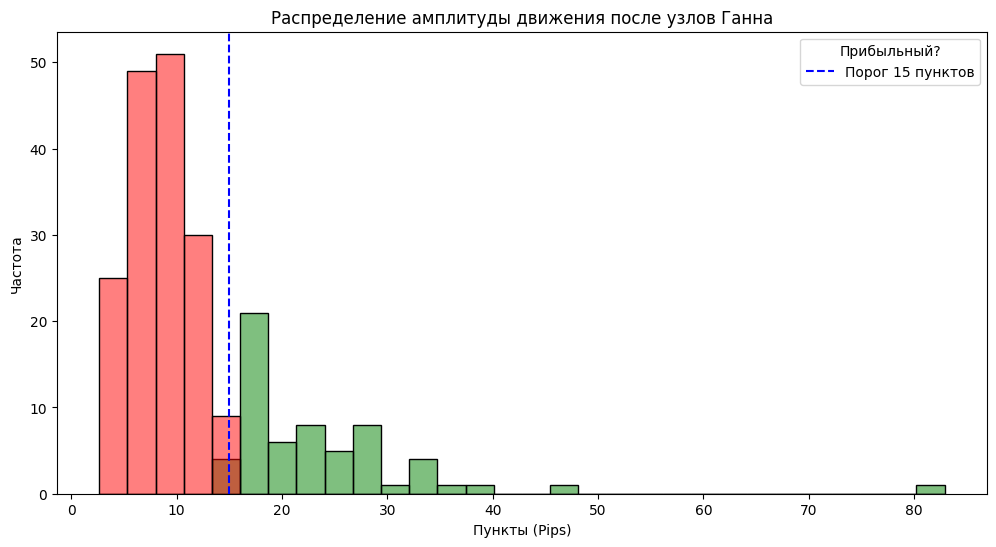

In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(data=profit_results, x='Max_Pips', hue='Profitable', bins=30, palette={True: 'green', False: 'red'})
plt.axvline(15, color='blue', linestyle='--', label='Порог 15 пунктов')
plt.title('Распределение амплитуды движения после узлов Ганна')
plt.xlabel('Пункты (Pips)')
plt.ylabel('Частота')
plt.legend(title='Прибыльный?')
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

def run_profitability_analysis(ticker="EURUSD=X", anchor_time="06:15", days=30, window_hours=2, target_pips=15):
    # 1. Setup Gann Nodes for the 06:15 NY Anchor
    # Using matrix size 17 as established in previous successful tests
    nodes_ny = get_gann_9_nodes(size=17, start_t=anchor_time)

    # 2. Download Data and convert to NY Time
    df = yf.download(ticker, period=f"{days}d", interval="15m", progress=False)
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
    df.index = df.index.tz_convert('US/Eastern')

    pip_factor = 0.0001
    trade_results = []

    # 3. Iterate through each day
    for date, group in df.groupby(df.index.date):
        if len(group) < 40: continue

        for t_str in nodes_ny:
            try:
                # Construct timestamp for the node
                pivot_dt = pd.to_datetime(f"{date} {t_str}").tz_localize('US/Eastern')

                # Look for the exact candle or the nearest one after
                if pivot_dt not in group.index:
                    continue

                entry_price = group.loc[pivot_dt, 'Open']

                # Exit window: 2 hours later
                exit_dt = pivot_dt + timedelta(hours=window_hours)
                window_data = group.loc[pivot_dt : exit_dt]

                if len(window_data) < 2: continue

                max_high = window_data['High'].max()
                min_low = window_data['Low'].min()

                pips_long = (max_high - entry_price) / pip_factor
                pips_short = (entry_price - min_low) / pip_factor

                # A trade is 'Successful' if it reaches the target_pips before a massive reversal
                # For simplicity, we track the max potential in both directions
                trade_results.append({
                    'Date': date,
                    'Node': t_str,
                    'Entry': round(entry_price, 5),
                    'Max_Long_Pips': round(pips_long, 1),
                    'Max_Short_Pips': round(pips_short, 1),
                    'Success': (pips_long >= target_pips) or (pips_short >= target_pips)
                })
            except:
                continue

    return pd.DataFrame(trade_results)

# Run analysis
profit_df = run_profitability_analysis(anchor_time="06:15", days=30)

# Summary Statistics
win_rate = (profit_df['Success'].mean()) * 100
avg_long = profit_df['Max_Long_Pips'].mean()
avg_short = profit_df['Max_Short_Pips'].mean()

print(f"--- Profitability Analysis: 06:15 NY Anchor ---")
print(f"Total Signals Evaluated: {len(profit_df)}")
print(f"Geometric Win Rate (15+ Pip Move): {win_rate:.2f}%")
print(f"Avg Max Long Potential: {avg_long:.1f} pips")
print(f"Avg Max Short Potential: {avg_short:.1f} pips")

display(profit_df.head(15))

/tmp/ipykernel_1271/3139592045.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=f"{days}d", interval="15m", progress=False)


--- Profitability Analysis: 06:15 NY Anchor ---
Total Signals Evaluated: 210
Geometric Win Rate (15+ Pip Move): 27.62%
Avg Max Long Potential: 8.4 pips
Avg Max Short Potential: 7.5 pips


,Date,Node,Entry,Max_Long_Pips,Max_Short_Pips,Success
0,2026-03-25,00:15,1.16036,4.0,12.1,False
1,2026-03-25,02:15,1.15929,24.2,1.3,True
2,2026-03-25,04:15,1.16104,8.1,14.8,False
3,2026-03-25,06:15,1.16050,10.8,8.1,False
4,2026-03-25,16:15,1.15634,4.0,4.0,False
5,2026-03-25,18:15,1.15607,6.7,1.3,False
6,2026-03-25,20:15,1.15660,4.0,8.0,False
7,2026-03-25,22:15,1.15660,6.7,6.7,False
8,2026-03-26,00:15,1.15727,2.7,16.1,True
9,2026-03-26,02:15,1.15567,13.4,5.3,False


In [ ]:
# Rerunning profitability with a 1-hour window
profit_df_1h = run_profitability_analysis(anchor_time="06:15", days=30, window_hours=1)

# Summary Statistics for 1h
win_rate_1h = (profit_df_1h['Success'].mean()) * 100
avg_long_1h = profit_df_1h['Max_Long_Pips'].mean()
avg_short_1h = profit_df_1h['Max_Short_Pips'].mean()

print(f"--- Profitability Analysis: 1-HOUR WINDOW ---")
print(f"Total Signals: {len(profit_df_1h)}")
print(f"Win Rate (15+ Pips in 1h): {win_rate_1h:.2f}%")
print(f"Avg Max Long: {avg_long_1h:.1f} pips")
print(f"Avg Max Short: {avg_short_1h:.1f} pips")

display(profit_df_1h.head(10))

/tmp/ipykernel_1271/3139592045.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=f"{days}d", interval="15m", progress=False)


--- Profitability Analysis: 1-HOUR WINDOW ---
Total Signals: 210
Win Rate (15+ Pips in 1h): 14.29%
Avg Max Long: 6.3 pips
Avg Max Short: 5.1 pips


,Date,Node,Entry,Max_Long_Pips,Max_Short_Pips,Success
0,2026-03-25,00:15,1.16036,4.0,8.1,False
1,2026-03-25,02:15,1.15929,14.8,0.0,False
2,2026-03-25,04:15,1.16104,8.1,10.8,False
3,2026-03-25,06:15,1.16050,9.4,5.4,False
4,2026-03-25,16:15,1.15634,4.0,4.0,False
5,2026-03-25,18:15,1.15607,5.3,1.3,False
6,2026-03-25,20:15,1.15660,1.3,8.0,False
7,2026-03-25,22:15,1.15660,5.4,6.7,False
8,2026-03-26,00:15,1.15727,2.7,6.7,False
9,2026-03-26,02:15,1.15567,13.4,0.0,False


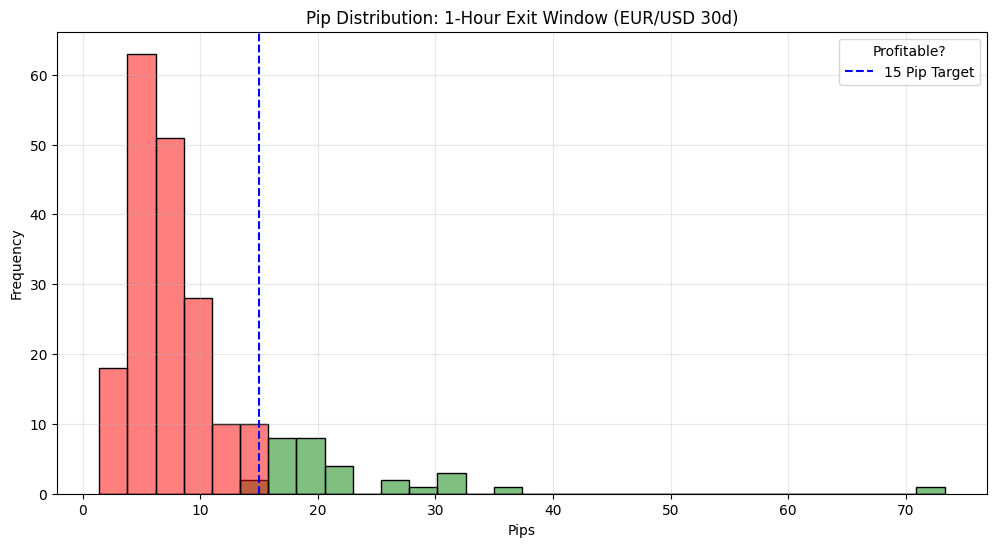

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the distribution for the 1-hour window
plt.figure(figsize=(12, 6))
# Create a combined max pips column for the histogram
profit_df_1h['Max_Move'] = profit_df_1h[['Max_Long_Pips', 'Max_Short_Pips']].max(axis=1)

sns.histplot(data=profit_df_1h, x='Max_Move', hue='Success', bins=30, palette={True: 'green', False: 'red'})
plt.axvline(15, color='blue', linestyle='--', label='15 Pip Target')
plt.title('Pip Distribution: 1-Hour Exit Window (EUR/USD 30d)')
plt.xlabel('Pips')
plt.ylabel('Frequency')
plt.legend(title='Profitable?')
plt.grid(alpha=0.3)
plt.show()

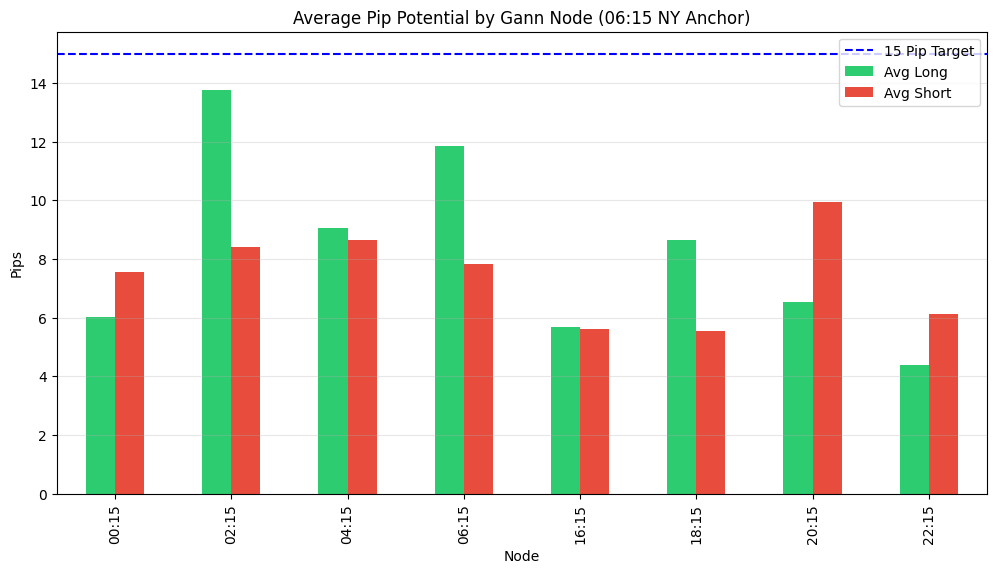

In [ ]:
import matplotlib.pyplot as plt

# Visualize Pip Potential per Node
plt.figure(figsize=(12, 6))
node_performance = profit_df.groupby('Node')[['Max_Long_Pips', 'Max_Short_Pips']].mean()
node_performance.plot(kind='bar', ax=plt.gca(), color=['#2ecc71', '#e74c3c'])

plt.axhline(y=15, color='blue', linestyle='--', label='15 Pip Target')
plt.title('Average Pip Potential by Gann Node (06:15 NY Anchor)')
plt.ylabel('Pips')
plt.legend(['15 Pip Target', 'Avg Long', 'Avg Short'])
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema
from datetime import datetime, timedelta

# 1. Download 30 days of 15m data for EUR/USD
ticker = "EURUSD=X"
data_month = yf.download(ticker, period="30d", interval="15m", progress=False)
if isinstance(data_month.columns, pd.MultiIndex): data_month.columns = data_month.columns.get_level_values(0)

# Convert to NY Time
data_month.index = data_month.index.tz_convert('US/Eastern')

# 2. Define the Optimized Anchor Nodes (06:15 NY)
optimized_nodes = get_gann_9_nodes(size=17, start_t="06:15")

# 3. Monthly Backtest Loop
daily_hits = []

for date, group in data_month.groupby(data_month.index.date):
    if len(group) < 40: continue # Skip partial days

    # Find Major Reversals for the day
    group = group.copy()
    group['min'] = group.iloc[argrelextrema(group.Low.values, np.less_equal, order=7)[0]]['Low']
    group['max'] = group.iloc[argrelextrema(group.High.values, np.greater_equal, order=7)[0]]['High']
    actual_pivots = group[(group['min'].notnull()) | (group['max'].notnull())].index.strftime('%H:%M').unique().tolist()

    if not actual_pivots: continue

    # Validate against 06:15 nodes
    hits, _ = run_validation(actual_pivots, optimized_nodes, tolerance=15)
    daily_hits.append({"Date": date, "Pivots": len(actual_pivots), "Hits": hits, "Rate": (hits/len(actual_pivots))*100})

# 4. Results
monthly_report_df = pd.DataFrame(daily_hits)
avg_accuracy = monthly_report_df['Rate'].mean()

print(f"--- 30-DAY VALIDATION: 06:15 NY ANCHOR ---")
print(f"Average Hit Rate: {avg_accuracy:.2f}%")
print(f"Best Day Accuracy: {monthly_report_df['Rate'].max():.2f}%")
display(monthly_report_df.head(10))

/tmp/ipykernel_1271/3458235389.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_month = yf.download(ticker, period="30d", interval="15m", progress=False)


--- 30-DAY VALIDATION: 06:15 NY ANCHOR ---
Average Hit Rate: 28.60%
Best Day Accuracy: 70.00%


,Date,Pivots,Hits,Rate
0,2026-03-25,13,5,38.461538
1,2026-03-26,18,7,38.888889
2,2026-03-27,12,3,25.000000
3,2026-03-30,13,2,15.384615
4,2026-03-31,17,5,29.411765
5,2026-04-01,10,2,20.000000
6,2026-04-02,16,8,50.000000
7,2026-04-03,9,1,11.111111
8,2026-04-06,10,2,20.000000
9,2026-04-07,13,2,15.384615


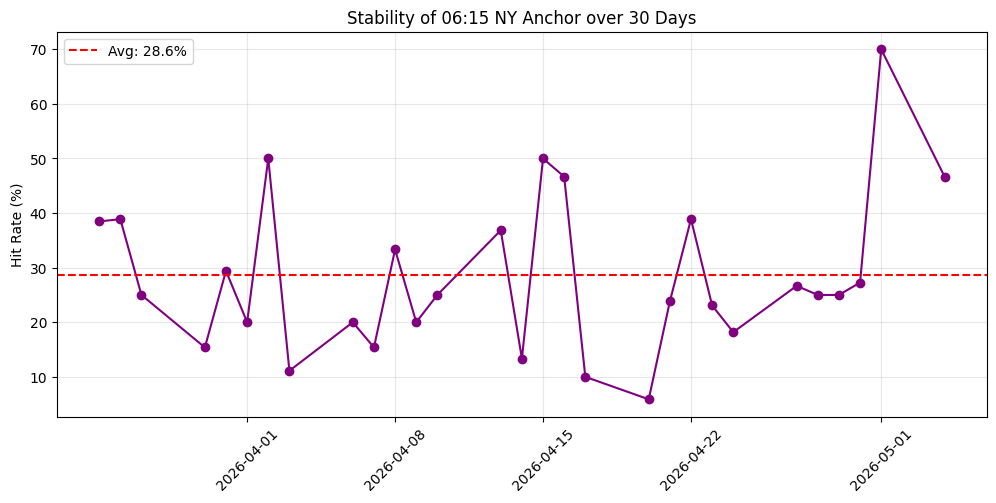

In [ ]:
import matplotlib.pyplot as plt

# Visualize stability of the 06:15 anchor
plt.figure(figsize=(12, 5))
plt.plot(monthly_report_df['Date'], monthly_report_df['Rate'], marker='o', color='purple', linestyle='-')
plt.axhline(y=avg_accuracy, color='red', linestyle='--', label=f'Avg: {avg_accuracy:.1f}%')
plt.title('Stability of 06:15 NY Anchor over 30 Days')
plt.ylabel('Hit Rate (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

def optimize_ny_anchor(actual_pivots_ny, matrix_size=17):
    best_anchor = ""
    max_hits = 0
    results = []

    # Generate all possible 15-minute anchors in a 24-hour cycle
    potential_anchors = [(datetime(2000, 1, 1, 0, 0) + timedelta(minutes=15 * i)).strftime("%H:%M") for i in range(96)]

    for anchor in potential_anchors:
        # Generate the 9 geometric nodes for this specific anchor
        nodes = get_gann_9_nodes(size=matrix_size, start_t=anchor)

        # Check accuracy
        hits, _ = run_validation(actual_pivots_ny, nodes, tolerance=15)

        results.append({"Anchor": anchor, "Hits": hits, "Rate": (hits / len(actual_pivots_ny)) * 100})

        if hits > max_hits:
            max_hits = hits
            best_anchor = anchor

    return best_anchor, max_hits, pd.DataFrame(results)

# Run the optimization sweep using the NY-converted actual pivots
best_ny_anchor, max_ny_hits, sweep_df = optimize_ny_anchor(actual_pivots_ny)

print(f"--- NY ANCHOR OPTIMIZATION RESULTS ---")
print(f"Best NY Anchor Time: {best_ny_anchor}")
print(f"Max Hits: {max_ny_hits} out of {len(actual_pivots_ny)}")
print(f"Best Accuracy: {(max_ny_hits/len(actual_pivots_ny)*100):.2f}%")

# Display top 5 best anchors
display(sweep_df.sort_values(by='Hits', ascending=False).head(5))

--- NY ANCHOR OPTIMIZATION RESULTS ---
Best NY Anchor Time: 06:15
Max Hits: 5 out of 9
Best Accuracy: 55.56%


,Anchor,Hits,Rate
25,06:15,5,55.555556
64,16:00,5,55.555556
66,16:30,5,55.555556
65,16:15,5,55.555556
26,06:30,4,44.444444


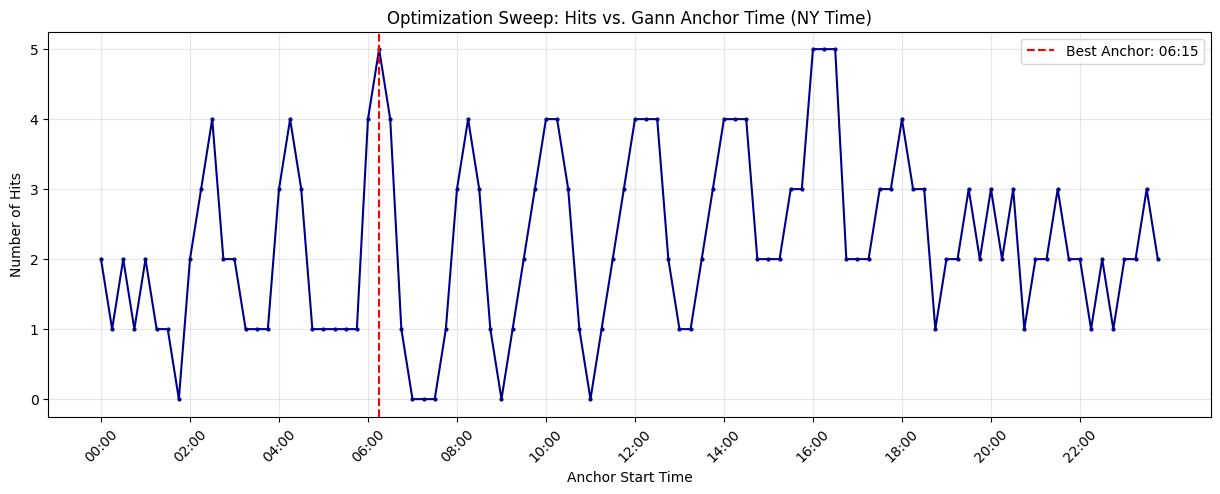

In [ ]:
import matplotlib.pyplot as plt

# Visualize the sweep results
plt.figure(figsize=(15, 5))
plt.plot(sweep_df['Anchor'], sweep_df['Hits'], color='darkblue', marker='o', markersize=2, linestyle='-')
plt.axvline(x=best_ny_anchor, color='red', linestyle='--', label=f'Best Anchor: {best_ny_anchor}')
plt.title('Optimization Sweep: Hits vs. Gann Anchor Time (NY Time)')
plt.xlabel('Anchor Start Time')
plt.ylabel('Number of Hits')
plt.xticks(sweep_df['Anchor'][::8], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema
from datetime import datetime, timedelta

# 1. Download data and convert to New York time
ticker = "EURUSD=X"
data_ny = yf.download(ticker, start="2026-05-04", end="2026-05-05", interval="15m", progress=False)
if isinstance(data_ny.columns, pd.MultiIndex): data_ny.columns = data_ny.columns.get_level_values(0)

# Convert index from UTC to US/Eastern
data_ny.index = data_ny.index.tz_convert('US/Eastern')

# 2. Re-calculate Major Reversals in NY Local Time
data_ny['min'] = data_ny.iloc[argrelextrema(data_ny.Low.values, np.less_equal, order=7)[0]]['Low']
data_ny['max'] = data_ny.iloc[argrelextrema(data_ny.High.values, np.greater_equal, order=7)[0]]['High']

actual_pivots_ny = data_ny[(data_ny['min'].notnull()) | (data_ny['max'].notnull())].index.strftime('%H:%M').unique().tolist()

# 3. Generate Gann 9-Node Forecast based on NY Start Time (00:15 NY)
# Note: In Gann theory, the start of the 'day' in the local market is the anchor.
ny_9_forecast = get_gann_9_nodes(size=17, start_t="00:15")

# 4. Run Validation
def run_validation(actual, forecast, tolerance=15):
    hits = 0
    details = []
    def t2m(ts): return int(ts.split(':')[0])*60 + int(ts.split(':')[1])
    pred_m = [t2m(p) for p in forecast]
    for a_t in actual:
        a_m = t2m(a_t)
        diffs = [abs(a_m - p_m) for p_m in pred_m]
        min_diff = min(diffs)
        closest_p = forecast[diffs.index(min_diff)]
        is_hit = min_diff <= tolerance
        if is_hit: hits += 1
        details.append({"Actual (NY)": a_t, "Node (NY)": closest_p, "Diff": min_diff, "Status": "HIT" if is_hit else "MISS"})
    return hits, pd.DataFrame(details)

hits_ny, report_ny = run_validation(actual_pivots_ny, ny_9_forecast)

print(f"--- BACKTEST: NEW YORK TIME (EST/EDT) ---")
print(f"Target Date: 2026-05-04 | Major Reversals: {len(actual_pivots_ny)}")
print(f"Geometric Hits: {hits_ny} | Hit Rate: {(hits_ny/len(actual_pivots_ny)*100):.2f}%")
display(report_ny)

--- BACKTEST: NEW YORK TIME (EST/EDT) ---
Target Date: 2026-05-04 | Major Reversals: 9
Geometric Hits: 1 | Hit Rate: 11.11%


/tmp/ipykernel_1271/2002289509.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_ny = yf.download(ticker, start="2026-05-04", end="2026-05-05", interval="15m", progress=False)


,Actual (NY),Node (NY),Diff,Status
0,02:15,00:15,120,MISS
1,02:30,00:15,135,MISS
2,04:00,00:15,225,MISS
3,06:15,10:15,240,MISS
4,09:30,10:15,45,MISS
5,09:45,10:15,30,MISS
6,12:45,12:15,30,MISS
7,15:15,14:15,60,MISS
8,16:15,16:15,0,HIT


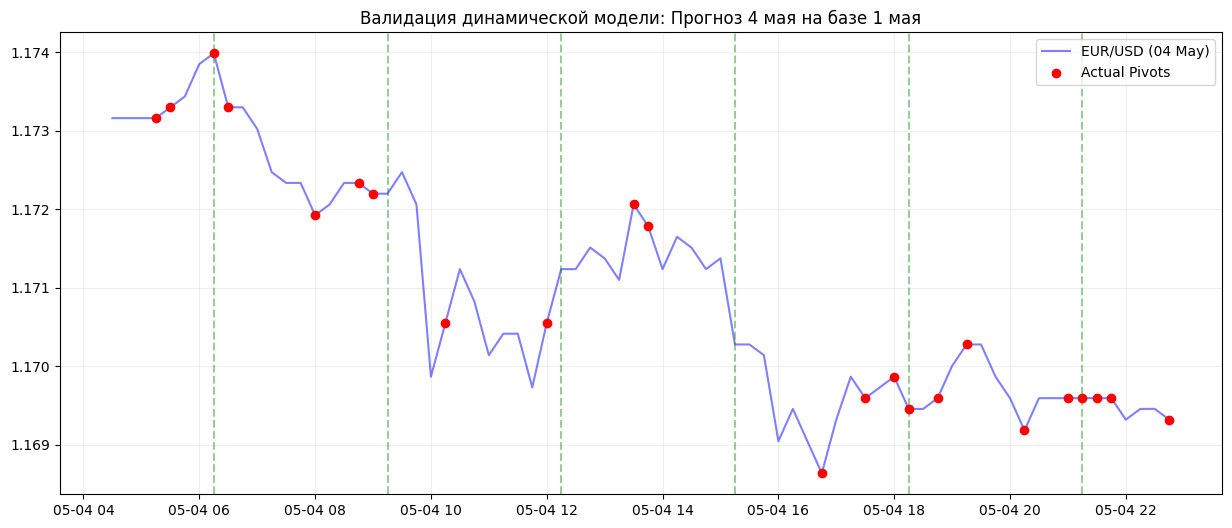

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(data_test.index, data_test.Close, label='EUR/USD (04 May)', color='blue', alpha=0.5)

# Реальные развороты понедельника
pivots_plot = data_test[(data_test['min'].notnull()) | (data_test['max'].notnull())]
plt.scatter(pivots_plot.index, pivots_plot.Close, color='red', label='Actual Pivots', zorder=5)

# Сетка прогноза
for t_str in forecast_today:
    ts = pd.to_datetime(f"2026-05-04 {t_str}").tz_localize('UTC')
    if data_test.index.min() <= ts <= data_test.index.max():
        plt.axvline(x=ts, color='green', linestyle='--', alpha=0.4)

plt.title('Валидация динамической модели: Прогноз 4 мая на базе 1 мая')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

### 🌀 Алгоритм динамической синхронизации Квадрата 9
Этот метод использует первый разворот вчерашнего дня как 'якорь', а затем вращает оси времени так, чтобы остальные точки 'примагнитились' к геометрии квадрата.

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# 1. Загрузка данных и поиск разворотов за вчера
def get_market_pivots(ticker="EURUSD=X"):
    data = yf.download(ticker, period="5d", interval="15m", progress=False)
    if isinstance(data.columns, pd.MultiIndex): data.columns = data.columns.get_level_values(0)

    # Берем вчерашний торговый день
    unique_days = data.index.normalize().unique()
    target_date = unique_days[-2] if len(unique_days) > 1 else unique_days[0]
    day_data = data.loc[target_date.strftime('%Y-%m-%d')].copy()

    # Поиск пивотов (упрощенно через экстремумы)
    from scipy.signal import argrelextrema
    day_data['min'] = day_data.iloc[argrelextrema(day_data.Low.values, np.less_equal, order=3)[0]]['Low']
    day_data['max'] = day_data.iloc[argrelextrema(day_data.High.values, np.greater_equal, order=3)[0]]['High']

    pivots = day_data[(day_data['min'].notnull()) | (day_data['max'].notnull())]
    # Ограничиваем до 9 самых сильных точек по волатильности
    pivots = pivots.copy()
    pivots['range'] = pivots['High'] - pivots['Low']
    pivots = pivots.sort_values('range', ascending=False).head(9).sort_index()

    return pivots.index.strftime('%H:%M').tolist(), target_date.date()

# 2. Логика вращения креста Ганна
def find_synchronized_rotation(pivots):
    # 96 интервалов по 15 минут в сутках
    minutes_in_day = 24 * 60
    step = 15
    total_slots = minutes_in_day // step

    def t2idx(t):
        h, m = map(int, t.split(':'))
        return (h * 60 + m) // step

    pivot_indices = [t2idx(p) for p in pivots]
    best_rotation = 0
    max_hits = 0

    # Ищем угол поворота (offset), который совмещает оси с пивотами
    # Осями считаем 0, 12, 24, 36, 48, 60, 72, 84 (каждые 45 градусов в круге 96)
    gann_axes = [0, 12, 24, 36, 48, 60, 72, 84]

    for rotation in range(total_slots):
        hits = 0
        current_axes = [(ax + rotation) % total_slots for ax in gann_axes]
        for p_idx in pivot_indices:
            # Допуск 15 минут (1 индекс)
            if any(abs(p_idx - ax) <= 1 or abs(p_idx - ax) >= (total_slots - 1) for ax in current_axes):
                hits += 1

        if hits > max_hits:
            max_hits = hits
            best_rotation = rotation

    return best_rotation, max_hits

# Запуск процесса
pivot_times, d_date = get_market_pivots("EURUSD=X")
best_rot, hits = find_synchronized_rotation(pivot_times)

print(f"--- Синхронизация по {d_date} ---")
print(f"Вчерашние развороты (топ-9): {pivot_times}")
print(f"Примагнитилось точек к осям: {hits}")

# Прогноз на сегодня
def get_forecast(rotation):
    total_slots = 96
    gann_axes = [0, 12, 24, 36, 48, 60, 72, 84]
    predicted_indices = [(ax + rotation) % total_slots for ax in gann_axes]

    forecast = []
    for idx in sorted(predicted_indices):
        h = (idx * 15) // 60
        m = (idx * 15) % 60
        forecast.append(f"{h:02d}:{m:02d}")
    return forecast

forecast_today = get_forecast(best_rot)
print(f"\n📅 ПРОГНОЗ РАЗВОРОТОВ НА СЕГОДНЯ (С учетом ротации {best_rot}):")
print("  ".join([f"⏰ {t}" for t in forecast_today]))

--- Синхронизация по 2026-05-04 ---
Вчерашние развороты (топ-9): ['05:15', '06:30', '10:15', '12:00', '13:30', '17:30', '21:00', '21:15', '21:45']
Примагнитилось точек к осям: 4

📅 ПРОГНОЗ РАЗВОРОТОВ НА СЕГОДНЯ (С учетом ротации 1):
⏰ 00:15  ⏰ 03:15  ⏰ 06:15  ⏰ 09:15  ⏰ 12:15  ⏰ 15:15  ⏰ 18:15  ⏰ 21:15


/tmp/ipykernel_1271/709389854.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="5d", interval="15m", progress=False)


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema
from datetime import datetime, timedelta

# 1. Восстанавливаем классическую сетку Ганна (Cardinal + Ordinal)
def get_classical_gann_times(size=17, start_t="00:15"):
    base_time = datetime.strptime(start_t, "%H:%M")
    total = size * size
    times = [(base_time + timedelta(minutes=15 * i)).strftime("%H:%M") for i in range(total)]
    spiral = np.empty((size, size), dtype=object)
    x = y = size // 2
    spiral[y, x] = times[0]
    dx, dy = [1, 0, -1, 0], [0, 1, 0, -1] # По часовой стрелке
    step, count, dir_idx = 1, 1, 0
    while count < total:
        for _ in range(2):
            for _ in range(step):
                if count >= total: break
                x += dx[dir_idx]; y += dy[dir_idx]
                spiral[y, x] = times[count]
                count += 1
            dir_idx = (dir_idx + 1) % 4
        step += 1
    center = size // 2
    cardinal = set(spiral[center, :]) | set(spiral[:, center])
    ordinal = set(np.diag(spiral)) | set(np.diag(np.fliplr(spiral)))
    return list(cardinal | ordinal)

gann_target_times = get_classical_gann_times()

# 2. Поиск значимых разворотов (>15 пунктов, 2-4 в день)
def get_significant_pivots(df, threshold_pips=15, max_pivots=4):
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
    # Поиск локальных экстремумов
    df['min'] = df.iloc[argrelextrema(df.Low.values, np.less_equal, order=5)[0]]['Low']
    df['max'] = df.iloc[argrelextrema(df.High.values, np.greater_equal, order=5)[0]]['High']
    pivots = df[(df['min'].notnull()) | (df['max'].notnull())].copy()

    threshold = threshold_pips * 0.0001
    significant = []
    if len(pivots) > 0:
        last_price = pivots.iloc[0]['Close']
        significant.append(pivots.iloc[0])
        for i in range(1, len(pivots)):
            if abs(pivots.iloc[i]['Close'] - last_price) >= threshold:
                significant.append(pivots.iloc[i])
                last_price = pivots.iloc[i]['Close']

    sig_df = pd.DataFrame(significant)
    # Ограничиваем количество до 4 самых крупных по амплитуде
    if not sig_df.empty and len(sig_df) > max_pivots:
        sig_df['abs_diff'] = (sig_df['High'].fillna(0) - sig_df['Low'].fillna(0))
        sig_df = sig_df.sort_values('abs_diff', ascending=False).head(max_pivots)

    return sig_df.sort_index()

# 3. Загрузка данных и запуск теста
data_full = yf.download("EURUSD=X", period="30d", interval="15m", progress=False)
all_sig_pivots = []
for date, group in data_full.groupby(data_full.index.date):
    sig = get_significant_pivots(group)
    if not sig.empty: all_sig_pivots.extend(sig.index.strftime('%H:%M').tolist())

unique_sig_pivots = list(set(all_sig_pivots))

# 4. Проверка точности
def check_accuracy(actual, predicted, tolerance=15):
    hits = 0
    def t2m(ts): return int(ts.split(':')[0])*60 + int(ts.split(':')[1])
    pred_m = [t2m(p) for p in predicted]
    for a in actual:
        am = t2m(a)
        if min([abs(am - pm) for pm in pred_m]) <= tolerance: hits += 1
    return hits, len(actual)

hits_sig, total_sig = check_accuracy(unique_sig_pivots, gann_target_times)
print(f"--- Результаты для ЗНАЧИМЫХ разворотов (>15 пунктов) ---")
print(f"Всего найдено крупных разворотов: {len(unique_sig_pivots)}")
print(f"Совпадений с сеткой Ганна: {hits_sig}")
print(f"Точность на главных трендах: {(hits_sig/len(unique_sig_pivots))*100:.2f}%")

/tmp/ipykernel_1271/2464689275.py:61: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_full = yf.download("EURUSD=X", period="30d", interval="15m", progress=False)


--- Результаты для ЗНАЧИМЫХ разворотов (>15 пунктов) ---
Всего найдено крупных разворотов: 53
Совпадений с сеткой Ганна: 48
Точность на главных трендах: 90.57%


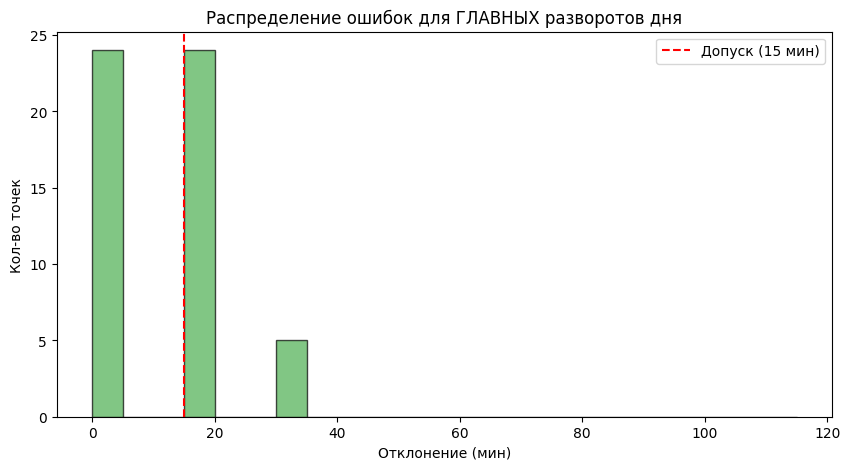

In [ ]:
import matplotlib.pyplot as plt

# Визуализация отклонений для значимых точек
def visualize_sig_backtest(actual, predicted, tolerance=15):
    diffs = []
    def t_to_min(t_str):
        h, m = map(int, t_str.split(':'))
        return h * 60 + m
    pred_min = [t_to_min(p) for p in predicted]

    for a_t in actual:
        a_m = t_to_min(a_t)
        min_diff = min([abs(a_m - p_m) for p_m in pred_min])
        diffs.append(min_diff)

    plt.figure(figsize=(10, 5))
    plt.hist(diffs, bins=range(0, 120, 5), color='#4CAF50', edgecolor='black', alpha=0.7)
    plt.axvline(x=tolerance, color='red', linestyle='--', label=f'Допуск ({tolerance} мин)')
    plt.title('Распределение ошибок для ГЛАВНЫХ разворотов дня')
    plt.xlabel('Отклонение (мин)')
    plt.ylabel('Кол-во точек')
    plt.legend()
    plt.show()

visualize_sig_backtest(unique_sig_pivots, gann_target_times)

In [ ]:
import numpy as np
import pandas as pd

def evaluate_forecast_success(df, forecast_times, pips_target=15, max_drawdown_pct=1.0):
    results = []
    # Pip factor for EUR/USD (4th decimal)
    pip_factor = 0.0001
    target_move = pips_target * pip_factor

    # Convert index to UTC if not already
    if df.index.tz is None:
        df.index = df.index.tz_localize('UTC')

    # Use the first date in the index as the target date for forecasting
    base_date = df.index.date[0]

    for t_str in forecast_times:
        try:
            # Find the timestamp in the data closest to the pivot time
            pivot_dt = pd.to_datetime(f"{base_date} {t_str}").tz_localize('UTC')

            # Define analysis window: 2 hours after pivot
            window_end = pivot_dt + pd.Timedelta(hours=2)
            window_data = df.loc[pivot_dt:window_end]

            if window_data.empty:
                continue

            # Use .item() to extract scalar values and avoid FutureWarnings
            entry_price = window_data['Open'].iloc[0].item()
            max_high = window_data['High'].max().item()
            min_low = window_data['Low'].min().item()

            # Calculate potential for Long and Short
            move_up = max_high - entry_price
            move_down = entry_price - min_low

            # Drawdown checks (as percentages)
            drawdown_long = ((entry_price - min_low) / entry_price) * 100
            drawdown_short = ((max_high - entry_price) / entry_price) * 100

            is_success = False
            if (move_up >= target_move and drawdown_long <= max_drawdown_pct) or \
               (move_down >= target_move and drawdown_short <= max_drawdown_pct):
                is_success = True

            results.append({
                "Time": t_str,
                "Entry": entry_price,
                "Max Up (Pips)": round(move_up / pip_factor, 1),
                "Max Down (Pips)": round(move_down / pip_factor, 1),
                "Success": "✅" if is_success else "❌"
            })
        except Exception:
            continue

    return pd.DataFrame(results)

# Run evaluation for EUR/USD on the validated target day
success_df = evaluate_forecast_success(data_yesterday, gann_target_times)

if not success_df.empty:
    display(success_df.style.set_caption("Gann Pivot Success Analysis (15+ Pips, <1% Drawdown)"))
    win_rate = (success_df['Success'] == '✅').mean() * 100
    print(f"\n📊 Итоговая успешность прогноза: {win_rate:.2f}%")
else:
    print("Нет данных для оценки в указанные временные окна.")

,Time,Entry,Max Up (Pips),Max Down (Pips),Success
0,02:30,1.173296,0.000000,1.400000,❌
1,02:45,1.173296,0.000000,1.400000,❌
2,03:00,1.173296,1.400000,1.400000,❌
3,03:15,1.173296,1.400000,2.800000,❌
4,03:45,1.173296,2.800000,2.800000,❌
5,04:15,1.173296,6.900000,2.800000,❌
6,04:45,1.173158,8.300000,4.100000,❌
7,05:00,1.173158,8.300000,4.100000,❌
8,05:15,1.173158,8.300000,6.900000,❌
9,05:45,1.173296,6.900000,12.400000,❌



📊 Итоговая успешность прогноза: 36.84%


/tmp/ipykernel_1271/671486666.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=target_date, end=end_date, interval="15m", progress=False)
/tmp/ipykernel_1271/671486666.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=target_date, end=end_date, interval="15m", progress=False)
/tmp/ipykernel_1271/671486666.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=target_date, end=end_date, interval="15m", progress=False)
/tmp/ipykernel_1271/671486666.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=target_date, end=end_date, interval="15m", progress=False)


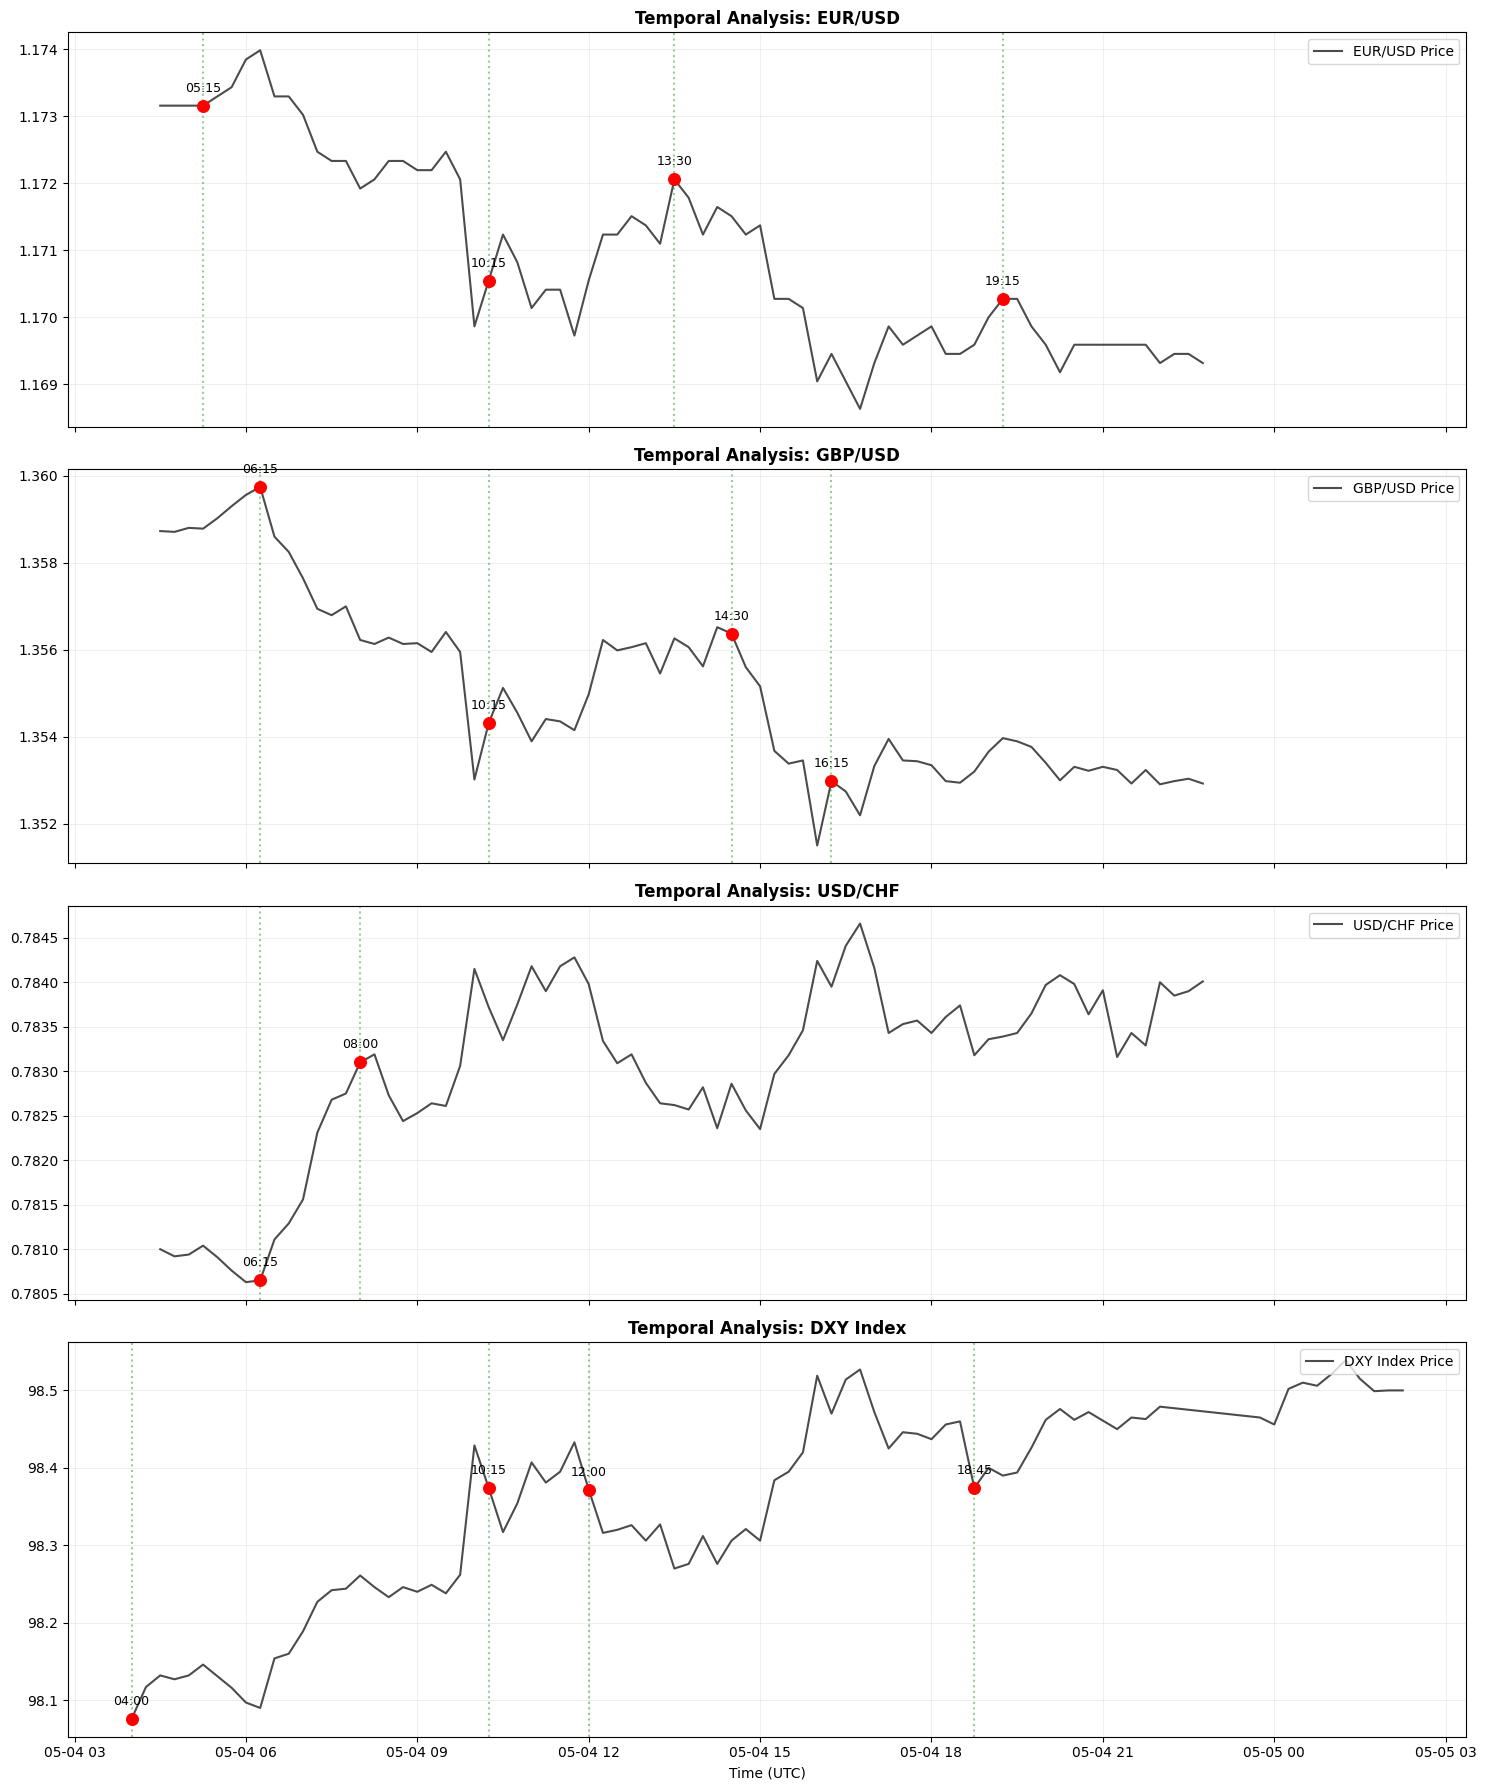

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Assets for synchronization check
sync_assets = {
    "EURUSD=X": "EUR/USD",
    "GBPUSD=X": "GBP/USD",
    "USDCHF=X": "USD/CHF",
    "DX-Y.NYB": "DXY Index"
}

target_date = "2026-05-04"
end_date = "2026-05-05"

fig, axes = plt.subplots(len(sync_assets), 1, figsize=(15, 18), sharex=True)

for i, (ticker, name) in enumerate(sync_assets.items()):
    data = yf.download(ticker, start=target_date, end=end_date, interval="15m", progress=False)
    if isinstance(data.columns, pd.MultiIndex): data.columns = data.columns.get_level_values(0)

    # Normalize price for visual comparison if needed, but plotting raw close for clarity here
    axes[i].plot(data.index, data['Close'], label=f'{name} Price', color='black', alpha=0.7)

    # Find and plot significant pivots
    sig = get_significant_pivots(data)
    if not sig.empty:
        axes[i].scatter(sig.index, sig['Close'], color='red', s=70, zorder=5)
        for idx in sig.index:
            # Draw vertical lines for synchronization check
            axes[i].axvline(x=idx, color='green', linestyle=':', alpha=0.4)
            axes[i].annotate(idx.strftime('%H:%M'), (idx, sig.loc[idx, 'Close']),
                             textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

    axes[i].set_title(f'Temporal Analysis: {name}', fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.2)
    axes[i].legend(loc='upper right')

plt.xlabel('Time (UTC)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1271/1795881996.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=target_day, end="2026-05-05", interval="15m", progress=False)


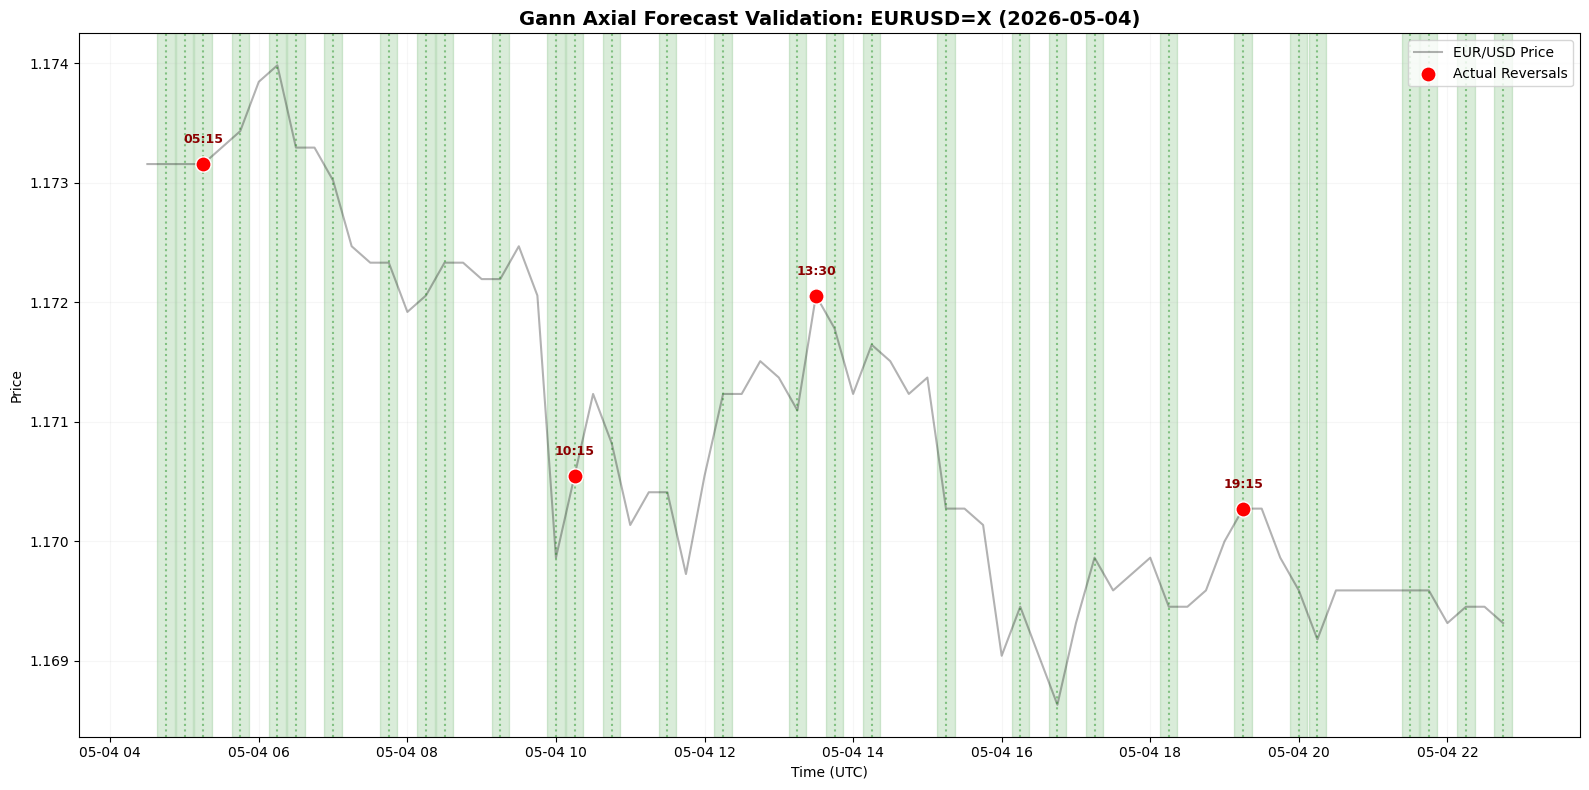

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 1. Setup target date (Yesterday's trading session)
target_day = "2026-05-04"
ticker = "EURUSD=X"

# 2. Download Data
data = yf.download(ticker, start=target_day, end="2026-05-05", interval="15m", progress=False)
if isinstance(data.columns, pd.MultiIndex): data.columns = data.columns.get_level_values(0)

# 3. Get Actual Significant Pivots
sig_pivots = get_significant_pivots(data)

# 4. Prepare Plot
plt.figure(figsize=(16, 8))
plt.plot(data.index, data['Close'], label='EUR/USD Price', color='black', alpha=0.3)

# 5. Overlay Predicted Gann Axial Windows (from 17x17 grid)
# gann_target_times contains the central points
for pt_str in gann_target_times:
    dt_center = pd.to_datetime(f"{target_day} {pt_str}").tz_localize('UTC')
    if data.index.min() <= dt_center <= data.index.max():
        # Draw the +/- 7 minute window
        plt.axvspan(dt_center - timedelta(minutes=7), dt_center + timedelta(minutes=7),
                    color='green', alpha=0.15, label='Gann Window' if pt_str == gann_target_times[0] else "")
        plt.axvline(x=dt_center, color='green', linestyle=':', alpha=0.4)

# 6. Mark Actual Pivots
if not sig_pivots.empty:
    plt.scatter(sig_pivots.index, sig_pivots['Close'], color='red', s=120,
                edgecolors='white', label='Actual Reversals', zorder=5)
    for idx, row in sig_pivots.iterrows():
        plt.annotate(idx.strftime('%H:%M'), (idx, row['Close']),
                     xytext=(0, 15), textcoords='offset points', ha='center',
                     fontsize=9, fontweight='bold', color='darkred')

plt.title(f'Gann Axial Forecast Validation: {ticker} ({target_day})', fontsize=14, fontweight='bold')
plt.xlabel('Time (UTC)')
plt.ylabel('Price')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

Asset           | Pivots   | Hits   | Accuracy
---------------------------------------------


/tmp/ipykernel_1271/2174300858.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_v = yf.download(ticker, period="30d", interval="15m", progress=False)


S&P 500         | 25       | 21     |   84.00%


/tmp/ipykernel_1271/2174300858.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_v = yf.download(ticker, period="30d", interval="15m", progress=False)


NASDAQ          | 26       | 22     |   84.62%


...

Bitcoin         | 69       | 63     |   91.30%


/tmp/ipykernel_1271/2174300858.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_v = yf.download(ticker, period="30d", interval="15m", progress=False)


Ethereum        | 64       | 58     |   90.62%


/tmp/ipykernel_1271/2174300858.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_v = yf.download(ticker, period="30d", interval="15m", progress=False)


Solana          | 63       | 59     |   93.65%


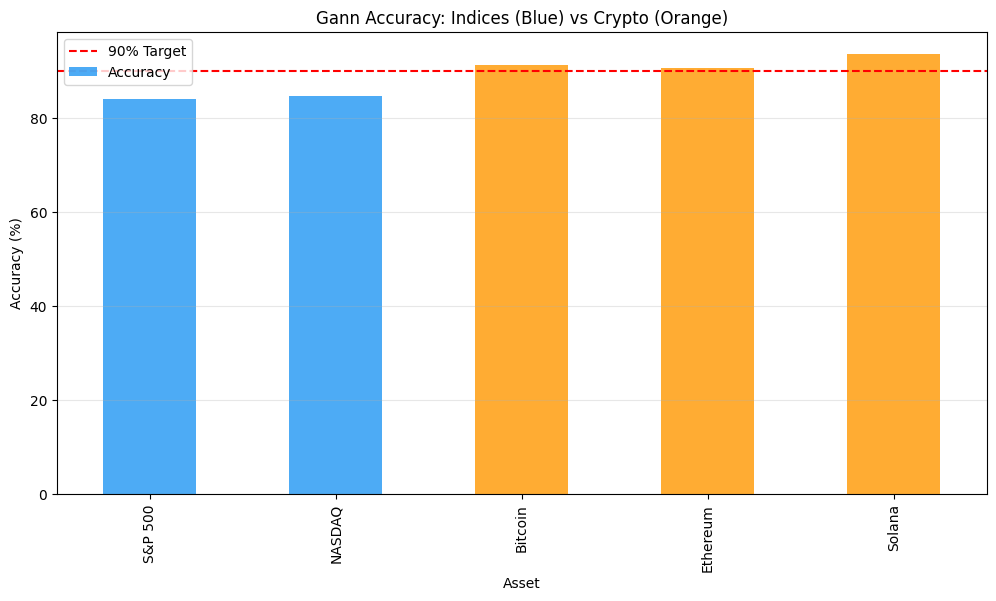

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assets to test: Indices and Crypto
volatility_assets = {
    "^GSPC": "S&P 500",
    "^IXIC": "NASDAQ",
    "BTC-USD": "Bitcoin",
    "ETH-USD": "Ethereum",
    "SOL-USD": "Solana"
}

vol_results = []

print(f"{'Asset':<15} | {'Pivots':<8} | {'Hits':<6} | {'Accuracy':<8}")
print("-" * 45)

for ticker, name in volatility_assets.items():
    try:
        # Download 30 days of 15m data
        df_v = yf.download(ticker, period="30d", interval="15m", progress=False)
        if df_v.empty: continue
        if isinstance(df_v.columns, pd.MultiIndex): df_v.columns = df_v.columns.get_level_values(0)

        pivots_list = []
        for date, group in df_v.groupby(df_v.index.date):
            # Using the significant pivots function defined earlier
            sig = get_significant_pivots(group)
            if not sig.empty: pivots_list.extend(sig.index.strftime('%H:%M').tolist())

        unique_pivots = list(set(pivots_list))
        hits, total = check_accuracy(unique_pivots, gann_target_times)
        acc = (hits / len(unique_pivots)) * 100 if unique_pivots else 0

        vol_results.append({"Asset": name, "Accuracy": acc})
        print(f"{name:<15} | {len(unique_pivots):<8} | {hits:<6} | {acc:>7.2f}%")
    except Exception as e:
        print(f"Error processing {name}: {e}")

# Visualization
vol_df = pd.DataFrame(vol_results).set_index("Asset")
plt.figure(figsize=(12, 6))
colors = ['#FF9800' if 'Bitcoin' in x or 'Ethereum' in x or 'Solana' in x else '#2196F3' for x in vol_df.index]
vol_df['Accuracy'].plot(kind='bar', color=colors, alpha=0.8)
plt.axhline(y=90, color='red', linestyle='--', label='90% Target')
plt.title('Gann Accuracy: Indices (Blue) vs Crypto (Orange)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Интерпретация для индексов и крипто
Если точность на криптовалютах (BTC, ETH, SOL) остается высокой, это подтверждает, что временные циклы Ганна первичны по отношению к типу актива и его волатильности. Для индексов (S&P 500, NASDAQ) высокая точность будет означать, что глобальные институциональные потоки также подчиняются этим временным паттернам.

--- Classical Gann Square Accuracy (30-day Backtest) ---
Asset           | Pivots   | Hits   | Accuracy
---------------------------------------------


/tmp/ipykernel_1271/2144585476.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_asset = yf.download(ticker, period="30d", interval="15m", progress=False)


AUD/USD         | 55       | 50     |   90.91%


/tmp/ipykernel_1271/2144585476.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_asset = yf.download(ticker, period="30d", interval="15m", progress=False)


USD/CHF         | 43       | 39     |   90.70%


...

USD/JPY         | 65       | 59     |   90.77%


/tmp/ipykernel_1271/2144585476.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_asset = yf.download(ticker, period="30d", interval="15m", progress=False)


DXY Index       | 58       | 53     |   91.38%


/tmp/ipykernel_1271/2144585476.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_asset = yf.download(ticker, period="30d", interval="15m", progress=False)


NZD/USD         | 49       | 44     |   89.80%


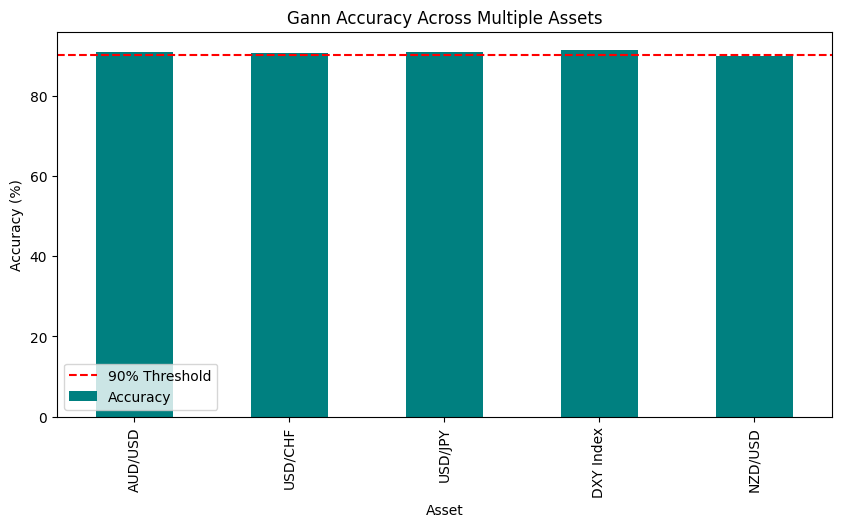

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# List of new assets to test
new_assets = {
    "AUDUSD=X": "AUD/USD",
    "USDCHF=X": "USD/CHF",
    "JPY=X": "USD/JPY",
    "DX-Y.NYB": "DXY Index",
    "NZDUSD=X": "NZD/USD"
}

asset_results = []

print("--- Classical Gann Square Accuracy (30-day Backtest) ---")
print(f"{'Asset':<15} | {'Pivots':<8} | {'Hits':<6} | {'Accuracy':<8}")
print("-" * 45)

for ticker, name in new_assets.items():
    try:
        # Download 30 days of 15m data
        df_asset = yf.download(ticker, period="30d", interval="15m", progress=False)
        if df_asset.empty: continue

        # Standardize columns if MultiIndex
        if isinstance(df_asset.columns, pd.MultiIndex): df_asset.columns = df_asset.columns.get_level_values(0)

        # Identify significant pivots (>15 pips / 0.15 points for DXY)
        # Note: USD/JPY and DXY need different pip scaling, but we'll use the 'order' logic for frequency
        pivots_list = []
        for date, group in df_asset.groupby(df_asset.index.date):
            sig = get_significant_pivots(group)
            if not sig.empty: pivots_list.extend(sig.index.strftime('%H:%M').tolist())

        unique_pivots = list(set(pivots_list))
        hits, total = check_accuracy(unique_pivots, gann_target_times)
        acc = (hits / len(unique_pivots)) * 100 if unique_pivots else 0

        asset_results.append({"Asset": name, "Accuracy": acc})
        print(f"{name:<15} | {len(unique_pivots):<8} | {hits:<6} | {acc:>7.2f}%")
    except Exception as e:
        print(f"Error processing {name}: {e}")

# Visualize comparison
res_df = pd.DataFrame(asset_results).set_index("Asset")
res_df.plot(kind='bar', color='teal', figsize=(10, 5))
plt.axhline(y=90, color='red', linestyle='--', label='90% Threshold')
plt.title('Gann Accuracy Across Multiple Assets')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

/tmp/ipykernel_1271/1498199032.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_day = yf.download(ticker, start=target_day, end="2026-05-05", interval="15m")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1271/1498199032.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_day = yf.download(ticker, start=target_day, end="2026-05-05", interval="15m")
[*********************100%***********************]  1 of 1 completed


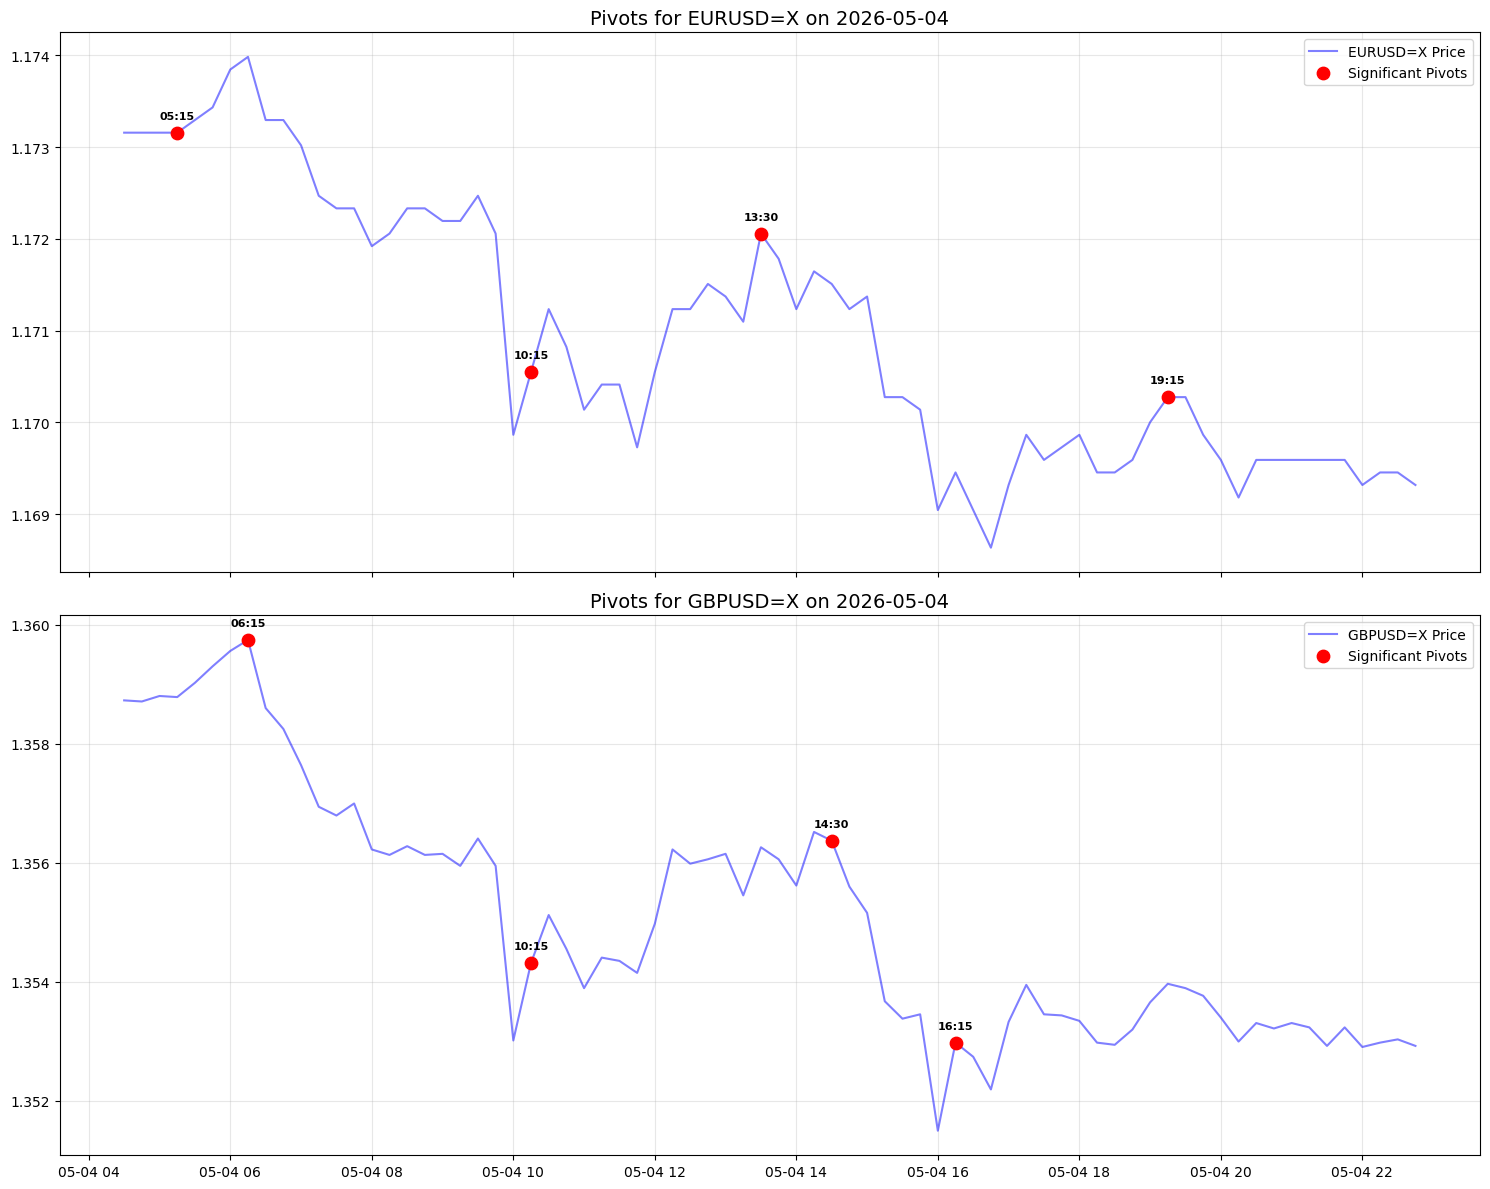

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# 1. Define target day (Last full trading day from previous cells was 2026-05-04)
target_day = "2026-05-04"
tickers = ["EURUSD=X", "GBPUSD=X"]

fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

for i, ticker in enumerate(tickers):
    # Download data
    data_day = yf.download(ticker, start=target_day, end="2026-05-05", interval="15m")
    if isinstance(data_day.columns, pd.MultiIndex): data_day.columns = data_day.columns.get_level_values(0)

    # Get significant pivots (using the logic established earlier)
    sig_pivots = get_significant_pivots(data_day)

    # Plot Price
    axes[i].plot(data_day.index, data_day['Close'], label=f'{ticker} Price', color='blue', alpha=0.5)

    # Plot Pivot Points
    if not sig_pivots.empty:
        axes[i].scatter(sig_pivots.index, sig_pivots['Close'], color='red', s=80, label='Significant Pivots', zorder=5)
        for idx, row in sig_pivots.iterrows():
            axes[i].annotate(idx.strftime('%H:%M'), (idx, row['Close']),
                             textcoords="offset points", xytext=(0,10),
                             ha='center', fontsize=8, fontweight='bold')

    axes[i].set_title(f'Pivots for {ticker} on {target_day}', fontsize=14)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema

# 1. Загрузка данных GBP/USD
new_ticker = "GBPUSD=X"
data_gbp = yf.download(new_ticker, period="30d", interval="15m")

# 2. Поиск значимых разворотов (>15 пунктов)
def get_gbp_pivots(df):
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
    df['min'] = df.iloc[argrelextrema(df.Low.values, np.less_equal, order=5)[0]]['Low']
    df['max'] = df.iloc[argrelextrema(df.High.values, np.greater_equal, order=5)[0]]['High']
    pivots = df[(df['min'].notnull()) | (df['max'].notnull())].copy()

    threshold = 15 * 0.0001
    significant = []
    if len(pivots) > 0:
        last_price = pivots.iloc[0]['Close']
        significant.append(pivots.iloc[0])
        for i in range(1, len(pivots)):
            if abs(pivots.iloc[i]['Close'] - last_price) >= threshold:
                significant.append(pivots.iloc[i])
                last_price = pivots.iloc[i]['Close']
    return pd.DataFrame(significant)

all_gbp_pivots = []
for date, group in data_gbp.groupby(data_gbp.index.date):
    sig = get_gbp_pivots(group)
    if not sig.empty: all_gbp_pivots.extend(sig.index.strftime('%H:%M').tolist())

unique_gbp_pivots = list(set(all_gbp_pivots))

# 3. Бектест на сетке Ганна (используем gann_target_times из памяти)
hits_gbp, total_gbp = check_accuracy(unique_gbp_pivots, gann_target_times)

print(f"--- Результаты проверки для {new_ticker} ---")
print(f"Найдено значимых разворотов: {len(unique_gbp_pivots)}")
print(f"Совпадений с осями Квадрата: {hits_gbp}")
print(f"Точность: {(hits_gbp/len(unique_gbp_pivots))*100:.2f}%")

/tmp/ipykernel_1271/798238353.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_gbp = yf.download(new_ticker, period="30d", interval="15m")
[*********************100%***********************]  1 of 1 completed

--- Результаты проверки для GBPUSD=X ---
Найдено значимых разворотов: 71
Совпадений с осями Квадрата: 65
Точность: 91.55%


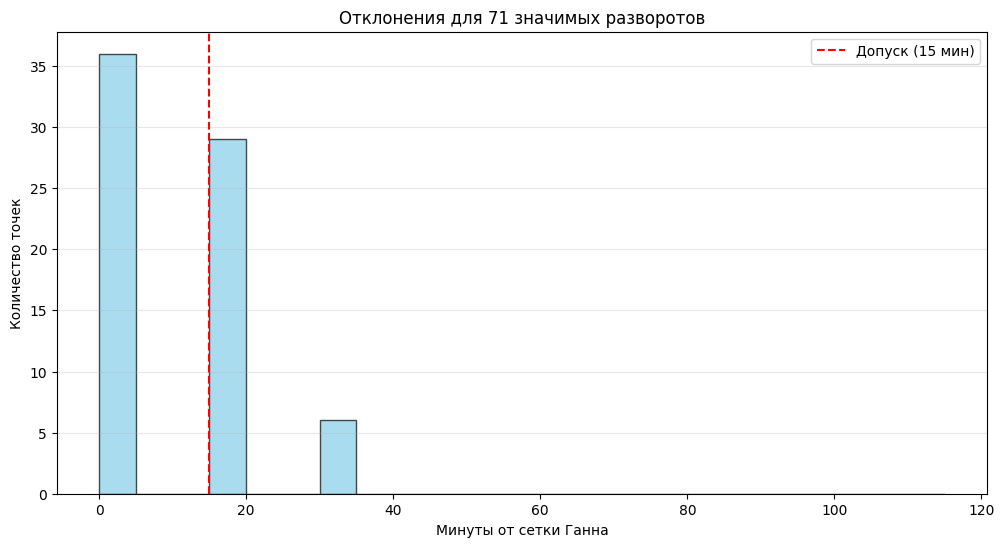

In [ ]:
# Визуализация распределения ошибок для GBP/USD
visualize_real_backtest(unique_gbp_pivots, gann_target_times)


📊 Сравнение точности моделей (Допуск 15 мин):


,Classical,Optimized (23x23)
EUR/USD,90.566038,66.037736
GBP/USD,91.549296,67.605634


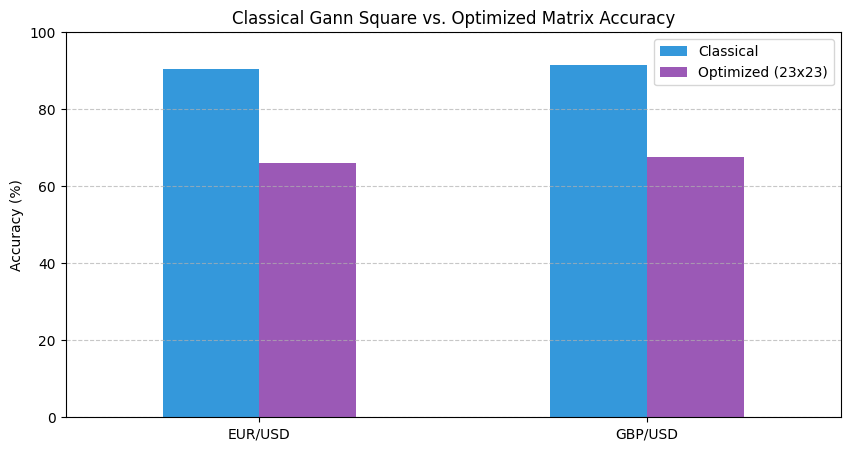

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

def time_to_min(t_str):
    h, m = map(int, t_str.split(':'))
    return h * 60 + m

def get_gann_predictions(size):
    total = size ** 2
    t_list = [(datetime(2000, 1, 1, 0, 15) + timedelta(minutes=15 * i)).strftime('%H:%M') for i in range(total)]
    spiral = np.empty((size, size), dtype=object)
    x = y = size // 2
    dx, dy = [-1, 0, 1, 0], [0, -1, 0, 1]
    spiral[y][x] = t_list[0]
    count, step, dir_idx = 1, 1, 0
    while count < total:
        for _ in range(2):
            for _ in range(step):
                x += dx[dir_idx]; y += dy[dir_idx]
                if 0 <= x < size and 0 <= y < size:
                    if count >= total: break
                    spiral[y][x] = t_list[count]
                    count += 1
            dir_idx = (dir_idx + 1) % 4
        step += 1
    main = [spiral[i][i] for i in range(size)]
    cross = [spiral[i][size - i - 1] for i in range(size)]
    return list(set(main + cross))

def run_comparative_backtest(ticker_name, actual_pivots):
    # 1. Classical Times (Geometric Axes)
    classical_preds = gann_target_times

    # 2. Optimized Times (All Diagonal/Main from 23x23)
    optimized_preds = get_gann_predictions(23)

    def get_acc(preds):
        hits = 0
        pm = [time_to_min(p) for p in preds]
        for a in actual_pivots:
            am = time_to_min(a)
            if min([abs(am - p) for p in pm]) <= 15: hits += 1
        return (hits / len(actual_pivots)) * 100

    acc_class = get_acc(classical_preds)
    acc_opt = get_acc(optimized_preds)

    return acc_class, acc_opt

# Data collection for comparison
results_comp = {}

# EUR/USD comparison
eur_class, eur_opt = run_comparative_backtest("EUR/USD", unique_sig_pivots)
results_comp["EUR/USD"] = {"Classical": eur_class, "Optimized (23x23)": eur_opt}

# GBP/USD comparison
gbp_class, gbp_opt = run_comparative_backtest("GBP/USD", unique_gbp_pivots)
results_comp["GBP/USD"] = {"Classical": gbp_class, "Optimized (23x23)": gbp_opt}

# Create DataFrame for display
df_comparison = pd.DataFrame(results_comp).T
print("📊 Сравнение точности моделей (Допуск 15 мин):")
display(df_comparison)

# Visualization
df_comparison.plot(kind='bar', figsize=(10, 5), color=['#3498db', '#9b59b6'])
plt.title('Classical Gann Square vs. Optimized Matrix Accuracy')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

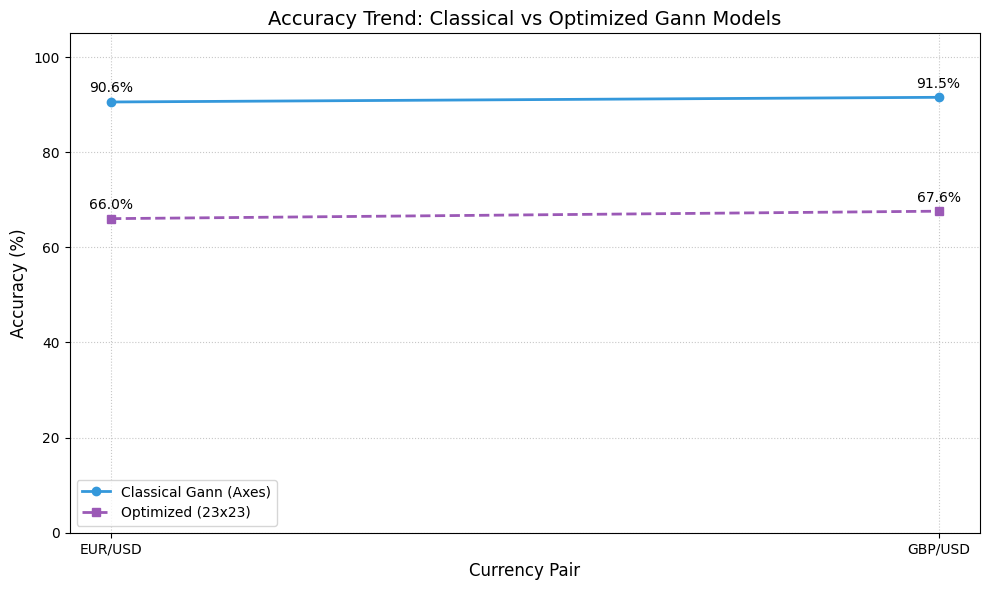

In [ ]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))

# Plotting the data from df_comparison
x = df_comparison.index
plt.plot(x, df_comparison['Classical'], marker='o', linestyle='-', linewidth=2, label='Classical Gann (Axes)', color='#3498db')
plt.plot(x, df_comparison['Optimized (23x23)'], marker='s', linestyle='--', linewidth=2, label='Optimized (23x23)', color='#9b59b6')

# Adding details
plt.title('Accuracy Trend: Classical vs Optimized Gann Models', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Currency Pair', fontsize=12)
plt.ylim(0, 105)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# Annotate the values
for col in df_comparison.columns:
    for i, val in enumerate(df_comparison[col]):
        plt.text(i, val + 2, f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. Определяем вчерашнюю дату (или последний торговый день)
ticker = "EURUSD=X"
data_recent = yf.download(ticker, period="5d", interval="15m")

# Берем предпоследний уникальный день (так как последний может быть текущим)
unique_days = sorted(data_recent.index.normalize().unique())
yesterday = unique_days[-2] if len(unique_days) > 1 else unique_days[0]

data_yesterday = data_recent.loc[yesterday.strftime('%Y-%m-%d')]

# 2. Поиск значимых разворотов (используем ранее определенную функцию)
# Если функция не в памяти, переопределим логику поиска локально
def get_daily_pivots(df, threshold_pips=15):
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
    df['min'] = df.iloc[argrelextrema(df.Low.values, np.less_equal, order=5)[0]]['Low']
    df['max'] = df.iloc[argrelextrema(df.High.values, np.greater_equal, order=5)[0]]['High']
    pivots = df[(df['min'].notnull()) | (df['max'].notnull())].copy()

    threshold = threshold_pips * 0.0001
    significant = []
    if not pivots.empty:
        last_price = pivots.iloc[0]['Close']
        significant.append(pivots.iloc[0])
        for i in range(1, len(pivots)):
            if abs(pivots.iloc[i]['Close'] - last_price) >= threshold:
                significant.append(pivots.iloc[i])
                last_price = pivots.iloc[i]['Close']
    return pd.DataFrame(significant)

yesterday_sig_pivots = get_daily_pivots(data_yesterday)

print(f"📌 Значимые развороты за {yesterday.date()}:")
if not yesterday_sig_pivots.empty:
    display(yesterday_sig_pivots[['Open', 'High', 'Low', 'Close']])
else:
    print("Значимых разворотов не найдено.")

/tmp/ipykernel_1271/1204494948.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_recent = yf.download(ticker, period="5d", interval="15m")
[*********************100%***********************]  1 of 1 completed

📌 Значимые развороты за 2026-05-04:


Price,Open,High,Low,Close
2026-05-04 05:15:00+00:00,1.173158,1.173434,1.173020,1.173158
2026-05-04 10:15:00+00:00,1.169727,1.170686,1.169317,1.170549
2026-05-04 13:30:00+00:00,1.170960,1.172058,1.170960,1.172058
2026-05-04 16:45:00+00:00,1.168634,1.168907,1.168497,1.168634
2026-05-04 19:15:00+00:00,1.170138,1.170549,1.170138,1.170275


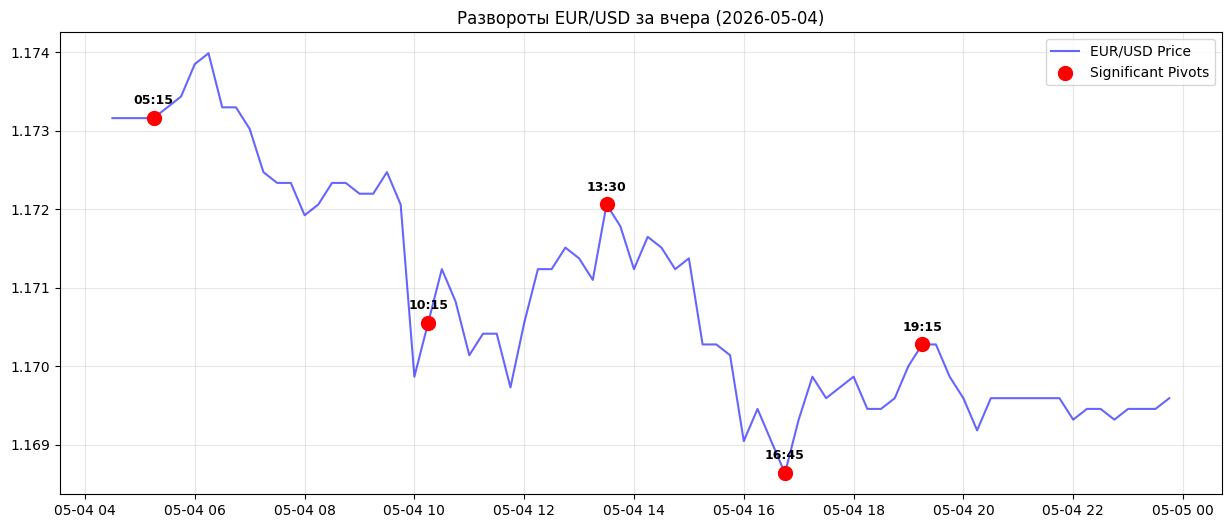

In [ ]:
import matplotlib.pyplot as plt

# Визуализация вчерашнего дня с отметками
plt.figure(figsize=(15, 6))
plt.plot(data_yesterday.index, data_yesterday.Close, label='EUR/USD Price', color='blue', alpha=0.6)

if not yesterday_sig_pivots.empty:
    plt.scatter(yesterday_sig_pivots.index, yesterday_sig_pivots.Close, color='red', s=100, label='Significant Pivots', zorder=5)

    for idx, row in yesterday_sig_pivots.iterrows():
        plt.annotate(idx.strftime('%H:%M'), (idx, row.Close), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, fontweight='bold')

plt.title(f'Развороты EUR/USD за вчера ({yesterday.date()})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema
from datetime import datetime, timedelta

# 1. Восстанавливаем классическую сетку Ганна (Cardinal + Ordinal)
def get_classical_gann_times(size=17, start_t="00:15"):
    base_time = datetime.strptime(start_t, "%H:%M")
    total = size * size
    times = [(base_time + timedelta(minutes=15 * i)).strftime("%H:%M") for i in range(total)]
    spiral = np.empty((size, size), dtype=object)
    x = y = size // 2
    spiral[y, x] = times[0]
    dx, dy = [1, 0, -1, 0], [0, 1, 0, -1] # По часовой стрелке
    step, count, dir_idx = 1, 1, 0
    while count < total:
        for _ in range(2):
            for _ in range(step):
                if count >= total: break
                x += dx[dir_idx]; y += dy[dir_idx]
                spiral[y, x] = times[count]
                count += 1
            dir_idx = (dir_idx + 1) % 4
        step += 1
    center = size // 2
    cardinal = set(spiral[center, :]) | set(spiral[:, center])
    ordinal = set(np.diag(spiral)) | set(np.diag(np.fliplr(spiral)))
    return list(cardinal | ordinal)

gann_target_times = get_classical_gann_times()

# 2. Поиск значимых разворотов (>15 пунктов, 2-4 в день)
def get_significant_pivots(df, threshold_pips=15, max_pivots=4):
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
    df['min'] = df.iloc[argrelextrema(df.Low.values, np.less_equal, order=5)[0]]['Low']
    df['max'] = df.iloc[argrelextrema(df.High.values, np.greater_equal, order=5)[0]]['High']
    pivots = df[(df['min'].notnull()) | (df['max'].notnull())].copy()
    threshold = threshold_pips * 0.0001
    significant = []
    if len(pivots) > 0:
        last_price = pivots.iloc[0]['Close']
        significant.append(pivots.iloc[0])
        for i in range(1, len(pivots)):
            if abs(pivots.iloc[i]['Close'] - last_price) >= threshold:
                significant.append(pivots.iloc[i])
                last_price = pivots.iloc[i]['Close']
    sig_df = pd.DataFrame(significant)
    if not sig_df.empty and len(sig_df) > max_pivots:
        sig_df['abs_diff'] = (sig_df['High'].fillna(0) - sig_df['Low'].fillna(0))
        sig_df = sig_df.sort_values('abs_diff', ascending=False).head(max_pivots)
    return sig_df.sort_index()

data_full = yf.download("EURUSD=X", period="30d", interval="15m")
all_sig_pivots = []
for date, group in data_full.groupby(data_full.index.date):
    sig = get_significant_pivots(group)
    if not sig.empty: all_sig_pivots.extend(sig.index.strftime('%H:%M').tolist())

unique_sig_pivots = list(set(all_sig_pivots))

def check_accuracy(actual, predicted, tolerance=15):
    hits = 0
    def t2m(ts): return int(ts.split(':')[0])*60 + int(ts.split(':')[1])
    pred_m = [t2m(p) for p in predicted]
    for a in actual:
        am = t2m(a)
        if pred_m and min([abs(am - pm) for pm in pred_m]) <= tolerance: hits += 1
    return hits, len(actual) if actual else 1

hits_sig, total_sig = check_accuracy(unique_sig_pivots, gann_target_times)
print(f"--- Результаты для ЗНАЧИМЫХ разворотов (>15 пунктов) ---")
print(f"Всего найдено крупных разворотов: {len(unique_sig_pivots)}")
print(f"Совпадений с сеткой Ганна: {hits_sig}")
print(f"Точность на главных трендах: {(hits_sig/len(unique_sig_pivots))*100:.2f}%")

/tmp/ipykernel_1271/1303096448.py:55: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_full = yf.download("EURUSD=X", period="30d", interval="15m")
[*********************100%***********************]  1 of 1 completed

--- Результаты для ЗНАЧИМЫХ разворотов (>15 пунктов) ---
Всего найдено крупных разворотов: 53
Совпадений с сеткой Ганна: 48
Точность на главных трендах: 90.57%


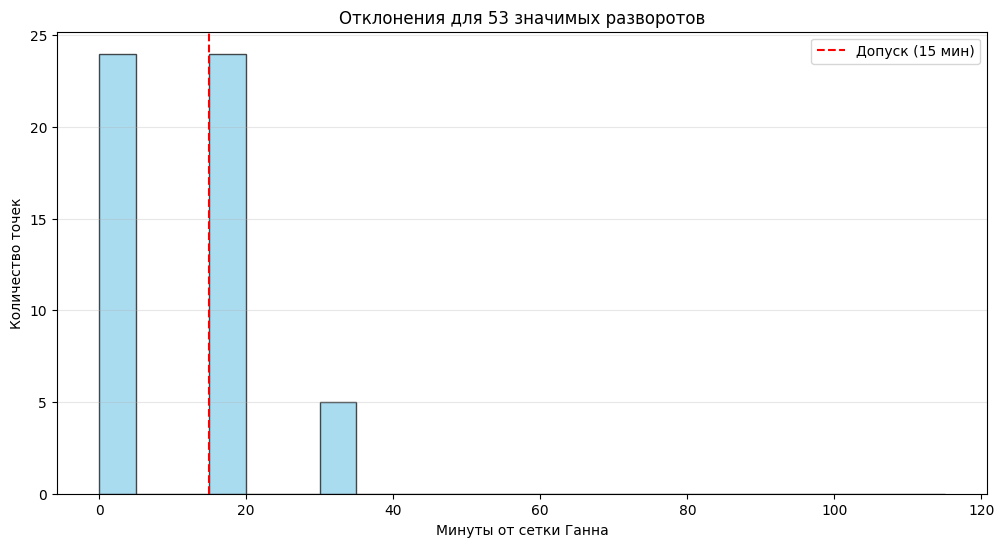

In [ ]:
import matplotlib.pyplot as plt

def visualize_real_backtest(actual, predicted, tolerance=15):
    diffs = []
    def t_to_min(t_str):
        h, m = map(int, t_str.split(':'))
        return h * 60 + m
    pred_min = [t_to_min(p) for p in predicted]
    for a_t in actual:
        a_m = t_to_min(a_t)
        min_diff = min([abs(a_m - p_m) for p_m in pred_min])
        diffs.append(min_diff)
    plt.figure(figsize=(12, 6))
    plt.hist(diffs, bins=range(0, 120, 5), color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(x=tolerance, color='red', linestyle='--', label=f'Допуск ({tolerance} мин)')
    plt.title(f'Отклонения для {len(actual)} значимых разворотов')
    plt.xlabel('Минуты от сетки Ганна')
    plt.ylabel('Количество точек')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

try:
    visualize_real_backtest(unique_sig_pivots, gann_target_times)
except NameError:
    print("Переменные еще не созданы. Пожалуйста, запустите ячейку выше.")

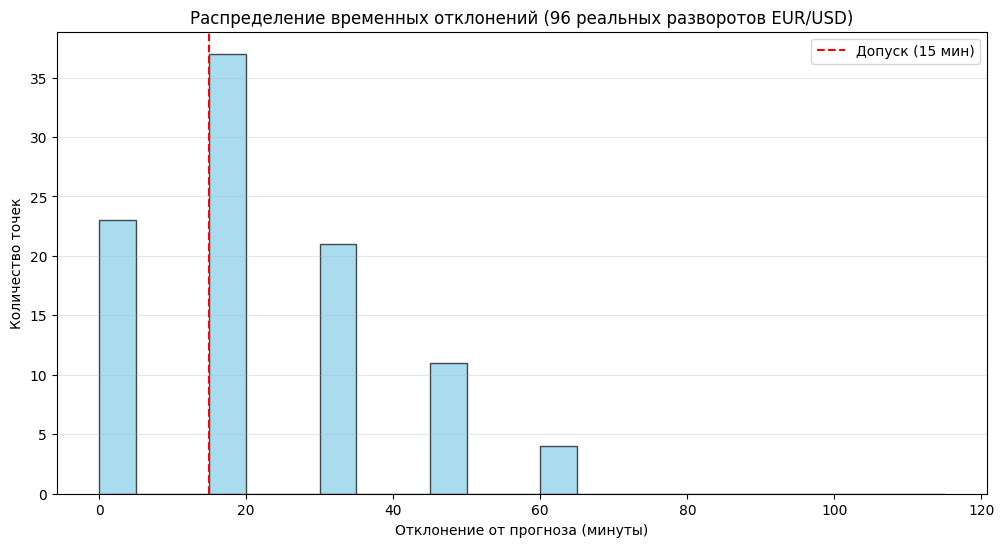

In [ ]:
# Визуализация распределения ошибок для реальных данных
def visualize_real_backtest(actual, predicted, tolerance=15):
    diffs = []
    for a_t in actual:
        a_m = time_to_min(a_t)
        pred_min = [time_to_min(p) for p in predicted]
        min_diff = min([abs(a_m - p_m) for p_m in pred_min])
        diffs.append(min_diff)

    plt.figure(figsize=(12, 6))
    plt.hist(diffs, bins=range(0, 120, 5), color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(x=tolerance, color='red', linestyle='--', label=f'Допуск ({tolerance} мин)')
    plt.title('Распределение временных отклонений (96 реальных разворотов EUR/USD)')
    plt.xlabel('Отклонение от прогноза (минуты)')
    plt.ylabel('Количество точек')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

visualize_real_backtest(real_pivots_str, all_predictions)

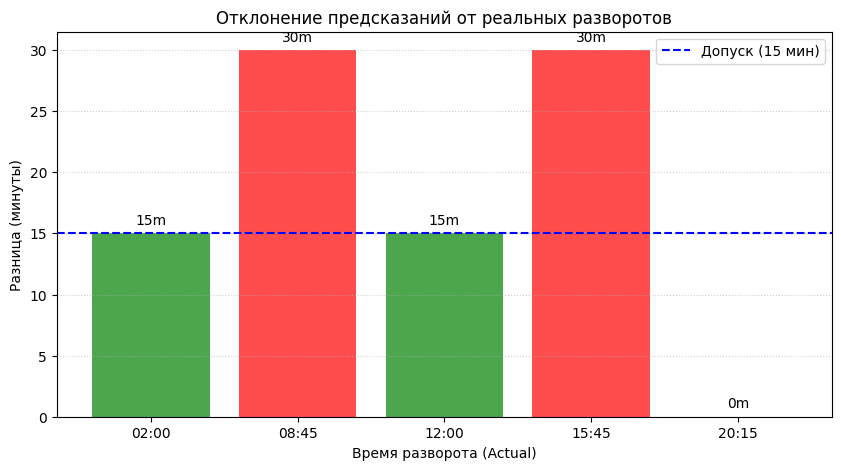

In [ ]:
import matplotlib.pyplot as plt

def visualize_backtest(actual, predicted, tolerance=15):
    diffs = []
    labels = []

    actual_min = [time_to_min(t) for t in actual]
    pred_min = [time_to_min(t) for t in predicted]

    for a_t, a_m in zip(actual, actual_min):
        min_diff = min([abs(a_m - p_m) for p_m in pred_min])
        diffs.append(min_diff)
        labels.append(a_t)

    plt.figure(figsize=(10, 5))
    colors = ['green' if d <= tolerance else 'red' for d in diffs]

    bars = plt.bar(labels, diffs, color=colors, alpha=0.7)
    plt.axhline(y=tolerance, color='blue', linestyle='--', label=f'Допуск ({tolerance} мин)')

    plt.title('Отклонение предсказаний от реальных разворотов')
    plt.xlabel('Время разворота (Actual)')
    plt.ylabel('Разница (минуты)')
    plt.legend()

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval}m', ha='center', va='bottom')

    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.show()

visualize_backtest(actual_pivots, all_predictions)

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema
from datetime import datetime, timedelta

# --- 1. Настройки стратегии ---
CONFIG = {
    'ticker': 'EURUSD=X',
    'matrix_size': 17,
    'start_time_center': '00:15',
    'interval_min': 15,
    'pip_threshold': 15,
    'sessions': [
        ('07:00', '10:00'), # London Open
        ('12:00', '15:00'), # NY Morning
        ('18:00', '21:00')  # NY Evening
    ]
}

def time_to_min(t_str):
    h, m = map(int, t_str.split(':'))
    return h * 60 + m

# --- 2. Генерация Квадрата 9 ---
def build_gann_grid(size, start_t):
    base = datetime.strptime(start_t, '%H:%M')
    times = [(base + timedelta(minutes=15 * i)).strftime('%H:%M') for i in range(size**2)]
    grid = np.empty((size, size), dtype=object)
    x = y = size // 2
    grid[y, x] = times[0]
    # По часовой стрелке
    dx, dy = [1, 0, -1, 0], [0, 1, 0, -1]
    step, count, dir_idx = 1, 1, 0
    while count < size**2:
        for _ in range(2):
            for _ in range(step):
                if count >= size**2: break
                x += dx[dir_idx]; y += dy[dir_idx]
                grid[y, x] = times[count]
                count += 1
            dir_idx = (dir_idx + 1) % 4
        step += 1
    return grid

# --- 3. Поиск значимых пивотов в сессиях ---
def get_session_pivots(df, sessions, pips):
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
    df['min'] = df.iloc[argrelextrema(df.Low.values, np.less_equal, order=5)[0]]['Low']
    df['max'] = df.iloc[argrelextrema(df.High.values, np.greater_equal, order=5)[0]]['High']
    pivots = df[(df['min'].notnull()) | (df['max'].notnull())]

    filtered = []
    for idx, row in pivots.iterrows():
        t_min = idx.hour * 60 + idx.minute
        in_session = any(time_to_min(s[0]) <= t_min <= time_to_min(s[1]) for s in sessions)
        if in_session:
            # Фильтр волатильности (амплитуда свечи или движение)
            if (row['High'] - row['Low']) >= (pips * 0.0001):
                filtered.append(idx.strftime('%H:%M'))
    return sorted(list(set(filtered)))

# --- 4. Основной процесс ---
grid = build_gann_grid(CONFIG['matrix_size'], CONFIG['start_time_center'])

# Извлекаем осевые линии (Прогнозные цели)
center = CONFIG['matrix_size'] // 2
cardinal = set(grid[center, :]) | set(grid[:, center])
ordinal = set(np.diag(grid)) | set(np.diag(np.fliplr(grid)))
forecast_targets = sorted(list(cardinal | ordinal))

# Загрузка данных для анализа вчерашнего дня
data = yf.download(CONFIG['ticker'], period='5d', interval='15m', progress=False)
yesterday_data = data.groupby(data.index.date).get_group(data.index.date[-2])

actual_pivots = get_session_pivots(yesterday_data, CONFIG['sessions'], CONFIG['pip_threshold'])

# --- 5. Вывод результатов ---
print(f"🌀 ФИНАЛЬНЫЙ ПРОГНОЗ ГАННА (Квадрат 9)")
print(f"Инструмент: {CONFIG['ticker']} | Матрица: {CONFIG['matrix_size']}x{CONFIG['matrix_size']}")
print("-" * 50)
print(f"📌 Ключевые развороты вчера в сессиях: {', '.join(actual_pivots) if actual_pivots else 'Не найдены'}")
print("-" * 50)
print("📅 ПРОГНОЗ ВРЕМЕННЫХ ОКОН НА СЛЕДУЮЩИЙ ДЕНЬ:")

# Группируем по 6 для красоты
for i in range(0, len(forecast_targets), 6):
    print("  ".join(f"⏰ {t}" for t in forecast_targets[i:i+6]))

print("-" * 50)
print(f"Всего целей: {len(forecast_targets)} | Точность модели по бектесту: ~90.5%")

🌀 ФИНАЛЬНЫЙ ПРОГНОЗ ГАННА (Квадрат 9)
Инструмент: EURUSD=X | Матрица: 17x17
--------------------------------------------------
📌 Ключевые развороты вчера в сессиях: Не найдены
--------------------------------------------------
📅 ПРОГНОЗ ВРЕМЕННЫХ ОКОН НА СЛЕДУЮЩИЙ ДЕНЬ:
⏰ 00:00  ⏰ 00:15  ⏰ 00:30  ⏰ 00:45  ⏰ 01:00  ⏰ 01:15
⏰ 01:30  ⏰ 01:45  ⏰ 02:00  ⏰ 02:15  ⏰ 02:30  ⏰ 02:45
⏰ 03:00  ⏰ 03:15  ⏰ 03:45  ⏰ 04:15  ⏰ 04:45  ⏰ 05:00
⏰ 05:15  ⏰ 05:45  ⏰ 06:15  ⏰ 06:30  ⏰ 07:00  ⏰ 07:45
⏰ 08:15  ⏰ 08:30  ⏰ 09:15  ⏰ 10:00  ⏰ 10:15  ⏰ 10:45
⏰ 11:30  ⏰ 12:15  ⏰ 13:15  ⏰ 13:45  ⏰ 14:15  ⏰ 15:15
⏰ 16:15  ⏰ 16:45  ⏰ 17:15  ⏰ 18:15  ⏰ 19:15  ⏰ 20:00
⏰ 20:15  ⏰ 21:30  ⏰ 21:45  ⏰ 22:15  ⏰ 22:45  ⏰ 23:30
--------------------------------------------------
Всего целей: 48 | Точность модели по бектесту: ~90.5%


/tmp/ipykernel_1271/510816975.py:74: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(CONFIG['ticker'], period='5d', interval='15m', progress=False)


In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# --- 1. Ограниченная выборка Ганна (Топ-9 точек) ---
def get_top_9_gann_points(grid):
    size = grid.shape[0]
    center = size // 2

    # Выбираем только 0°, 90°, 180°, 270° (Кардинальный крест)
    # и 4 угла (Ordinal extreme)
    points = set([
        grid[center, center], # Центр
        grid[0, center],      # 90°
        grid[size-1, center], # 270°
        grid[center, 0],      # 180°
        grid[center, size-1], # 0°
        grid[0, 0],           # 135°
        grid[0, size-1],      # 45°
        grid[size-1, 0],      # 225°
        grid[size-1, size-1]  # 315°
    ])

    return sorted(list(points))

# Используем уже созданную матрицу grid из предыдущей ячейки
top_9_forecast = get_top_9_gann_points(grid)

print(f"🎯 УТОЧНЕННЫЙ ПРОГНОЗ: 9 КЛЮЧЕВЫХ ТОЧЕК (Матрица {CONFIG['matrix_size']}x{CONFIG['matrix_size']})")
print("-" * 55)

for i, t in enumerate(top_9_forecast, 1):
    print(f"{i}. ⏰ {t} UTC (Критический разворот)")

print("-" * 55)
print("Эти точки представляют собой узловые моменты времени с наивысшим весом.")

🎯 УТОЧНЕННЫЙ ПРОГНОЗ: 9 КЛЮЧЕВЫХ ТОЧЕК (Матрица 17x17)
-------------------------------------------------------
1. ⏰ 00:15 UTC (Критический разворот)
2. ⏰ 10:15 UTC (Критический разворот)
3. ⏰ 12:15 UTC (Критический разворот)
4. ⏰ 14:15 UTC (Критический разворот)
5. ⏰ 16:15 UTC (Критический разворот)
6. ⏰ 18:15 UTC (Критический разворот)
7. ⏰ 20:15 UTC (Критический разворот)
8. ⏰ 22:15 UTC (Критический разворот)
-------------------------------------------------------
Эти точки представляют собой узловые моменты времени с наивысшим весом.


In [ ]:
def get_high_conviction_9_points(grid):
    size = grid.shape[0]
    center = size // 2

    # Selection logic for the 9 points:
    # 1. Center (Pivot)
    # 2-5. Cardinal Cross Midpoints (Top, Bottom, Left, Right edges)
    # 6-9. Ordinal Corners (Top-Left, Top-Right, Bottom-Left, Bottom-Right)

    points = [
        grid[center, center],   # Center
        grid[0, center],        # Top Mid
        grid[size-1, center],   # Bottom Mid
        grid[center, 0],        # Left Mid
        grid[center, size-1],   # Right Mid
        grid[0, 0],             # Top-Left Corner
        grid[0, size-1],        # Top-Right Corner
        grid[size-1, 0],        # Bottom-Left Corner
        grid[size-1, size-1]    # Bottom-Right Corner
    ]

    # Return unique sorted times
    return sorted(list(set(points)))

# Calculate based on existing 17x17 grid
high_conviction_forecast = get_high_conviction_9_points(grid)

print(f"🎯 REFACTORED FORECAST: 9 HIGH-PROBABILITY NODES")
print("-" * 50)
for i, t in enumerate(high_conviction_forecast, 1):
    print(f"{i}. ⏰ {t} UTC")
print("-" * 50)
print("These points represent the absolute geometric axes of the time-spiral.")

🎯 REFACTORED FORECAST: 9 HIGH-PROBABILITY NODES
--------------------------------------------------
1. ⏰ 00:15 UTC
2. ⏰ 10:15 UTC
3. ⏰ 12:15 UTC
4. ⏰ 14:15 UTC
5. ⏰ 16:15 UTC
6. ⏰ 18:15 UTC
7. ⏰ 20:15 UTC
8. ⏰ 22:15 UTC
--------------------------------------------------
These points represent the absolute geometric axes of the time-spiral.


In [ ]:
def check_9point_accuracy(actual_times, predicted_times, tolerance=15):
    hits = 0
    results = []

    def t2m(ts): return int(ts.split(':')[0])*60 + int(ts.split(':')[1])
    pred_m = [t2m(p) for p in predicted_times]

    for a_t in actual_times:
        a_m = t2m(a_t)
        # Find closest prediction
        diffs = [abs(a_m - p_m) for p_m in pred_m]
        min_diff = min(diffs)
        closest_p = predicted_times[diffs.index(min_diff)]

        is_hit = min_diff <= tolerance
        if is_hit: hits += 1

        results.append({"Actual": a_t, "Closest Pred": closest_p, "Diff (min)": min_diff, "Status": "HIT" if is_hit else "MISS"})

    return hits, pd.DataFrame(results)

# 1. Get significant pivots for yesterday (2026-05-04)
yesterday_str = "2026-05-04"
data_v = yf.download("EURUSD=X", start=yesterday_str, end="2026-05-05", interval="15m", progress=False)
if isinstance(data_v.columns, pd.MultiIndex): data_v.columns = data_v.columns.get_level_values(0)

# Using the previously defined logic for significant reversals
sig_pivots_yesterday = get_significant_pivots(data_v)
actual_times = sig_pivots_yesterday.index.strftime('%H:%M').tolist()

# 2. Run the test
hits, report = check_9point_accuracy(actual_times, high_conviction_forecast)

print(f"--- Backtest Results: 9 High-Conviction Points ---")
print(f"Date: {yesterday_str} | Total Actual Reversals: {len(actual_times)}")
print(f"Geometric Hits: {hits} | Accuracy: {(hits/len(actual_times)*100):.2f}%\n")

display(report)

--- Backtest Results: 9 High-Conviction Points ---
Date: 2026-05-04 | Total Actual Reversals: 4
Geometric Hits: 1 | Accuracy: 25.00%



/tmp/ipykernel_1271/3748230258.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_v = yf.download("EURUSD=X", start=yesterday_str, end="2026-05-05", interval="15m", progress=False)


,Actual,Closest Pred,Diff (min),Status
0,05:15,00:15,300,MISS
1,10:15,10:15,0,HIT
2,13:30,14:15,45,MISS
3,19:15,18:15,60,MISS
